# ELPV photovoltaic-cell defect classification — final Colab notebook

This version incorporates the assessment feedback and is self-contained for Google Colab. It downloads a pinned official ELPV revision, regenerates every split/model/result, adds a traditional baseline, and strengthens the architecture, tool justification, workflow, governance, risk, documentation, and Draw.io–Jira consistency evidence.

The task uses only definite annotations: `0 = Functional`, `1 = Defective` (positive class). Intermediate probabilities are excluded from the binary experiment. The result is an educational proof of concept, not a deployment-ready industrial inspection system.

Select **Runtime → Change runtime type → T4 GPU**, then run all cells in order. Do not submit stale metrics from a previous runtime; report the values regenerated by this notebook.


In [1]:
# COLAB SETUP — downloads the exact ELPV revision used by this notebook
from pathlib import Path
import os
import subprocess

ELPV_REPOSITORY = "https://github.com/zae-bayern/elpv-dataset.git"
ELPV_COMMIT = "93e82ae507c36b3f2c8227eade8b792fcbefcca6"
IN_COLAB = Path("/content").is_dir()
REPO_DIR = Path("/content/elpv-dataset") if IN_COLAB else Path.cwd() / "elpv-dataset"

def run_git(*args):
    subprocess.run(["git", *map(str, args)], check=True)

if not (REPO_DIR / ".git").exists():
    REPO_DIR.mkdir(parents=True, exist_ok=True)
    run_git("init", REPO_DIR)
    run_git("-C", REPO_DIR, "remote", "add", "origin", ELPV_REPOSITORY)
else:
    run_git("-C", REPO_DIR, "remote", "set-url", "origin", ELPV_REPOSITORY)

# A commit hash makes the download immutable even if the repository changes.
run_git("-C", REPO_DIR, "fetch", "--depth", "1", "origin", ELPV_COMMIT)
run_git("-C", REPO_DIR, "checkout", "--detach", "FETCH_HEAD")

ROOT = REPO_DIR
IMG_DIR = ROOT / "src" / "elpv_dataset" / "data" / "images"
LABEL_FILE = ROOT / "src" / "elpv_dataset" / "data" / "labels.csv"
image_count = sum(p.suffix.lower() in {".png", ".jpg", ".jpeg"} for p in IMG_DIR.iterdir())
assert LABEL_FILE.is_file(), f"Missing labels file: {LABEL_FILE}"
assert image_count == 2624, f"Expected 2,624 ELPV images, found {image_count}"

os.chdir(ROOT)  # Later Path.cwd() calls now resolve to the downloaded project.
print(f"ELPV ready: {image_count:,} images")
print(f"Pinned commit: {ELPV_COMMIT}")
print(f"Notebook root: {ROOT}")
print("Run the remaining cells in order. Generated files go to:", ROOT / "outputs")


ELPV ready: 2,624 images
Pinned commit: 93e82ae507c36b3f2c8227eade8b792fcbefcca6
Notebook root: /content/elpv-dataset
Run the remaining cells in order. Generated files go to: /content/elpv-dataset/outputs


# Assessment feedback incorporated

## Intended users and decision value

- **Primary users:** photovoltaic quality-control engineers and EL inspection technicians prioritising cells for expert review.
- **Secondary users:** asset owners, maintenance analysts, researchers, and students studying automated EL-image screening.
- **Supported decision:** preliminary prioritisation of cells that may warrant human inspection—not defect diagnosis, root-cause identification, repair advice, or safety certification.
- **Communication:** show both class probabilities, flag uncertain predictions, state the binary scope, and retain human approval for operational action.

## Distinctive contribution

The study combines a conventional downsampled-pixel logistic baseline, a custom grayscale CNN, ResNet18, EfficientNet-B0, validation-locked thresholds, exact paired model tests, bootstrap intervals, Grad-CAM, calibration, perturbation robustness, mono/poly subgroup analysis, and cross-split image-similarity sensitivity analysis.

## Metric semantics

`Defective = 1` is the positive class. A false negative is a defective cell classified as functional; this is operationally important because it may delay expert inspection. A false positive is a functional cell classified as defective and may create unnecessary review work.


# Architecture, feasibility, and tool alternatives

```text
Pinned Git source → integrity/count audit → immutable raw images + labels
→ definite-label filter → stratified train/validation/test split
→ train-only preprocessing/augmentation → baseline + three CNN experiments
→ validation-only early stopping/thresholds → locked test evaluation
→ error/XAI/calibration/robustness/subgroup/similarity evidence
→ versioned CSV/PNG/checkpoint/environment/manifest package
→ probability-and-warning interface prototype → human review
```

| Concern | Selected approach and justification | Considered alternative |
|---|---|---|
| Storage/ingestion | Pinned Git revision and immutable raw layer are reproducible for 2,624 static images | Object storage and event ingestion are preferable only at production scale |
| Modelling | PyTorch supports custom and pretrained vision models in one controlled pipeline | TensorFlow is viable but would add framework duplication without experimental value |
| Baseline | Logistic regression on 32×32 grayscale pixels establishes a genuinely simple reference | SVM is plausible but probability calibration and scaling increase complexity |
| Transfer learning | ResNet18 and EfficientNet-B0 provide accuracy/efficiency alternatives | Larger ViTs are less feasible for this dataset size and Colab budget |
| Evidence | CSV, figures, checkpoints and manifest are portable and assessable | MLflow/W&B would improve multi-user production tracking but require an external account |
| Interface | Optional Gradio prototype demonstrates the prediction contract | FastAPI plus a monitored web client is the production alternative |

Production feasibility additionally requires module-level identifiers, authenticated upload, input validation, encrypted transport, a model registry, audit logs, drift monitoring, access control, retention rules, expert-labelled feedback, and reviewed promotion/rollback.


In [2]:
# CELL 1: Audit ELPV dataset

from pathlib import Path
from PIL import Image
import pandas as pd

ROOT = Path.cwd()
OUT = ROOT / "outputs"
FIG_DIR, TAB_DIR = OUT/"figures", OUT/"tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

EXTS = {".png", ".jpg", ".jpeg"}

# Locate labels and main image folder automatically
LABEL_FILE = next(ROOT.rglob("labels.csv"))

image_dirs = [d for d in ROOT.rglob("images") if d.is_dir()]
IMG_DIR = max(
    image_dirs,
    key=lambda d: sum(f.suffix.lower() in EXTS for f in d.rglob("*") if f.is_file())
)

# Load labels
labels_df = pd.read_csv(LABEL_FILE)

# Fallback if CSV has no useful header
if not any("prob" in str(c).lower() for c in labels_df.columns):
    labels_df = pd.read_csv(LABEL_FILE, header=None)
    if labels_df.shape[1] >= 3:
        labels_df.columns = ["filename", "defect_probability", "cell_type"] + \
                            list(labels_df.columns[3:])

# Audit images
rows, bad = [], []
images = [f for f in IMG_DIR.rglob("*") if f.suffix.lower() in EXTS]

for f in images:
    try:
        with Image.open(f) as im:
            rows.append([str(f), f.name, *im.size, im.mode])
    except Exception:
        bad.append(str(f))

audit_df = pd.DataFrame(
    rows, columns=["filepath", "filename", "width", "height", "mode"]
)

audit_df.to_csv(TAB_DIR/"dataset_audit.csv", index=False)
labels_df.to_csv(TAB_DIR/"labels_loaded.csv", index=False)

prob_col = next((c for c in labels_df.columns if "prob" in str(c).lower()), None)
type_col = next((c for c in labels_df.columns if "type" in str(c).lower()), None)

print("=== CELL 1 SUMMARY ===")
print(f"Root              : {ROOT}")
print(f"Image directory   : {IMG_DIR}")
print(f"Labels file       : {LABEL_FILE}")
print(f"Images found      : {len(audit_df)}")
print(f"Label rows        : {len(labels_df)}")
print(f"Corrupted images  : {len(bad)}")
print(f"Unique sizes      : {audit_df[['width','height']].drop_duplicates().shape[0]}")
print(f"Image modes       : {audit_df['mode'].value_counts().to_dict()}")
print(f"Label columns     : {list(labels_df.columns)}")

if prob_col:
    print(f"Defect labels     : {labels_df[prob_col].value_counts().sort_index().to_dict()}")
if type_col:
    print(f"Cell types        : {labels_df[type_col].value_counts().to_dict()}")

print(f"Audit saved       : {TAB_DIR/'dataset_audit.csv'}")

=== CELL 1 SUMMARY ===
Root              : /content/elpv-dataset
Image directory   : /content/elpv-dataset/src/elpv_dataset/data/images
Labels file       : /content/elpv-dataset/src/elpv_dataset/data/labels.csv
Images found      : 2624
Label rows        : 2624
Corrupted images  : 0
Unique sizes      : 1
Image modes       : {'L': 2624}
Label columns     : [0]
Audit saved       : /content/elpv-dataset/outputs/tables/dataset_audit.csv


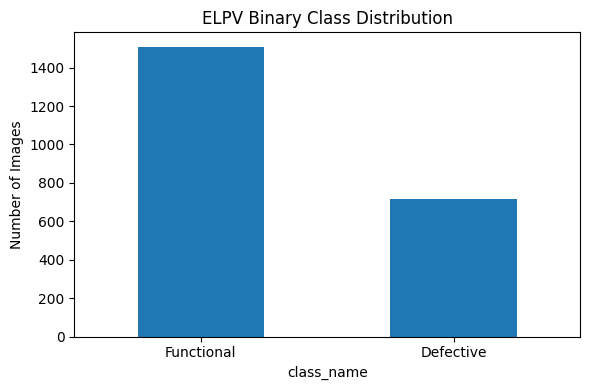

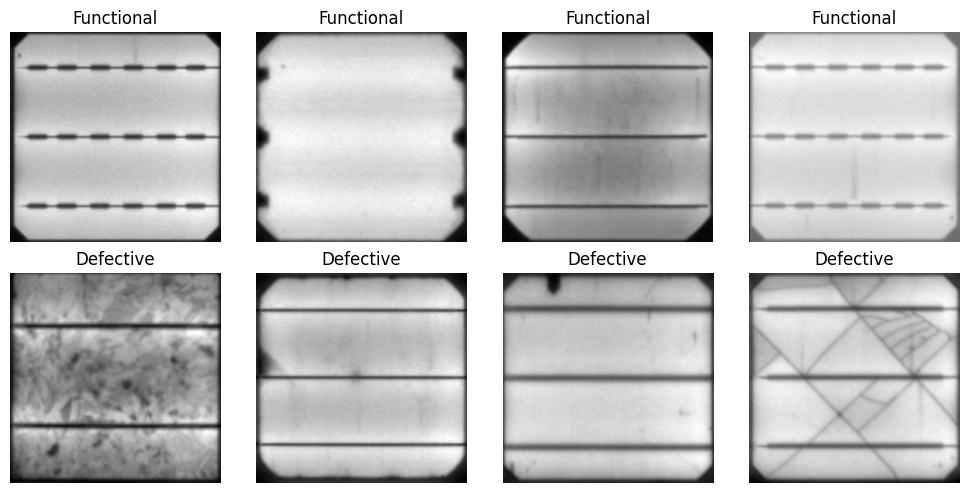


=== CELL 2 SUMMARY ===
All probability labels : {0.0: 1508, 0.3333333333333333: 295, 0.6666666666666666: 106, 1.0: 715}
Cell types             : {'poly': 1550, 'mono': 1074}
Functional (0.0)       : 1508
Defective (1.0)        : 715
Binary dataset total   : 2223
Ambiguous excluded     : 401
Missing image files    : 0
Dataset saved          : /content/elpv-dataset/outputs/tables/binary_dataset.csv
Figures saved          : /content/elpv-dataset/outputs/figures


In [3]:
# CELL 2: Parse labels + define Functional vs Defective dataset

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Read whitespace-separated ELPV labels
labels_df = pd.read_csv(
    LABEL_FILE,
    sep=r"\s+",
    header=None,
    names=["image", "defect_probability", "cell_type"]
)

# Extract filename and link with audited image paths
labels_df["filename"] = labels_df["image"].apply(lambda x: Path(str(x)).name)

path_map = dict(zip(audit_df["filename"], audit_df["filepath"]))
labels_df["filepath"] = labels_df["filename"].map(path_map)

# Keep only definite labels: 0.0 = Functional, 1.0 = Defective
binary_df = labels_df[
    labels_df["defect_probability"].isin([0.0, 1.0])
].copy()

binary_df["label"] = binary_df["defect_probability"].astype(int)
binary_df["class_name"] = binary_df["label"].map({
    0: "Functional",
    1: "Defective"
})

# Save dataset table
binary_df.to_csv(TAB_DIR / "binary_dataset.csv", index=False)

# Class counts
counts = binary_df["class_name"].value_counts()

# Figure 1: Class distribution
plt.figure(figsize=(6, 4))
counts.plot(kind="bar")
plt.title("ELPV Binary Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Sample images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for r, cls in enumerate(["Functional", "Defective"]):
    samples = binary_df[
        binary_df["class_name"] == cls
    ].sample(4, random_state=42)

    for c, path in enumerate(samples["filepath"]):
        axes[r, c].imshow(Image.open(path), cmap="gray")
        axes[r, c].set_title(cls)
        axes[r, c].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "sample_images.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Save label distribution table
label_summary = (
    labels_df["defect_probability"]
    .value_counts()
    .sort_index()
    .rename_axis("Defect_Probability")
    .reset_index(name="Count")
)

label_summary.to_csv(
    TAB_DIR / "defect_probability_distribution.csv",
    index=False
)

print("\n=== CELL 2 SUMMARY ===")
print(f"All probability labels : {labels_df['defect_probability'].value_counts().sort_index().to_dict()}")
print(f"Cell types             : {labels_df['cell_type'].value_counts().to_dict()}")
print(f"Functional (0.0)       : {counts.get('Functional', 0)}")
print(f"Defective (1.0)        : {counts.get('Defective', 0)}")
print(f"Binary dataset total   : {len(binary_df)}")
print(f"Ambiguous excluded     : {len(labels_df) - len(binary_df)}")
print(f"Missing image files    : {binary_df['filepath'].isna().sum()}")
print(f"Dataset saved          : {TAB_DIR / 'binary_dataset.csv'}")
print(f"Figures saved          : {FIG_DIR}")

In [4]:
# Explicit 5Vs description and data-provenance evidence
dataset_mib=sum(Path(p).stat().st_size for p in audit_df.filepath)/2**20
dimension_counts=audit_df.groupby(["width","height"]).size().to_dict()
five_vs_df=pd.DataFrame([
    ["Volume",f"2,624 source images; {len(binary_df):,} definite-label images; {dataset_mib:.2f} MiB; dimensions {dimension_counts}; grayscale PNG."],
    ["Velocity","Static research corpus. A production extension would accept individual or batch EL uploads after acquisition."],
    ["Variety","Functional/defective certainty labels, intermediate probabilities, mono/poly module types, defect appearances and controlled perturbations."],
    ["Veracity","Expert-derived probabilistic annotations; ambiguous labels excluded; corruption, missing files, split overlap, hashes and perceptual similarity audited."],
    ["Value","Prioritises potentially defective cells for expert review while reporting uncertainty and scope limitations."],
],columns=["V","Project_specific_description"])
five_vs_df.to_csv(TAB_DIR/"five_vs_summary.csv",index=False)
display(five_vs_df)


,V,Project_specific_description
0,Volume,"2,624 source images; 2,223 definite-label imag..."
1,Velocity,Static research corpus. A production extension...
2,Variety,"Functional/defective certainty labels, interme..."
3,Veracity,Expert-derived probabilistic annotations; ambi...
4,Value,Prioritises potentially defective cells for ex...


,Split,Total,Functional,Defective,Mono,Poly
0,Train,1556,1056,500,631,925
1,Validation,333,226,107,135,198
2,Test,334,226,108,135,199


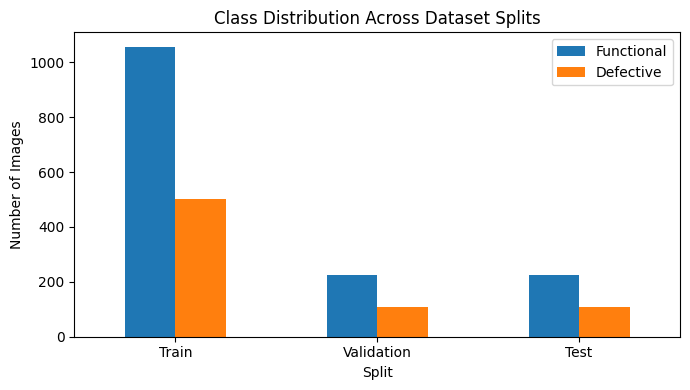


=== CELL 3 SUMMARY ===
Train     : 1556 | Functional=1056 | Defective=500
Validation: 333 | Functional=226 | Defective=107
Test      : 334 | Functional=226 | Defective=108
Train imbalance : 2.11:1
Overlap         : 0
Random seed     : 42
Table saved     : /content/elpv-dataset/outputs/tables/split_summary.csv
Figure saved    : /content/elpv-dataset/outputs/figures/split_distribution.png


In [5]:
# CELL 3: 70/15/15 stratified split + visualisation

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42

# Stratify by both disease label and cell type
binary_df["strata"] = (
    binary_df["label"].astype(str) + "_" + binary_df["cell_type"].astype(str)
)

train_df, temp_df = train_test_split(
    binary_df, test_size=0.30,
    stratify=binary_df["strata"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df["strata"], random_state=SEED
)

# Save splits
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    df.to_csv(TAB_DIR/f"{name}_split.csv", index=False)

# Summary
split_summary = pd.DataFrame([
    [name, len(df),
     (df.label==0).sum(), (df.label==1).sum(),
     (df.cell_type=="mono").sum(), (df.cell_type=="poly").sum()]
    for name, df in [("Train",train_df), ("Validation",val_df), ("Test",test_df)]
], columns=["Split","Total","Functional","Defective","Mono","Poly"])

split_summary.to_csv(TAB_DIR/"split_summary.csv", index=False)
display(split_summary)

# Split-distribution figure
split_summary.set_index("Split")[["Functional","Defective"]].plot(
    kind="bar", figsize=(7,4)
)
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR/"split_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Leakage check
sets = [set(df.filepath) for df in [train_df,val_df,test_df]]
overlap = len((sets[0]&sets[1]) | (sets[0]&sets[2]) | (sets[1]&sets[2]))

ratio = (train_df.label==0).sum() / (train_df.label==1).sum()

print("\n=== CELL 3 SUMMARY ===")
for _, r in split_summary.iterrows():
    print(f"{r.Split:<10}: {r.Total} | Functional={r.Functional} | Defective={r.Defective}")
print(f"Train imbalance : {ratio:.2f}:1")
print(f"Overlap         : {overlap}")
print(f"Random seed     : {SEED}")
print(f"Table saved     : {TAB_DIR/'split_summary.csv'}")
print(f"Figure saved    : {FIG_DIR/'split_distribution.png'}")

In [6]:
# Traditional baseline: 32x32 grayscale pixels with logistic regression
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,balanced_accuracy_score,confusion_matrix

MODEL_DIR=OUT/"models"; MODEL_DIR.mkdir(parents=True,exist_ok=True)

def pixel_features(frame,size=(32,32)):
    return np.stack([np.asarray(Image.open(p).convert("L").resize(size),dtype=np.float32).ravel()/255.0 for p in frame.filepath])

def choose_f1_threshold(labels,probabilities):
    grid=np.arange(.05,.951,.01)
    scores=np.array([f1_score(labels,probabilities>=t,zero_division=0) for t in grid])
    candidates=np.flatnonzero(scores==scores.max())
    return float(grid[candidates[np.argmin(abs(grid[candidates]-.5))]])

def binary_metrics(labels,probabilities,threshold):
    prediction=(np.asarray(probabilities)>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(labels,prediction,labels=[0,1]).ravel()
    return {"Accuracy":accuracy_score(labels,prediction),"Precision":precision_score(labels,prediction,zero_division=0),
        "Recall":recall_score(labels,prediction,zero_division=0),"Specificity":tn/(tn+fp),"F1":f1_score(labels,prediction,zero_division=0),
        "Balanced_Accuracy":balanced_accuracy_score(labels,prediction),"ROC_AUC":roc_auc_score(labels,probabilities),
        "Average_Precision":average_precision_score(labels,probabilities),"Locked_Threshold":threshold,
        "TN":tn,"FP":fp,"FN":fn,"TP":tp}

traditional_model=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced",solver="liblinear",random_state=SEED))
traditional_model.fit(pixel_features(train_df),train_df.label)
traditional_val_prob=traditional_model.predict_proba(pixel_features(val_df))[:,1]
TRADITIONAL_THRESHOLD=choose_f1_threshold(val_df.label.to_numpy(),traditional_val_prob)
traditional_test_prob=traditional_model.predict_proba(pixel_features(test_df))[:,1]
traditional_test_pred=(traditional_test_prob>=TRADITIONAL_THRESHOLD).astype(int)
traditional_metrics=binary_metrics(test_df.label.to_numpy(),traditional_test_prob,TRADITIONAL_THRESHOLD)
pd.DataFrame([{"Model":"Logistic pixel baseline",**traditional_metrics}]).to_csv(TAB_DIR/"traditional_baseline_test_metrics.csv",index=False)
pd.DataFrame({"filepath":test_df.filepath,"true_label":test_df.label,"defective_probability":traditional_test_prob,"prediction":traditional_test_pred}).to_csv(TAB_DIR/"traditional_baseline_test_predictions.csv",index=False)
joblib.dump(traditional_model,MODEL_DIR/"traditional_logistic_baseline.joblib")
display(pd.DataFrame([traditional_metrics]).round(4))
print("Threshold selected on validation only; test evaluated once.")


,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,Average_Precision,Locked_Threshold,TN,FP,FN,TP
0,0.7455,0.5865,0.7222,0.7566,0.6473,0.7394,0.78,0.7068,0.33,171,55,30,78


Threshold selected on validation only; test evaluated once.


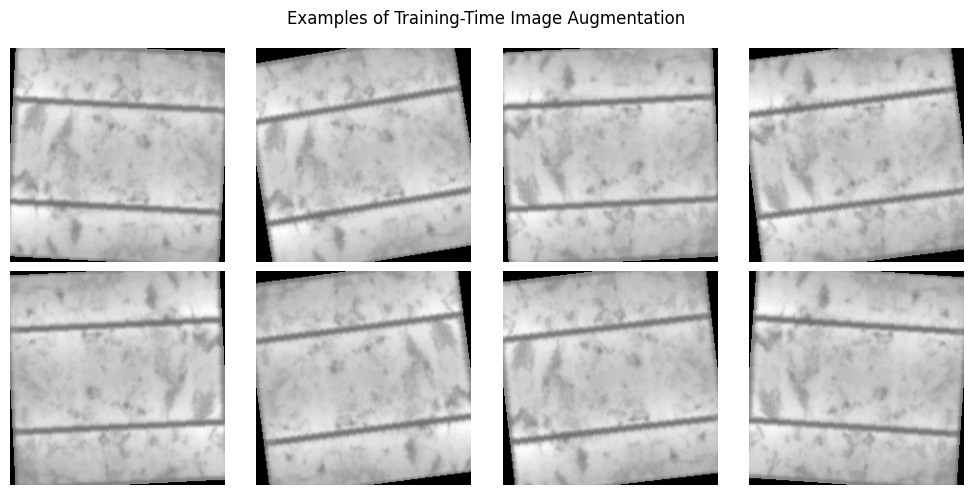


=== CELL 4 SUMMARY ===
Train/Val/Test : 1556/333/334
Batch shape    : (32, 1, 224, 224)
Image size     : 224x224
Train mean/std : 0.5935 / 0.1613
Positive weight: 2.1120
Device         : cuda
Figure saved   : /content/elpv-dataset/outputs/figures/augmentation_examples.png
Table saved    : /content/elpv-dataset/outputs/tables/preprocessing_config.csv


In [7]:
# CELL 4: Preprocessing + PyTorch DataLoaders + imbalance setup

import numpy as np, torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE, BATCH = 224, 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training-set mean/std
s, ss, n = 0., 0., 0
for p in train_df.filepath:
    a = np.asarray(Image.open(p).convert("L"), dtype=np.float32) / 255.
    s += a.sum(); ss += (a*a).sum(); n += a.size

mean = s/n
std = np.sqrt(ss/n - mean**2)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([mean], [std])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([mean], [std])
])

class ELPVDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r.filepath).convert("L")
        return self.transform(img), torch.tensor(float(r.label))

train_set = ELPVDataset(train_df, train_tfms)
val_set   = ELPVDataset(val_df, eval_tfms)
test_set  = ELPVDataset(test_df, eval_tfms)

train_loader = DataLoader(train_set, BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set, BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set, BATCH, shuffle=False, num_workers=0)

# Positive-class weight: Defective class receives higher loss weight
pos_weight = torch.tensor(
    [(train_df.label==0).sum() / (train_df.label==1).sum()],
    dtype=torch.float32, device=device
)

# Save preprocessing configuration
config_df = pd.DataFrame({
    "Setting": ["Image size","Batch size","Train mean","Train std",
                "Functional","Defective","Positive class weight"],
    "Value": [IMG_SIZE, BATCH, mean, std,
              (train_df.label==0).sum(), (train_df.label==1).sum(),
              pos_weight.item()]
})
config_df.to_csv(TAB_DIR/"preprocessing_config.csv", index=False)

# Visualise augmented examples
sample_img = Image.open(train_df.iloc[0].filepath).convert("L")
fig, axes = plt.subplots(2, 4, figsize=(10,5))

for ax in axes.flat:
    x = train_tfms(sample_img).squeeze().numpy()
    ax.imshow(x, cmap="gray")
    ax.axis("off")

plt.suptitle("Examples of Training-Time Image Augmentation")
plt.tight_layout()
plt.savefig(FIG_DIR/"augmentation_examples.png", dpi=300, bbox_inches="tight")
plt.show()

xb, yb = next(iter(train_loader))

print("\n=== CELL 4 SUMMARY ===")
print(f"Train/Val/Test : {len(train_set)}/{len(val_set)}/{len(test_set)}")
print(f"Batch shape    : {tuple(xb.shape)}")
print(f"Image size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"Train mean/std : {mean:.4f} / {std:.4f}")
print(f"Positive weight: {pos_weight.item():.4f}")
print(f"Device         : {device}")
print(f"Figure saved   : {FIG_DIR/'augmentation_examples.png'}")
print(f"Table saved    : {TAB_DIR/'preprocessing_config.csv'}")

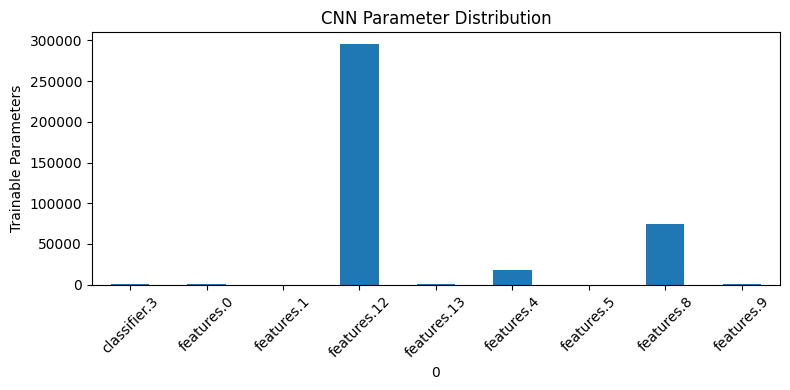


=== CELL 5 SUMMARY ===
Model             : ELPVCNN
Input channels    : 1 (grayscale)
Trainable params  : 389,057
Loss              : Weighted BCEWithLogitsLoss
Positive weight   : 2.1120
Optimizer         : Adam
Learning rate     : 0.001
Device            : cuda
Figure saved      : /content/elpv-dataset/outputs/figures/model_parameter_distribution.png
Table saved       : /content/elpv-dataset/outputs/tables/model_parameters.csv


In [8]:
# CELL 5: Define lightweight grayscale CNN

import torch.nn as nn
import matplotlib.pyplot as plt

class ELPVCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(256,1)
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

model = ELPVCNN().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Parameter summary
param_df = pd.DataFrame([
    [n, p.numel()] for n,p in model.named_parameters() if p.requires_grad
], columns=["Layer","Parameters"])

param_df.to_csv(TAB_DIR/"model_parameters.csv", index=False)

# Parameter distribution figure
plot_df = param_df.groupby(
    param_df["Layer"].str.extract(r'(^features\.\d+|^classifier\.\d+)')[0]
)["Parameters"].sum()

plt.figure(figsize=(8,4))
plot_df.plot(kind="bar")
plt.ylabel("Trainable Parameters")
plt.title("CNN Parameter Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR/"model_parameter_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Save architecture text
(OUT/"model_architecture.txt").write_text(str(model), encoding="utf-8")

params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n=== CELL 5 SUMMARY ===")
print(f"Model             : ELPVCNN")
print(f"Input channels    : 1 (grayscale)")
print(f"Trainable params  : {params:,}")
print(f"Loss              : Weighted BCEWithLogitsLoss")
print(f"Positive weight   : {pos_weight.item():.4f}")
print(f"Optimizer         : Adam")
print(f"Learning rate     : 0.001")
print(f"Device            : {device}")
print(f"Figure saved      : {FIG_DIR/'model_parameter_distribution.png'}")
print(f"Table saved       : {TAB_DIR/'model_parameters.csv'}")

Epoch 01/30 | Train Loss 0.7886 | Val Loss 0.8138 | Train Acc 0.7294 | Val Acc 0.7387 | Val F1 0.5837 | LR 0.001000
Epoch 02/30 | Train Loss 0.7362 | Val Loss 0.7772 | Train Acc 0.7641 | Val Acc 0.7447 | Val F1 0.6047 | LR 0.001000
Epoch 03/30 | Train Loss 0.7115 | Val Loss 0.7956 | Train Acc 0.7763 | Val Acc 0.7538 | Val F1 0.6404 | LR 0.001000
Epoch 04/30 | Train Loss 0.6802 | Val Loss 0.7717 | Train Acc 0.7719 | Val Acc 0.7628 | Val F1 0.6070 | LR 0.001000
Epoch 05/30 | Train Loss 0.6992 | Val Loss 0.9706 | Train Acc 0.7641 | Val Acc 0.4024 | Val F1 0.5111 | LR 0.001000
Epoch 06/30 | Train Loss 0.7107 | Val Loss 0.7476 | Train Acc 0.7699 | Val Acc 0.7147 | Val F1 0.6122 | LR 0.001000
Epoch 07/30 | Train Loss 0.6747 | Val Loss 0.7871 | Train Acc 0.7815 | Val Acc 0.7538 | Val F1 0.6019 | LR 0.001000
Epoch 08/30 | Train Loss 0.6862 | Val Loss 0.7652 | Train Acc 0.7725 | Val Acc 0.6697 | Val F1 0.6043 | LR 0.001000
Epoch 09/30 | Train Loss 0.6762 | Val Loss 0.8670 | Train Acc 0.7699 | V

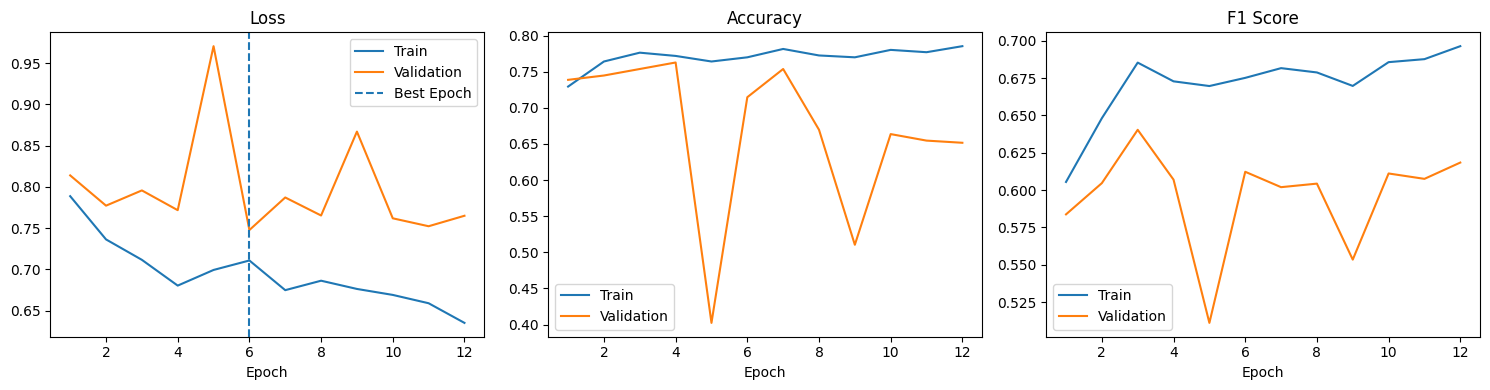


=== CELL 6 SUMMARY ===
Epochs completed : 12
Best epoch       : 6
Best val loss    : 0.7476
Best val accuracy: 0.7147
Best val F1      : 0.6122
Training time    : 2.14 minutes
Best model saved : /content/elpv-dataset/outputs/models/best_elpv_cnn.pt
History saved    : /content/elpv-dataset/outputs/tables/training_history.csv
Figure saved     : /content/elpv-dataset/outputs/figures/training_history.png


In [9]:
# CELL 6: Train CNN with early stopping + LR scheduling + best-model saving

import time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

MODEL_DIR = OUT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 30
PATIENCE = 6

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

history = []
best_loss = float("inf")
best_epoch = 0
wait = 0
best_state = None

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_true, train_pred = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        train_true.extend(yb.cpu().numpy().astype(int))
        train_pred.extend(preds.cpu().numpy())

    train_loss /= len(train_set)
    train_acc = np.mean(np.array(train_true) == np.array(train_pred))
    train_f1 = f1_score(train_true, train_pred)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_true, val_pred = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            val_true.extend(yb.cpu().numpy().astype(int))
            val_pred.extend(preds.cpu().numpy())

    val_loss /= len(val_set)
    val_acc = np.mean(np.array(val_true) == np.array(val_pred))
    val_f1 = f1_score(val_true, val_pred)

    lr = optimizer.param_groups[0]["lr"]

    history.append([
        epoch, train_loss, val_loss,
        train_acc, val_acc,
        train_f1, val_f1, lr
    ])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | "
        f"Val F1 {val_f1:.4f} | LR {lr:.6f}"
    )

    # LR scheduler
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break


# Restore and save best model
model.load_state_dict(best_state)

BEST_MODEL = MODEL_DIR / "best_elpv_cnn.pt"
torch.save(best_state, BEST_MODEL)

# Training history
history_df = pd.DataFrame(
    history,
    columns=[
        "Epoch", "Train_Loss", "Val_Loss",
        "Train_Accuracy", "Val_Accuracy",
        "Train_F1", "Val_F1", "Learning_Rate"
    ]
)

history_df.to_csv(
    TAB_DIR / "training_history.csv",
    index=False
)

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df.Epoch, history_df.Train_Loss, label="Train")
axes[0].plot(history_df.Epoch, history_df.Val_Loss, label="Validation")
axes[0].axvline(best_epoch, linestyle="--", label="Best Epoch")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df.Epoch, history_df.Train_Accuracy, label="Train")
axes[1].plot(history_df.Epoch, history_df.Val_Accuracy, label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history_df.Epoch, history_df.Train_F1, label="Train")
axes[2].plot(history_df.Epoch, history_df.Val_F1, label="Validation")
axes[2].set_title("F1 Score")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(
    FIG_DIR / "training_history.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

best_row = history_df.loc[
    history_df.Epoch == best_epoch
].iloc[0]

elapsed = time.time() - start_time

print("\n=== CELL 6 SUMMARY ===")
print(f"Epochs completed : {len(history_df)}")
print(f"Best epoch       : {best_epoch}")
print(f"Best val loss    : {best_row.Val_Loss:.4f}")
print(f"Best val accuracy: {best_row.Val_Accuracy:.4f}")
print(f"Best val F1      : {best_row.Val_F1:.4f}")
print(f"Training time    : {elapsed/60:.2f} minutes")
print(f"Best model saved : {BEST_MODEL}")
print(f"History saved    : {TAB_DIR/'training_history.csv'}")
print(f"Figure saved     : {FIG_DIR/'training_history.png'}")

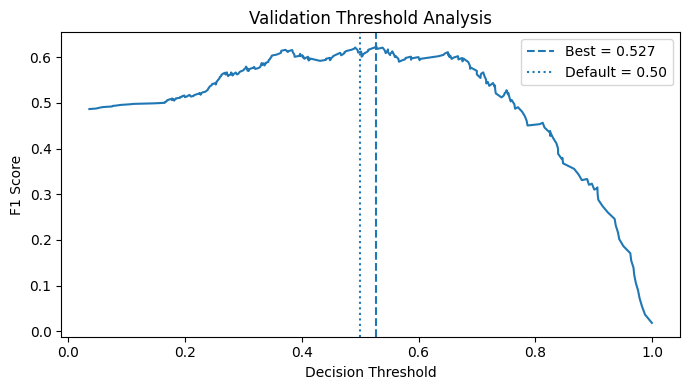

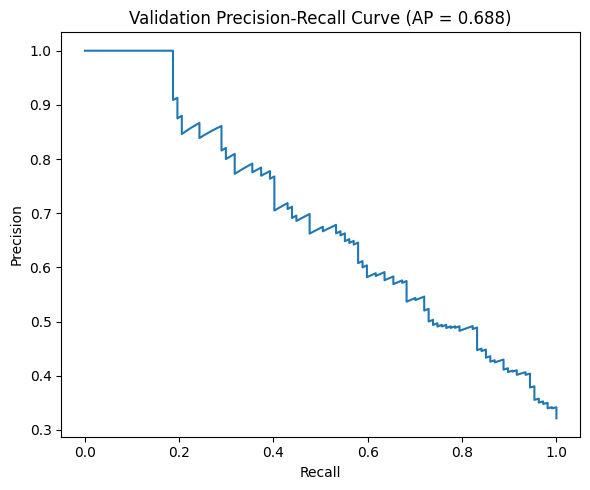


=== CELL 6B SUMMARY ===
Validation ROC-AUC       : 0.7861
Validation Average Prec. : 0.6884

Threshold 0.50
Accuracy                 : 0.7147
Precision                : 0.5435
Recall                   : 0.7009
F1                        : 0.6122
Confusion matrix          : [[163, 63], [32, 75]]

Best validation threshold : 0.5274
Accuracy                  : 0.7357
Precision                 : 0.5748
Recall                    : 0.6822
F1                         : 0.6239
Confusion matrix           : [[172, 54], [34, 73]]

Table saved                : /content/elpv-dataset/outputs/tables/baseline_validation_diagnostic.csv
Figures saved              : /content/elpv-dataset/outputs/figures


In [10]:
# CELL 6B: Validation diagnostic — AUC, AP and threshold analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)

# Ensure best model is loaded
model.load_state_dict(
    torch.load(BEST_MODEL, map_location=device)
)
model.eval()

val_true, val_prob = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        val_prob.extend(probs.cpu().numpy())
        val_true.extend(yb.numpy())

val_true = np.array(val_true).astype(int)
val_prob = np.array(val_prob)

# -----------------------------
# Default threshold = 0.50
# -----------------------------
pred_05 = (val_prob >= 0.50).astype(int)

acc_05 = accuracy_score(val_true, pred_05)
prec_05 = precision_score(val_true, pred_05, zero_division=0)
rec_05 = recall_score(val_true, pred_05, zero_division=0)
f1_05 = f1_score(val_true, pred_05, zero_division=0)

roc_auc = roc_auc_score(val_true, val_prob)
ap = average_precision_score(val_true, val_prob)

# -----------------------------
# Validation-only threshold search
# -----------------------------
precision, recall, thresholds = precision_recall_curve(
    val_true, val_prob
)

f1_values = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-12)
)

best_idx = np.argmax(f1_values)
best_threshold = thresholds[best_idx]

pred_best = (val_prob >= best_threshold).astype(int)

acc_best = accuracy_score(val_true, pred_best)
prec_best = precision_score(val_true, pred_best, zero_division=0)
rec_best = recall_score(val_true, pred_best, zero_division=0)
f1_best = f1_score(val_true, pred_best, zero_division=0)

# -----------------------------
# Save results
# -----------------------------
diagnostic_df = pd.DataFrame([
    ["Threshold_0.50", 0.50,
     acc_05, prec_05, rec_05, f1_05,
     roc_auc, ap],

    ["Validation_Selected", best_threshold,
     acc_best, prec_best, rec_best, f1_best,
     roc_auc, ap]

], columns=[
    "Method", "Threshold",
    "Accuracy", "Precision", "Recall", "F1",
    "ROC_AUC", "Average_Precision"
])

diagnostic_df.to_csv(
    TAB_DIR / "baseline_validation_diagnostic.csv",
    index=False
)

# Save probabilities
pd.DataFrame({
    "True_Label": val_true,
    "Defective_Probability": val_prob
}).to_csv(
    TAB_DIR / "validation_probabilities.csv",
    index=False
)

# -----------------------------
# Figure 1: Threshold vs F1
# -----------------------------
plt.figure(figsize=(7,4))

plt.plot(thresholds, f1_values)
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best = {best_threshold:.3f}"
)
plt.axvline(
    0.50,
    linestyle=":",
    label="Default = 0.50"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("Validation Threshold Analysis")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "baseline_threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# Figure 2: Precision-Recall curve
# -----------------------------
plt.figure(figsize=(6,5))

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Validation Precision-Recall Curve (AP = {ap:.3f})")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "baseline_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -----------------------------
# Confusion matrices
# -----------------------------
cm05 = confusion_matrix(val_true, pred_05)
cmbest = confusion_matrix(val_true, pred_best)

print("\n=== CELL 6B SUMMARY ===")
print(f"Validation ROC-AUC       : {roc_auc:.4f}")
print(f"Validation Average Prec. : {ap:.4f}")
print()
print(f"Threshold 0.50")
print(f"Accuracy                 : {acc_05:.4f}")
print(f"Precision                : {prec_05:.4f}")
print(f"Recall                   : {rec_05:.4f}")
print(f"F1                        : {f1_05:.4f}")
print(f"Confusion matrix          : {cm05.tolist()}")
print()
print(f"Best validation threshold : {best_threshold:.4f}")
print(f"Accuracy                  : {acc_best:.4f}")
print(f"Precision                 : {prec_best:.4f}")
print(f"Recall                    : {rec_best:.4f}")
print(f"F1                         : {f1_best:.4f}")
print(f"Confusion matrix           : {cmbest.tolist()}")
print()
print(f"Table saved                : {TAB_DIR/'baseline_validation_diagnostic.csv'}")
print(f"Figures saved              : {FIG_DIR}")

In [11]:
# CELL 7: ResNet18 transfer-learning setup

import torch
import torch.nn as nn
import pandas as pd
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

# -------------------------------------------------
# 1. ImageNet-compatible preprocessing
# -------------------------------------------------

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        224, scale=(0.90, 1.00)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(7),

    # ELPV images are grayscale → replicate into 3 channels
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

resnet_eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


# -------------------------------------------------
# 2. Datasets and loaders
# -------------------------------------------------

resnet_train_set = ELPVDataset(
    train_df, resnet_train_tfms
)

resnet_val_set = ELPVDataset(
    val_df, resnet_eval_tfms
)

resnet_test_set = ELPVDataset(
    test_df, resnet_eval_tfms
)

resnet_train_loader = DataLoader(
    resnet_train_set,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

resnet_val_loader = DataLoader(
    resnet_val_set,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

resnet_test_loader = DataLoader(
    resnet_test_set,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# -------------------------------------------------
# 3. Load fixed pretrained ResNet18
# -------------------------------------------------

weights = ResNet18_Weights.IMAGENET1K_V1
resnet_model = resnet18(weights=weights)

# Replace ImageNet 1000-class output with binary output
in_features = resnet_model.fc.in_features

resnet_model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, 1)
)

resnet_model = resnet_model.to(device)


# -------------------------------------------------
# 4. Stage-1 strategy:
#    freeze backbone, train classifier first
# -------------------------------------------------

for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True


# Weighted loss retained because training set is imbalanced
resnet_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

resnet_optimizer = torch.optim.AdamW(
    resnet_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# -------------------------------------------------
# 5. Parameter information
# -------------------------------------------------

total_params = sum(
    p.numel() for p in resnet_model.parameters()
)

trainable_params = sum(
    p.numel() for p in resnet_model.parameters()
    if p.requires_grad
)

parameter_summary = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet18 Stage 1"],
    "Total_Parameters": [
        sum(p.numel() for p in model.parameters()),
        total_params
    ],
    "Trainable_Parameters": [
        sum(p.numel() for p in model.parameters()
            if p.requires_grad),
        trainable_params
    ]
})

parameter_summary.to_csv(
    TAB_DIR / "baseline_vs_resnet_parameters.csv",
    index=False
)


# Check one batch
xb, yb = next(iter(resnet_train_loader))


print("\n=== CELL 7 SUMMARY ===")
print(f"Model              : ResNet18")
print(f"Pretrained weights : ImageNet-1K V1")
print(f"Input shape        : {tuple(xb.shape)}")
print(f"Train images       : {len(resnet_train_set)}")
print(f"Validation images  : {len(resnet_val_set)}")
print(f"Test images        : {len(resnet_test_set)}")
print(f"Total parameters   : {total_params:,}")
print(f"Trainable Stage 1  : {trainable_params:,}")
print(f"Loss               : Weighted BCEWithLogitsLoss")
print(f"Positive weight    : {pos_weight.item():.4f}")
print(f"Optimizer           : AdamW")
print(f"Initial LR          : 0.001")
print(f"Device              : {device}")
print(f"Table saved         : {TAB_DIR/'baseline_vs_resnet_parameters.csv'}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]



=== CELL 7 SUMMARY ===
Model              : ResNet18
Pretrained weights : ImageNet-1K V1
Input shape        : (32, 3, 224, 224)
Train images       : 1556
Validation images  : 333
Test images        : 334
Total parameters   : 11,177,025
Trainable Stage 1  : 513
Loss               : Weighted BCEWithLogitsLoss
Positive weight    : 2.1120
Optimizer           : AdamW
Initial LR          : 0.001
Device              : cuda
Table saved         : /content/elpv-dataset/outputs/tables/baseline_vs_resnet_parameters.csv


=== STAGE 1: CLASSIFIER WARM-UP ===
Epoch 01 | Train Acc 0.5816 | Val Acc 0.7147 | Val F1 0.4693 | Val AUC 0.7406
Epoch 02 | Train Acc 0.7089 | Val Acc 0.7297 | Val F1 0.5872 | Val AUC 0.8050
Epoch 03 | Train Acc 0.7397 | Val Acc 0.7447 | Val F1 0.6502 | Val AUC 0.8100
Epoch 04 | Train Acc 0.7622 | Val Acc 0.7357 | Val F1 0.6239 | Val AUC 0.8128
Epoch 05 | Train Acc 0.7661 | Val Acc 0.7327 | Val F1 0.6009 | Val AUC 0.8200

=== STAGE 2: FINE-TUNING ===
Epoch 06 | Train Acc 0.7853 | Val Acc 0.7868 | Val F1 0.6502 | Val AUC 0.8337 | LR 0.000100
Epoch 07 | Train Acc 0.8085 | Val Acc 0.7568 | Val F1 0.6524 | Val AUC 0.8510 | LR 0.000100
Epoch 08 | Train Acc 0.8226 | Val Acc 0.8048 | Val F1 0.6561 | Val AUC 0.8584 | LR 0.000100
Epoch 09 | Train Acc 0.8162 | Val Acc 0.8318 | Val F1 0.7113 | Val AUC 0.8670 | LR 0.000100
Epoch 10 | Train Acc 0.8374 | Val Acc 0.8168 | Val F1 0.6935 | Val AUC 0.8610 | LR 0.000100
Epoch 11 | Train Acc 0.8445 | Val Acc 0.8048 | Val F1 0.7059 | Val AUC 0.8841 | LR 0

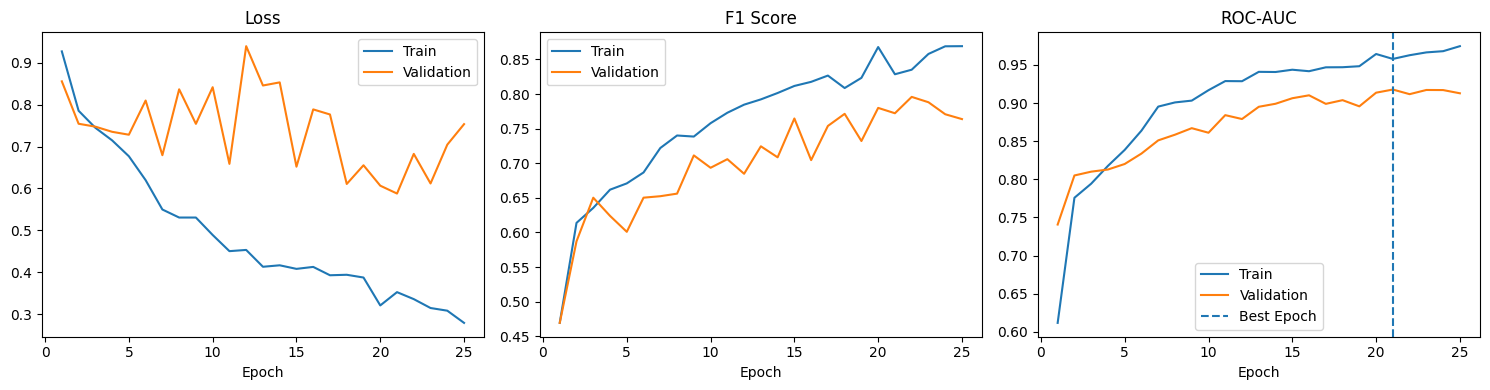


=== CELL 8 SUMMARY ===
Total epochs       : 25
Best epoch         : 21
Best stage         : Fine-tune
Best val accuracy  : 0.8619
Best val F1        : 0.7723
Best val ROC-AUC   : 0.9177
Best val loss      : 0.5878
Trainable Stage 2  : 8,394,241
Training time      : 5.16 minutes
Best model saved   : /content/elpv-dataset/outputs/models/best_resnet18_elpv.pt
History saved      : /content/elpv-dataset/outputs/tables/resnet18_training_history.csv
Figure saved       : /content/elpv-dataset/outputs/figures/resnet18_training_history.png


In [12]:
# CELL 8: ResNet18 warm-up + fine-tuning (CORRECTED)

import time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, roc_auc_score

MODEL_DIR = OUT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

history = []
best_auc = -1
best_state = None
best_epoch = 0
global_epoch = 0


# -------------------------------------------------------
# Helper function
# -------------------------------------------------------
def run_epoch(loader, training, optimizer=None):

    if training:
        resnet_model.train()
    else:
        resnet_model.eval()

    total_loss = 0
    all_true, all_prob = [], []

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device).float()

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            # ResNet output originally = [batch, 1]
            # Convert to [batch] to match yb
            logits = resnet_model(xb).squeeze(1)

            loss = resnet_criterion(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)

        total_loss += loss.item() * xb.size(0)

        all_true.extend(
            yb.detach().cpu().numpy().astype(int)
        )

        all_prob.extend(
            probs.detach().cpu().numpy()
        )

    all_true = np.array(all_true)
    all_prob = np.array(all_prob)

    pred = (all_prob >= 0.5).astype(int)

    loss_value = total_loss / len(loader.dataset)
    accuracy = np.mean(pred == all_true)
    f1 = f1_score(
        all_true, pred, zero_division=0
    )
    auc = roc_auc_score(
        all_true, all_prob
    )

    return loss_value, accuracy, f1, auc


# =======================================================
# STAGE 1 — CLASSIFIER WARM-UP
# =======================================================

STAGE1_EPOCHS = 5

print("=== STAGE 1: CLASSIFIER WARM-UP ===")

start = time.time()

for epoch in range(1, STAGE1_EPOCHS + 1):

    global_epoch += 1

    tr_loss, tr_acc, tr_f1, tr_auc = run_epoch(
        resnet_train_loader,
        True,
        resnet_optimizer
    )

    va_loss, va_acc, va_f1, va_auc = run_epoch(
        resnet_val_loader,
        False
    )

    history.append([
        global_epoch,
        "Warm-up",
        tr_loss,
        va_loss,
        tr_acc,
        va_acc,
        tr_f1,
        va_f1,
        tr_auc,
        va_auc,
        resnet_optimizer.param_groups[0]["lr"]
    ])

    print(
        f"Epoch {global_epoch:02d} | "
        f"Train Acc {tr_acc:.4f} | "
        f"Val Acc {va_acc:.4f} | "
        f"Val F1 {va_f1:.4f} | "
        f"Val AUC {va_auc:.4f}"
    )

    if va_auc > best_auc:

        best_auc = va_auc
        best_epoch = global_epoch

        best_state = copy.deepcopy(
            resnet_model.state_dict()
        )


# =======================================================
# STAGE 2 — FINE-TUNE LAYER 4 + CLASSIFIER
# =======================================================

# Freeze everything
for p in resnet_model.parameters():
    p.requires_grad = False

# Unfreeze last residual block
for p in resnet_model.layer4.parameters():
    p.requires_grad = True

# Unfreeze classifier
for p in resnet_model.fc.parameters():
    p.requires_grad = True


fine_optimizer = torch.optim.AdamW(
    [
        {
            "params": resnet_model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": resnet_model.fc.parameters(),
            "lr": 3e-4
        }
    ],
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    fine_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


STAGE2_EPOCHS = 20
PATIENCE = 5

wait = 0

print("\n=== STAGE 2: FINE-TUNING ===")

for epoch in range(1, STAGE2_EPOCHS + 1):

    global_epoch += 1

    tr_loss, tr_acc, tr_f1, tr_auc = run_epoch(
        resnet_train_loader,
        True,
        fine_optimizer
    )

    va_loss, va_acc, va_f1, va_auc = run_epoch(
        resnet_val_loader,
        False
    )

    current_lr = fine_optimizer.param_groups[0]["lr"]

    history.append([
        global_epoch,
        "Fine-tune",
        tr_loss,
        va_loss,
        tr_acc,
        va_acc,
        tr_f1,
        va_f1,
        tr_auc,
        va_auc,
        current_lr
    ])

    print(
        f"Epoch {global_epoch:02d} | "
        f"Train Acc {tr_acc:.4f} | "
        f"Val Acc {va_acc:.4f} | "
        f"Val F1 {va_f1:.4f} | "
        f"Val AUC {va_auc:.4f} | "
        f"LR {current_lr:.6f}"
    )

    scheduler.step(va_auc)

    if va_auc > best_auc + 1e-4:

        best_auc = va_auc
        best_epoch = global_epoch

        best_state = copy.deepcopy(
            resnet_model.state_dict()
        )

        wait = 0

    else:
        wait += 1

    if wait >= PATIENCE:

        print(
            f"\nEarly stopping at epoch "
            f"{global_epoch}."
        )

        break


# -------------------------------------------------------
# Restore best model
# -------------------------------------------------------

resnet_model.load_state_dict(
    best_state
)

RESNET_MODEL_PATH = (
    MODEL_DIR / "best_resnet18_elpv.pt"
)

torch.save(
    best_state,
    RESNET_MODEL_PATH
)


# -------------------------------------------------------
# Save history
# -------------------------------------------------------

history_df = pd.DataFrame(
    history,
    columns=[
        "Epoch",
        "Stage",
        "Train_Loss",
        "Val_Loss",
        "Train_Accuracy",
        "Val_Accuracy",
        "Train_F1",
        "Val_F1",
        "Train_AUC",
        "Val_AUC",
        "Learning_Rate"
    ]
)

history_df.to_csv(
    TAB_DIR / "resnet18_training_history.csv",
    index=False
)


# -------------------------------------------------------
# Training curves
# -------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4)
)

axes[0].plot(
    history_df.Epoch,
    history_df.Train_Loss,
    label="Train"
)

axes[0].plot(
    history_df.Epoch,
    history_df.Val_Loss,
    label="Validation"
)

axes[0].set_title("Loss")
axes[0].legend()


axes[1].plot(
    history_df.Epoch,
    history_df.Train_F1,
    label="Train"
)

axes[1].plot(
    history_df.Epoch,
    history_df.Val_F1,
    label="Validation"
)

axes[1].set_title("F1 Score")
axes[1].legend()


axes[2].plot(
    history_df.Epoch,
    history_df.Train_AUC,
    label="Train"
)

axes[2].plot(
    history_df.Epoch,
    history_df.Val_AUC,
    label="Validation"
)

axes[2].axvline(
    best_epoch,
    linestyle="--",
    label="Best Epoch"
)

axes[2].set_title("ROC-AUC")
axes[2].legend()


for ax in axes:
    ax.set_xlabel("Epoch")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_training_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Best epoch results
# -------------------------------------------------------

best_row = history_df.loc[
    history_df.Epoch == best_epoch
].iloc[0]

trainable_final = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)

elapsed = time.time() - start


print("\n=== CELL 8 SUMMARY ===")

print(
    f"Total epochs       : "
    f"{len(history_df)}"
)

print(
    f"Best epoch         : "
    f"{best_epoch}"
)

print(
    f"Best stage         : "
    f"{best_row.Stage}"
)

print(
    f"Best val accuracy  : "
    f"{best_row.Val_Accuracy:.4f}"
)

print(
    f"Best val F1        : "
    f"{best_row.Val_F1:.4f}"
)

print(
    f"Best val ROC-AUC   : "
    f"{best_row.Val_AUC:.4f}"
)

print(
    f"Best val loss      : "
    f"{best_row.Val_Loss:.4f}"
)

print(
    f"Trainable Stage 2  : "
    f"{trainable_final:,}"
)

print(
    f"Training time      : "
    f"{elapsed/60:.2f} minutes"
)

print(
    f"Best model saved   : "
    f"{RESNET_MODEL_PATH}"
)

print(
    f"History saved      : "
    f"{TAB_DIR/'resnet18_training_history.csv'}"
)

print(
    f"Figure saved       : "
    f"{FIG_DIR/'resnet18_training_history.png'}"
)

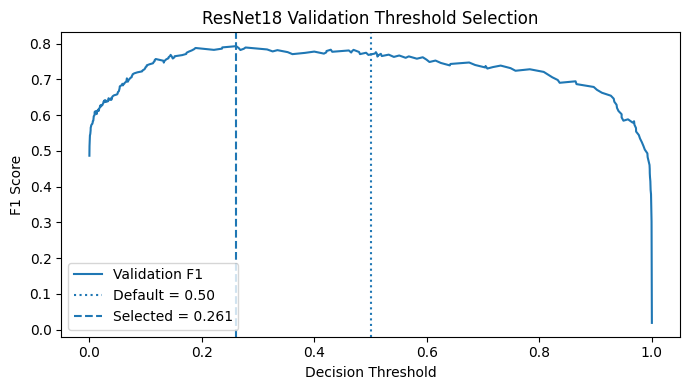


=== CELL 9 SUMMARY ===
Validation ROC-AUC       : 0.9177
Validation Average Prec. : 0.8797

Threshold = 0.50
Accuracy                 : 0.8619
Precision                : 0.8211
Recall                   : 0.7290
F1                        : 0.7723
Confusion matrix          : [[209, 17], [29, 78]]

Validation-selected threshold
Threshold                 : 0.2609
Accuracy                  : 0.8589
Precision                 : 0.7500
Recall                    : 0.8411
F1                         : 0.7930
Confusion matrix           : [[196, 30], [17, 90]]

Threshold saved           : /content/elpv-dataset/outputs/tables/resnet18_locked_threshold.csv
Figure saved              : /content/elpv-dataset/outputs/figures/resnet18_threshold_selection.png


In [13]:
# CELL 9: Validation-only threshold selection for ResNet18

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)

# Ensure best checkpoint is loaded
resnet_model.load_state_dict(
    torch.load(RESNET_MODEL_PATH, map_location=device)
)
resnet_model.eval()

val_true, val_prob = [], []

with torch.no_grad():
    for xb, yb in resnet_val_loader:

        xb = xb.to(device)

        logits = resnet_model(xb).squeeze(1)
        probs = torch.sigmoid(logits)

        val_true.extend(yb.numpy().astype(int))
        val_prob.extend(probs.cpu().numpy())

val_true = np.array(val_true)
val_prob = np.array(val_prob)

# Overall discrimination
roc_auc = roc_auc_score(val_true, val_prob)
ap = average_precision_score(val_true, val_prob)

# -------------------------------------------------
# Default threshold = 0.50
# -------------------------------------------------

pred_05 = (val_prob >= 0.50).astype(int)

metrics_05 = {
    "Accuracy": accuracy_score(val_true, pred_05),
    "Precision": precision_score(val_true, pred_05, zero_division=0),
    "Recall": recall_score(val_true, pred_05, zero_division=0),
    "F1": f1_score(val_true, pred_05, zero_division=0)
}

# -------------------------------------------------
# Select threshold using VALIDATION F1 only
# -------------------------------------------------

precision, recall, thresholds = precision_recall_curve(
    val_true, val_prob
)

f1_values = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-12)
)

best_idx = np.argmax(f1_values)
BEST_RESNET_THRESHOLD = float(thresholds[best_idx])

pred_best = (
    val_prob >= BEST_RESNET_THRESHOLD
).astype(int)

metrics_best = {
    "Accuracy": accuracy_score(val_true, pred_best),
    "Precision": precision_score(val_true, pred_best, zero_division=0),
    "Recall": recall_score(val_true, pred_best, zero_division=0),
    "F1": f1_score(val_true, pred_best, zero_division=0)
}

# -------------------------------------------------
# Save results
# -------------------------------------------------

threshold_df = pd.DataFrame([
    [
        "Default",
        0.50,
        metrics_05["Accuracy"],
        metrics_05["Precision"],
        metrics_05["Recall"],
        metrics_05["F1"],
        roc_auc,
        ap
    ],
    [
        "Validation_Selected",
        BEST_RESNET_THRESHOLD,
        metrics_best["Accuracy"],
        metrics_best["Precision"],
        metrics_best["Recall"],
        metrics_best["F1"],
        roc_auc,
        ap
    ]
], columns=[
    "Method", "Threshold",
    "Accuracy", "Precision", "Recall", "F1",
    "ROC_AUC", "Average_Precision"
])

threshold_df.to_csv(
    TAB_DIR / "resnet18_validation_threshold.csv",
    index=False
)

# Save locked threshold separately
pd.DataFrame({
    "Model": ["ResNet18"],
    "Selected_Threshold": [BEST_RESNET_THRESHOLD],
    "Selection_Data": ["Validation only"],
    "Selection_Metric": ["F1"]
}).to_csv(
    TAB_DIR / "resnet18_locked_threshold.csv",
    index=False
)

# -------------------------------------------------
# Threshold figure
# -------------------------------------------------

plt.figure(figsize=(7,4))

plt.plot(
    thresholds,
    f1_values,
    label="Validation F1"
)

plt.axvline(
    0.50,
    linestyle=":",
    label="Default = 0.50"
)

plt.axvline(
    BEST_RESNET_THRESHOLD,
    linestyle="--",
    label=f"Selected = {BEST_RESNET_THRESHOLD:.3f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("ResNet18 Validation Threshold Selection")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_threshold_selection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Confusion matrices
cm05 = confusion_matrix(val_true, pred_05)
cmbest = confusion_matrix(val_true, pred_best)

print("\n=== CELL 9 SUMMARY ===")
print(f"Validation ROC-AUC       : {roc_auc:.4f}")
print(f"Validation Average Prec. : {ap:.4f}")

print("\nThreshold = 0.50")
print(f"Accuracy                 : {metrics_05['Accuracy']:.4f}")
print(f"Precision                : {metrics_05['Precision']:.4f}")
print(f"Recall                   : {metrics_05['Recall']:.4f}")
print(f"F1                        : {metrics_05['F1']:.4f}")
print(f"Confusion matrix          : {cm05.tolist()}")

print("\nValidation-selected threshold")
print(f"Threshold                 : {BEST_RESNET_THRESHOLD:.4f}")
print(f"Accuracy                  : {metrics_best['Accuracy']:.4f}")
print(f"Precision                 : {metrics_best['Precision']:.4f}")
print(f"Recall                    : {metrics_best['Recall']:.4f}")
print(f"F1                         : {metrics_best['F1']:.4f}")
print(f"Confusion matrix           : {cmbest.tolist()}")

print(f"\nThreshold saved           : {TAB_DIR/'resnet18_locked_threshold.csv'}")
print(f"Figure saved              : {FIG_DIR/'resnet18_threshold_selection.png'}")

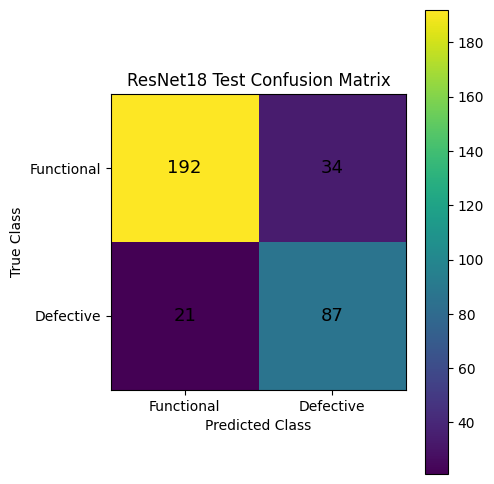

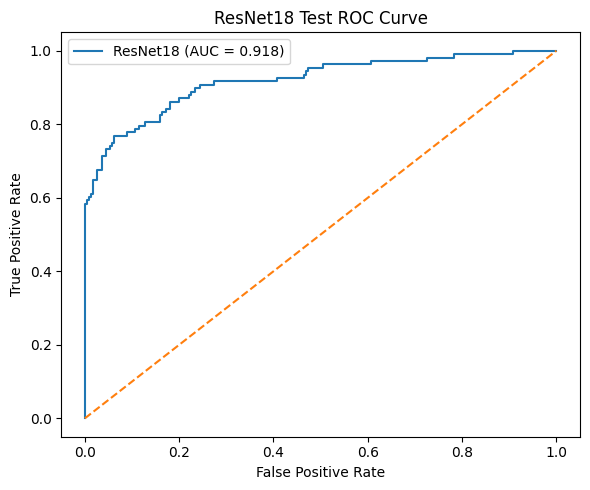

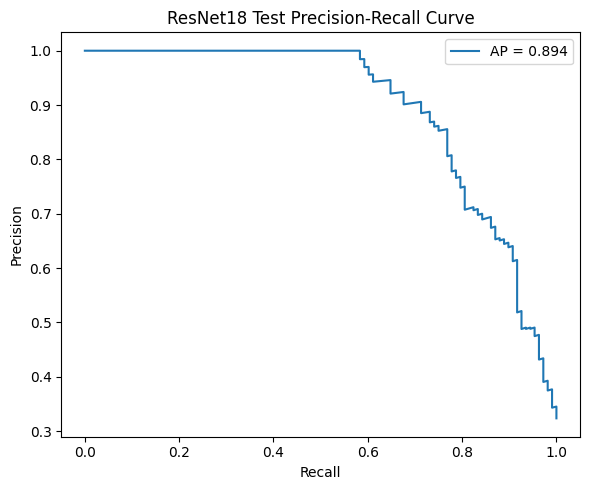


=== CELL 10 SUMMARY ===
Test images        : 334
Locked threshold   : 0.2609
Accuracy           : 0.8353
Precision          : 0.7190
Recall/Sensitivity : 0.8056
Specificity        : 0.8496
F1                 : 0.7598
Balanced Accuracy  : 0.8276
ROC-AUC            : 0.9182
Average Precision  : 0.8937
Confusion matrix   : TN=192, FP=34, FN=21, TP=87
Errors             : 55/334
Metrics saved      : /content/elpv-dataset/outputs/tables/resnet18_test_metrics.csv
Predictions saved  : /content/elpv-dataset/outputs/tables/resnet18_test_predictions.csv
Figures saved      : /content/elpv-dataset/outputs/figures


In [14]:
# CELL 10: Final evaluation on untouched TEST set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

# -------------------------------------------------
# Load best trained ResNet18
# -------------------------------------------------

resnet_model.load_state_dict(
    torch.load(RESNET_MODEL_PATH, map_location=device)
)

resnet_model.eval()

# Locked threshold selected from VALIDATION only
LOCKED_THRESHOLD = BEST_RESNET_THRESHOLD

test_true, test_prob = [], []

with torch.no_grad():

    for xb, yb in resnet_test_loader:

        xb = xb.to(device)

        logits = resnet_model(xb).squeeze(1)
        probs = torch.sigmoid(logits)

        test_true.extend(
            yb.numpy().astype(int)
        )

        test_prob.extend(
            probs.cpu().numpy()
        )

test_true = np.array(test_true)
test_prob = np.array(test_prob)

test_pred = (
    test_prob >= LOCKED_THRESHOLD
).astype(int)


# -------------------------------------------------
# Main metrics
# -------------------------------------------------

accuracy = accuracy_score(
    test_true, test_pred
)

precision = precision_score(
    test_true, test_pred,
    zero_division=0
)

recall = recall_score(
    test_true, test_pred,
    zero_division=0
)

f1 = f1_score(
    test_true, test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    test_true, test_prob
)

average_precision = average_precision_score(
    test_true, test_prob
)

balanced_acc = balanced_accuracy_score(
    test_true, test_pred
)

cm = confusion_matrix(
    test_true, test_pred
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)


# -------------------------------------------------
# Save metrics
# -------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall_Sensitivity",
        "Specificity",
        "F1",
        "Balanced_Accuracy",
        "ROC_AUC",
        "Average_Precision",
        "Locked_Threshold"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        balanced_acc,
        roc_auc,
        average_precision,
        LOCKED_THRESHOLD
    ]
})

metrics_df.to_csv(
    TAB_DIR / "resnet18_test_metrics.csv",
    index=False
)


# Save individual predictions
prediction_df = test_df[
    ["filename", "filepath",
     "label", "class_name", "cell_type"]
].copy().reset_index(drop=True)

prediction_df["Defective_Probability"] = test_prob
prediction_df["Predicted_Label"] = test_pred

prediction_df["Predicted_Class"] = (
    prediction_df["Predicted_Label"]
    .map({
        0: "Functional",
        1: "Defective"
    })
)

prediction_df["Correct"] = (
    prediction_df["label"] ==
    prediction_df["Predicted_Label"]
)

prediction_df.to_csv(
    TAB_DIR / "resnet18_test_predictions.csv",
    index=False
)


# -------------------------------------------------
# FIGURE 1 — Confusion Matrix
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(cm)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=13
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Functional",
    "Defective"
])

ax.set_yticklabels([
    "Functional",
    "Defective"
])

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_title(
    "ResNet18 Test Confusion Matrix"
)

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------
# FIGURE 2 — ROC Curve
# -------------------------------------------------

fpr, tpr, _ = roc_curve(
    test_true,
    test_prob
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet18 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ResNet18 Test ROC Curve"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_test_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------
# FIGURE 3 — Precision-Recall Curve
# -------------------------------------------------

pr_precision, pr_recall, _ = (
    precision_recall_curve(
        test_true,
        test_prob
    )
)

plt.figure(figsize=(6, 5))

plt.plot(
    pr_recall,
    pr_precision,
    label=f"AP = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "ResNet18 Test Precision-Recall Curve"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_test_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------
# Summary
# -------------------------------------------------

print("\n=== CELL 10 SUMMARY ===")

print(f"Test images        : {len(test_true)}")
print(f"Locked threshold   : {LOCKED_THRESHOLD:.4f}")

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall/Sensitivity : {recall:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"F1                 : {f1:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Average Precision  : {average_precision:.4f}")

print(
    f"Confusion matrix   : "
    f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
)

print(
    f"Errors             : "
    f"{fp + fn}/{len(test_true)}"
)

print(
    f"Metrics saved      : "
    f"{TAB_DIR/'resnet18_test_metrics.csv'}"
)

print(
    f"Predictions saved  : "
    f"{TAB_DIR/'resnet18_test_predictions.csv'}"
)

print(
    f"Figures saved      : {FIG_DIR}"
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]


=== STAGE 1: EFFICIENTNET CLASSIFIER WARM-UP ===
Epoch 01 | Train Acc 0.7044 | Val Acc 0.7387 | Val F1 0.6133 | Val AUC 0.7395
Epoch 02 | Train Acc 0.7590 | Val Acc 0.7357 | Val F1 0.6174 | Val AUC 0.7880
Epoch 03 | Train Acc 0.7828 | Val Acc 0.7598 | Val F1 0.6330 | Val AUC 0.7942
Epoch 04 | Train Acc 0.7898 | Val Acc 0.7598 | Val F1 0.6226 | Val AUC 0.8056
Epoch 05 | Train Acc 0.7982 | Val Acc 0.7748 | Val F1 0.6544 | Val AUC 0.8195

=== STAGE 2: EFFICIENTNET FINE-TUNING ===
Epoch 06 | Train Acc 0.7905 | Val Acc 0.7748 | Val F1 0.6411 | Val AUC 0.8427 | LR 0.000100
Epoch 07 | Train Acc 0.8252 | Val Acc 0.8018 | Val F1 0.6944 | Val AUC 0.8620 | LR 0.000100
Epoch 08 | Train Acc 0.8419 | Val Acc 0.8108 | Val F1 0.7070 | Val AUC 0.8690 | LR 0.000100
Epoch 09 | Train Acc 0.8316 | Val Acc 0.8168 | Val F1 0.7136 | Val AUC 0.8766 | LR 0.000100
Epoch 10 | Train Acc 0.8387 | Val Acc 0.8168 | Val F1 0.7081 | Val AUC 0.8821 | LR 0.000100
Epoch 11 | Train Acc 0.8618 | Val Acc 0.8168 | Val F1 0.71

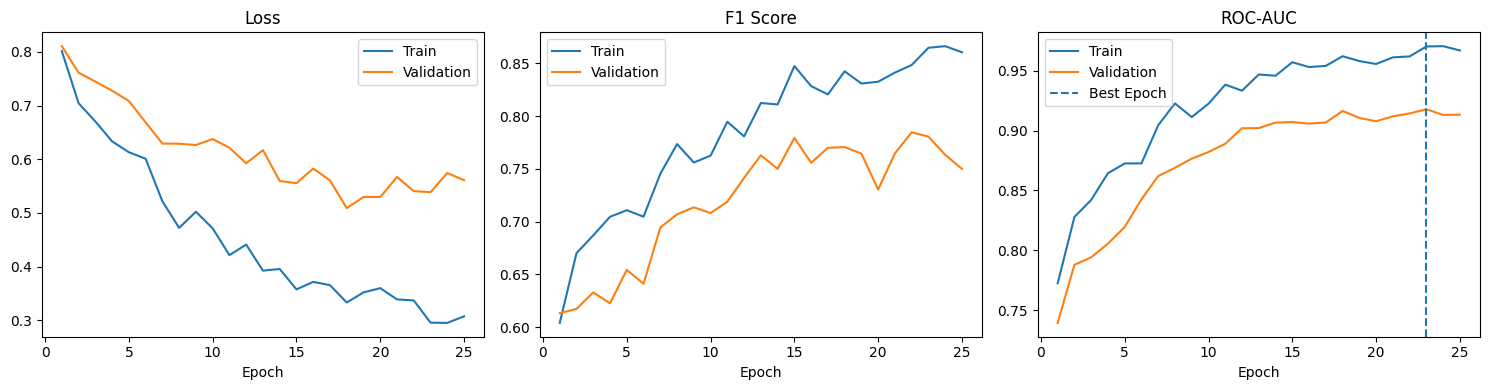


=== CELL 11 SUMMARY ===
Model              : EfficientNet-B0
Total epochs       : 25
Best epoch         : 23
Best stage         : Fine-tune
Best val accuracy  : 0.8649
Best val F1        : 0.7805
Best val ROC-AUC   : 0.9177
Best val loss      : 0.5387
Total parameters   : 4,008,829
Trainable Stage 2  : 3,157,021
Training time      : 5.76 minutes
Best model saved   : /content/elpv-dataset/outputs/models/best_efficientnet_b0_elpv.pt
History saved      : /content/elpv-dataset/outputs/tables/efficientnet_b0_training_history.csv


In [15]:
# CELL 11: EfficientNet-B0 transfer learning + fine-tuning

import time, copy, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)
from sklearn.metrics import f1_score, roc_auc_score

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# --------------------------------------------------
# Model
# --------------------------------------------------

eff_weights = EfficientNet_B0_Weights.IMAGENET1K_V1

eff_model = efficientnet_b0(
    weights=eff_weights
)

# Replace 1000-class classifier with binary output
in_features = eff_model.classifier[1].in_features

eff_model.classifier = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, 1)
)

eff_model = eff_model.to(device)


# Same weighted loss
eff_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)


# --------------------------------------------------
# Helper
# --------------------------------------------------

def eff_run_epoch(loader, training, optimizer=None):

    if training:
        eff_model.train()
    else:
        eff_model.eval()

    total_loss = 0
    true_all, prob_all = [], []

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device).float()

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            logits = eff_model(xb).squeeze(1)

            loss = eff_criterion(
                logits, yb
            )

            if training:
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)

        total_loss += (
            loss.item() * xb.size(0)
        )

        true_all.extend(
            yb.detach().cpu().numpy().astype(int)
        )

        prob_all.extend(
            probs.detach().cpu().numpy()
        )

    true_all = np.array(true_all)
    prob_all = np.array(prob_all)

    pred_all = (
        prob_all >= 0.50
    ).astype(int)

    return (
        total_loss / len(loader.dataset),

        np.mean(
            pred_all == true_all
        ),

        f1_score(
            true_all,
            pred_all,
            zero_division=0
        ),

        roc_auc_score(
            true_all,
            prob_all
        )
    )


# ==================================================
# STAGE 1 — CLASSIFIER WARM-UP
# ==================================================

for p in eff_model.parameters():
    p.requires_grad = False

for p in eff_model.classifier.parameters():
    p.requires_grad = True


eff_optimizer = torch.optim.AdamW(
    eff_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

history = []

best_auc = -1
best_state = None
best_epoch = 0
global_epoch = 0

STAGE1_EPOCHS = 5

start = time.time()

print("=== STAGE 1: EFFICIENTNET CLASSIFIER WARM-UP ===")

for epoch in range(STAGE1_EPOCHS):

    global_epoch += 1

    tr = eff_run_epoch(
        resnet_train_loader,
        True,
        eff_optimizer
    )

    va = eff_run_epoch(
        resnet_val_loader,
        False
    )

    history.append([
        global_epoch,
        "Warm-up",
        *tr,
        *va,
        eff_optimizer.param_groups[0]["lr"]
    ])

    print(
        f"Epoch {global_epoch:02d} | "
        f"Train Acc {tr[1]:.4f} | "
        f"Val Acc {va[1]:.4f} | "
        f"Val F1 {va[2]:.4f} | "
        f"Val AUC {va[3]:.4f}"
    )

    if va[3] > best_auc:

        best_auc = va[3]
        best_epoch = global_epoch

        best_state = copy.deepcopy(
            eff_model.state_dict()
        )


# ==================================================
# STAGE 2 — FINE-TUNE LAST FEATURE STAGES
# ==================================================

for p in eff_model.parameters():
    p.requires_grad = False

# Fine-tune later EfficientNet feature stages
for block in eff_model.features[6:]:
    for p in block.parameters():
        p.requires_grad = True

for p in eff_model.classifier.parameters():
    p.requires_grad = True


fine_optimizer = torch.optim.AdamW(
    [
        {
            "params": eff_model.features[6:].parameters(),
            "lr": 1e-4
        },
        {
            "params": eff_model.classifier.parameters(),
            "lr": 3e-4
        }
    ],
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    fine_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


STAGE2_EPOCHS = 20
PATIENCE = 5
wait = 0


print("\n=== STAGE 2: EFFICIENTNET FINE-TUNING ===")

for epoch in range(STAGE2_EPOCHS):

    global_epoch += 1

    tr = eff_run_epoch(
        resnet_train_loader,
        True,
        fine_optimizer
    )

    va = eff_run_epoch(
        resnet_val_loader,
        False
    )

    lr = fine_optimizer.param_groups[0]["lr"]

    history.append([
        global_epoch,
        "Fine-tune",
        *tr,
        *va,
        lr
    ])

    print(
        f"Epoch {global_epoch:02d} | "
        f"Train Acc {tr[1]:.4f} | "
        f"Val Acc {va[1]:.4f} | "
        f"Val F1 {va[2]:.4f} | "
        f"Val AUC {va[3]:.4f} | "
        f"LR {lr:.6f}"
    )

    scheduler.step(va[3])

    if va[3] > best_auc + 1e-4:

        best_auc = va[3]
        best_epoch = global_epoch

        best_state = copy.deepcopy(
            eff_model.state_dict()
        )

        wait = 0

    else:
        wait += 1

    if wait >= PATIENCE:

        print(
            f"\nEarly stopping at epoch "
            f"{global_epoch}."
        )

        break


# --------------------------------------------------
# Restore best checkpoint
# --------------------------------------------------

eff_model.load_state_dict(best_state)

EFF_MODEL_PATH = (
    MODEL_DIR / "best_efficientnet_b0_elpv.pt"
)

torch.save(
    best_state,
    EFF_MODEL_PATH
)


# --------------------------------------------------
# History table
# --------------------------------------------------

eff_history = pd.DataFrame(
    history,
    columns=[
        "Epoch",
        "Stage",

        "Train_Loss",
        "Train_Accuracy",
        "Train_F1",
        "Train_AUC",

        "Val_Loss",
        "Val_Accuracy",
        "Val_F1",
        "Val_AUC",

        "Learning_Rate"
    ]
)

eff_history.to_csv(
    TAB_DIR /
    "efficientnet_b0_training_history.csv",
    index=False
)


# --------------------------------------------------
# Training curves
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(15,4)
)

axes[0].plot(
    eff_history.Epoch,
    eff_history.Train_Loss,
    label="Train"
)

axes[0].plot(
    eff_history.Epoch,
    eff_history.Val_Loss,
    label="Validation"
)

axes[0].set_title("Loss")
axes[0].legend()


axes[1].plot(
    eff_history.Epoch,
    eff_history.Train_F1,
    label="Train"
)

axes[1].plot(
    eff_history.Epoch,
    eff_history.Val_F1,
    label="Validation"
)

axes[1].set_title("F1 Score")
axes[1].legend()


axes[2].plot(
    eff_history.Epoch,
    eff_history.Train_AUC,
    label="Train"
)

axes[2].plot(
    eff_history.Epoch,
    eff_history.Val_AUC,
    label="Validation"
)

axes[2].axvline(
    best_epoch,
    linestyle="--",
    label="Best Epoch"
)

axes[2].set_title("ROC-AUC")
axes[2].legend()


for ax in axes:
    ax.set_xlabel("Epoch")

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "efficientnet_b0_training_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Summary
# --------------------------------------------------

best_row = eff_history[
    eff_history.Epoch == best_epoch
].iloc[0]

total_params = sum(
    p.numel()
    for p in eff_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in eff_model.parameters()
    if p.requires_grad
)

elapsed = time.time() - start


pd.DataFrame([{
    "Model": "EfficientNet-B0",
    "Total_Parameters": total_params,
    "Trainable_Stage2": trainable_params,
    "Best_Epoch": best_epoch,
    "Best_Val_Accuracy":
        best_row.Val_Accuracy,
    "Best_Val_F1":
        best_row.Val_F1,
    "Best_Val_AUC":
        best_row.Val_AUC
}]).to_csv(
    TAB_DIR /
    "efficientnet_b0_summary.csv",
    index=False
)


print("\n=== CELL 11 SUMMARY ===")

print(f"Model              : EfficientNet-B0")
print(f"Total epochs       : {len(eff_history)}")
print(f"Best epoch         : {best_epoch}")
print(f"Best stage         : {best_row.Stage}")

print(
    f"Best val accuracy  : "
    f"{best_row.Val_Accuracy:.4f}"
)

print(
    f"Best val F1        : "
    f"{best_row.Val_F1:.4f}"
)

print(
    f"Best val ROC-AUC   : "
    f"{best_row.Val_AUC:.4f}"
)

print(
    f"Best val loss      : "
    f"{best_row.Val_Loss:.4f}"
)

print(
    f"Total parameters   : "
    f"{total_params:,}"
)

print(
    f"Trainable Stage 2  : "
    f"{trainable_params:,}"
)

print(
    f"Training time      : "
    f"{elapsed/60:.2f} minutes"
)

print(
    f"Best model saved   : "
    f"{EFF_MODEL_PATH}"
)

print(
    f"History saved      : "
    f"{TAB_DIR/'efficientnet_b0_training_history.csv'}"
)

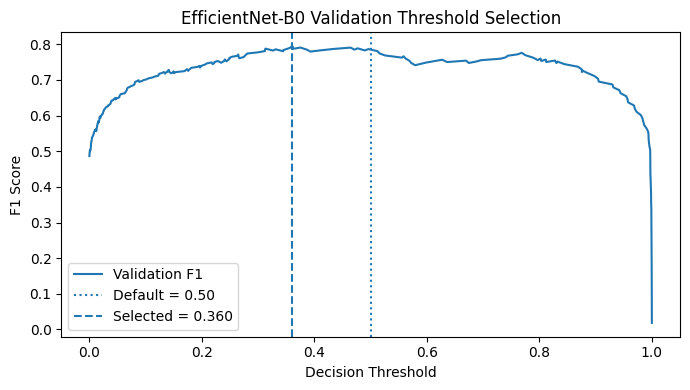


=== CELL 12 SUMMARY ===
Validation ROC-AUC       : 0.9177
Validation Average Prec. : 0.8892

Threshold = 0.50
Accuracy                 : 0.8649
Precision                : 0.8163
Recall                   : 0.7477
F1                       : 0.7805
Confusion matrix         : [[208, 18], [27, 80]]

Validation-selected threshold
Threshold                : 0.3600
Accuracy                 : 0.8649
Precision                : 0.7768
Recall                   : 0.8131
F1                       : 0.7945
Confusion matrix         : [[201, 25], [20, 87]]

Threshold saved          : /content/elpv-dataset/outputs/tables/efficientnet_locked_threshold.csv
Figure saved             : /content/elpv-dataset/outputs/figures/efficientnet_threshold_selection.png


In [16]:
# CELL 12: Validation-only threshold selection for EfficientNet-B0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)

# Load best EfficientNet checkpoint
eff_model.load_state_dict(
    torch.load(EFF_MODEL_PATH, map_location=device)
)
eff_model.eval()

val_true, val_prob = [], []

with torch.no_grad():
    for xb, yb in resnet_val_loader:   # same validation preprocessing
        xb = xb.to(device)

        logits = eff_model(xb).squeeze(1)
        probs = torch.sigmoid(logits)

        val_true.extend(yb.numpy().astype(int))
        val_prob.extend(probs.cpu().numpy())

val_true = np.array(val_true)
val_prob = np.array(val_prob)

# Discrimination metrics
roc_auc = roc_auc_score(val_true, val_prob)
ap = average_precision_score(val_true, val_prob)

# -------------------------------------------------
# Default threshold = 0.50
# -------------------------------------------------

pred_05 = (val_prob >= 0.50).astype(int)

acc_05 = accuracy_score(val_true, pred_05)
prec_05 = precision_score(val_true, pred_05, zero_division=0)
rec_05 = recall_score(val_true, pred_05, zero_division=0)
f1_05 = f1_score(val_true, pred_05, zero_division=0)

# -------------------------------------------------
# Validation-only threshold search
# -------------------------------------------------

precision, recall, thresholds = precision_recall_curve(
    val_true, val_prob
)

f1_values = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-12)
)

best_idx = np.argmax(f1_values)

BEST_EFF_THRESHOLD = float(
    thresholds[best_idx]
)

pred_best = (
    val_prob >= BEST_EFF_THRESHOLD
).astype(int)

acc_best = accuracy_score(val_true, pred_best)
prec_best = precision_score(val_true, pred_best, zero_division=0)
rec_best = recall_score(val_true, pred_best, zero_division=0)
f1_best = f1_score(val_true, pred_best, zero_division=0)

cm05 = confusion_matrix(val_true, pred_05)
cmbest = confusion_matrix(val_true, pred_best)

# -------------------------------------------------
# Save tables
# -------------------------------------------------

threshold_df = pd.DataFrame([
    [
        "Default", 0.50,
        acc_05, prec_05, rec_05, f1_05,
        roc_auc, ap
    ],
    [
        "Validation_Selected", BEST_EFF_THRESHOLD,
        acc_best, prec_best, rec_best, f1_best,
        roc_auc, ap
    ]
], columns=[
    "Method", "Threshold",
    "Accuracy", "Precision", "Recall", "F1",
    "ROC_AUC", "Average_Precision"
])

threshold_df.to_csv(
    TAB_DIR / "efficientnet_validation_threshold.csv",
    index=False
)

pd.DataFrame({
    "Model": ["EfficientNet-B0"],
    "Selected_Threshold": [BEST_EFF_THRESHOLD],
    "Selection_Data": ["Validation only"],
    "Selection_Metric": ["F1"]
}).to_csv(
    TAB_DIR / "efficientnet_locked_threshold.csv",
    index=False
)

# -------------------------------------------------
# Figure
# -------------------------------------------------

plt.figure(figsize=(7,4))

plt.plot(
    thresholds,
    f1_values,
    label="Validation F1"
)

plt.axvline(
    0.50,
    linestyle=":",
    label="Default = 0.50"
)

plt.axvline(
    BEST_EFF_THRESHOLD,
    linestyle="--",
    label=f"Selected = {BEST_EFF_THRESHOLD:.3f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("EfficientNet-B0 Validation Threshold Selection")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "efficientnet_threshold_selection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n=== CELL 12 SUMMARY ===")
print(f"Validation ROC-AUC       : {roc_auc:.4f}")
print(f"Validation Average Prec. : {ap:.4f}")

print("\nThreshold = 0.50")
print(f"Accuracy                 : {acc_05:.4f}")
print(f"Precision                : {prec_05:.4f}")
print(f"Recall                   : {rec_05:.4f}")
print(f"F1                       : {f1_05:.4f}")
print(f"Confusion matrix         : {cm05.tolist()}")

print("\nValidation-selected threshold")
print(f"Threshold                : {BEST_EFF_THRESHOLD:.4f}")
print(f"Accuracy                 : {acc_best:.4f}")
print(f"Precision                : {prec_best:.4f}")
print(f"Recall                   : {rec_best:.4f}")
print(f"F1                       : {f1_best:.4f}")
print(f"Confusion matrix         : {cmbest.tolist()}")

print(f"\nThreshold saved          : {TAB_DIR/'efficientnet_locked_threshold.csv'}")
print(f"Figure saved             : {FIG_DIR/'efficientnet_threshold_selection.png'}")

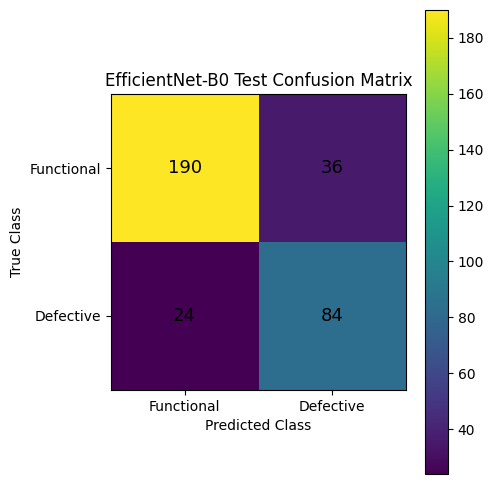

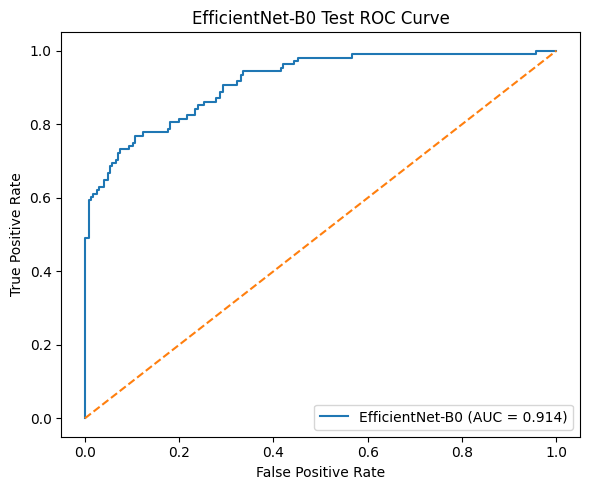

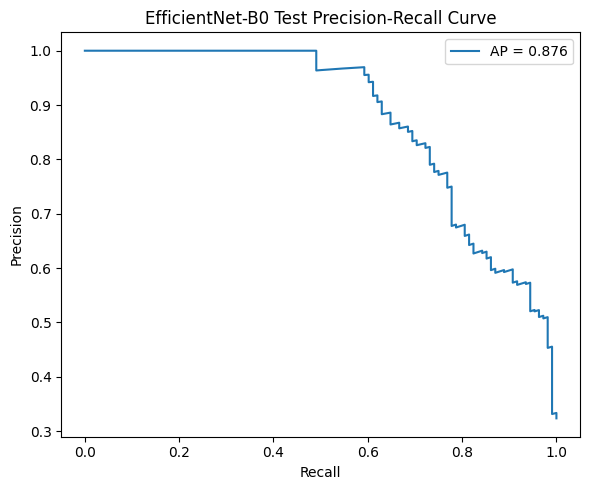


=== CELL 13 SUMMARY ===
Test images        : 334
Locked threshold   : 0.3600
Accuracy           : 0.8204
Precision          : 0.7000
Recall/Sensitivity : 0.7778
Specificity        : 0.8407
F1                 : 0.7368
Balanced Accuracy  : 0.8092
ROC-AUC            : 0.9142
Average Precision  : 0.8760
Confusion matrix   : TN=190, FP=36, FN=24, TP=84
Errors             : 60/334
Metrics saved      : /content/elpv-dataset/outputs/tables/efficientnet_test_metrics.csv
Predictions saved  : /content/elpv-dataset/outputs/tables/efficientnet_test_predictions.csv
Figures saved      : /content/elpv-dataset/outputs/figures


In [17]:
# CELL 13: Final EfficientNet-B0 evaluation on untouched TEST set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

# -------------------------------------------------
# Load best model
# -------------------------------------------------

eff_model.load_state_dict(
    torch.load(EFF_MODEL_PATH, map_location=device)
)

eff_model.eval()

LOCKED_EFF_THRESHOLD = BEST_EFF_THRESHOLD

test_true, test_prob = [], []

with torch.no_grad():

    for xb, yb in resnet_test_loader:

        xb = xb.to(device)

        logits = eff_model(xb).squeeze(1)
        probs = torch.sigmoid(logits)

        test_true.extend(
            yb.numpy().astype(int)
        )

        test_prob.extend(
            probs.cpu().numpy()
        )

test_true = np.array(test_true)
test_prob = np.array(test_prob)

test_pred = (
    test_prob >= LOCKED_EFF_THRESHOLD
).astype(int)


# -------------------------------------------------
# Metrics
# -------------------------------------------------

accuracy = accuracy_score(
    test_true, test_pred
)

precision = precision_score(
    test_true, test_pred,
    zero_division=0
)

recall = recall_score(
    test_true, test_pred,
    zero_division=0
)

f1 = f1_score(
    test_true, test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    test_true, test_prob
)

average_precision = average_precision_score(
    test_true, test_prob
)

balanced_acc = balanced_accuracy_score(
    test_true, test_pred
)

cm = confusion_matrix(
    test_true, test_pred
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)


# -------------------------------------------------
# Save metrics
# -------------------------------------------------

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall_Sensitivity",
        "Specificity",
        "F1",
        "Balanced_Accuracy",
        "ROC_AUC",
        "Average_Precision",
        "Locked_Threshold"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        balanced_acc,
        roc_auc,
        average_precision,
        LOCKED_EFF_THRESHOLD
    ]
})

metrics_df.to_csv(
    TAB_DIR / "efficientnet_test_metrics.csv",
    index=False
)


# Save predictions
prediction_df = test_df[
    [
        "filename",
        "filepath",
        "label",
        "class_name",
        "cell_type"
    ]
].copy().reset_index(drop=True)

prediction_df["Defective_Probability"] = test_prob
prediction_df["Predicted_Label"] = test_pred

prediction_df["Predicted_Class"] = (
    prediction_df["Predicted_Label"]
    .map({
        0: "Functional",
        1: "Defective"
    })
)

prediction_df["Correct"] = (
    prediction_df["label"] ==
    prediction_df["Predicted_Label"]
)

prediction_df.to_csv(
    TAB_DIR / "efficientnet_test_predictions.csv",
    index=False
)


# -------------------------------------------------
# FIGURE 1 — Confusion Matrix
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(cm)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            str(cm[i,j]),
            ha="center",
            va="center",
            fontsize=13
        )

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels([
    "Functional",
    "Defective"
])

ax.set_yticklabels([
    "Functional",
    "Defective"
])

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_title(
    "EfficientNet-B0 Test Confusion Matrix"
)

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "efficientnet_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------
# FIGURE 2 — ROC Curve
# -------------------------------------------------

fpr, tpr, _ = roc_curve(
    test_true,
    test_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"EfficientNet-B0 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "EfficientNet-B0 Test ROC Curve"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "efficientnet_test_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------
# FIGURE 3 — Precision-Recall Curve
# -------------------------------------------------

pr_precision, pr_recall, _ = (
    precision_recall_curve(
        test_true,
        test_prob
    )
)

plt.figure(figsize=(6,5))

plt.plot(
    pr_recall,
    pr_precision,
    label=f"AP = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "EfficientNet-B0 Test Precision-Recall Curve"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "efficientnet_test_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------
# Summary
# -------------------------------------------------

print("\n=== CELL 13 SUMMARY ===")

print(f"Test images        : {len(test_true)}")
print(f"Locked threshold   : {LOCKED_EFF_THRESHOLD:.4f}")

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall/Sensitivity : {recall:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"F1                 : {f1:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Average Precision  : {average_precision:.4f}")

print(
    f"Confusion matrix   : "
    f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
)

print(
    f"Errors             : "
    f"{fp + fn}/{len(test_true)}"
)

print(
    f"Metrics saved      : "
    f"{TAB_DIR/'efficientnet_test_metrics.csv'}"
)

print(
    f"Predictions saved  : "
    f"{TAB_DIR/'efficientnet_test_predictions.csv'}"
)

print(
    f"Figures saved      : {FIG_DIR}"
)

,Model,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,Average_Precision,Locked_Threshold,Parameters
0,Custom CNN,0.7784,0.6308,0.7593,0.7876,0.6891,0.7734,0.8462,0.7696,0.5274,389057
1,ResNet18,0.8353,0.7190,0.8056,0.8496,0.7598,0.8276,0.9182,0.8937,0.2609,11177025
2,EfficientNet-B0,0.8204,0.7000,0.7778,0.8407,0.7368,0.8092,0.9142,0.8760,0.3600,4008829


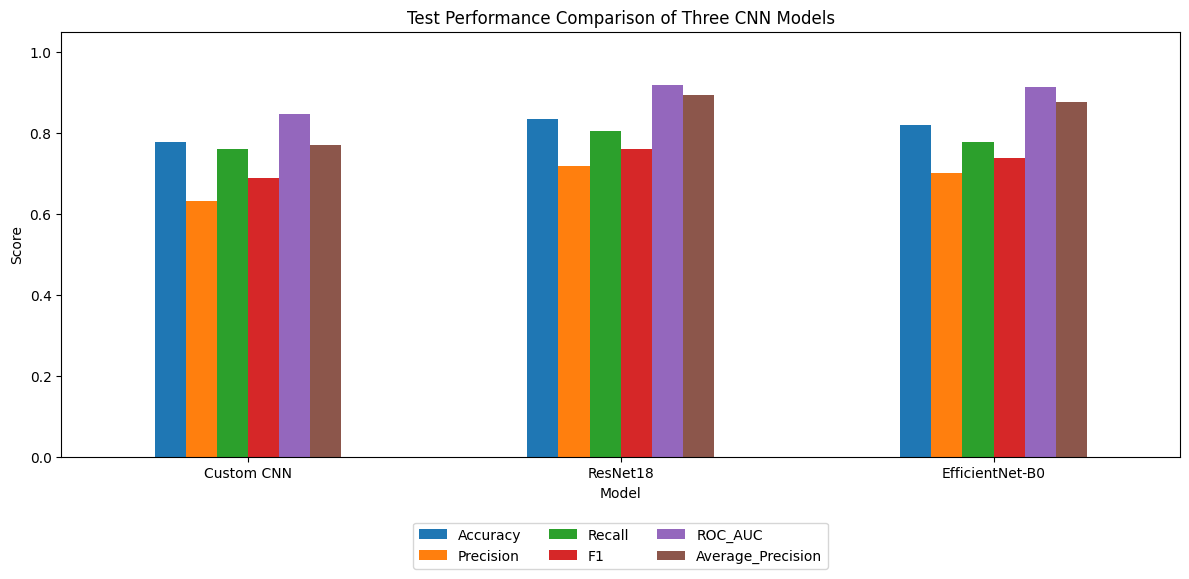

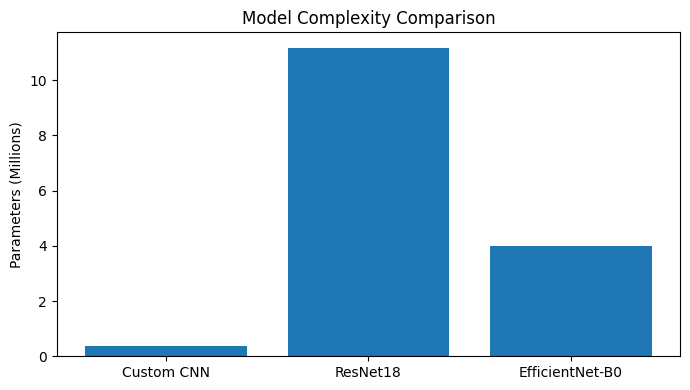


=== CELL 14 SUMMARY ===
CUSTOM CNN TEST
Threshold          : 0.5274
Accuracy           : 0.7784
Precision          : 0.6308
Recall             : 0.7593
F1                 : 0.6891
ROC-AUC            : 0.8462
Average Precision  : 0.7696
Confusion matrix   : TN=178, FP=48, FN=26, TP=82

THREE-MODEL COMPARISON
Best test F1       : ResNet18
Best test ROC-AUC  : ResNet18
Smallest model     : Custom CNN
Comparison saved   : /content/elpv-dataset/outputs/tables/three_model_test_comparison.csv
Figures saved      : /content/elpv-dataset/outputs/figures/three_model_performance_comparison.png


In [18]:
# CELL 14: Custom CNN final test + three-model comparison

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

# =====================================================
# 1. Load custom CNN best checkpoint
# =====================================================

model.load_state_dict(
    torch.load(BEST_MODEL, map_location=device)
)
model.eval()

# Read its validation-selected threshold safely
baseline_diag = pd.read_csv(
    TAB_DIR / "baseline_validation_diagnostic.csv"
)

CUSTOM_THRESHOLD = float(
    baseline_diag.loc[
        baseline_diag["Method"] == "Validation_Selected",
        "Threshold"
    ].iloc[0]
)

custom_true, custom_prob = [], []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        custom_true.extend(
            yb.numpy().astype(int)
        )

        custom_prob.extend(
            probs.cpu().numpy()
        )

custom_true = np.array(custom_true)
custom_prob = np.array(custom_prob)

custom_pred = (
    custom_prob >= CUSTOM_THRESHOLD
).astype(int)

# =====================================================
# 2. Custom CNN test metrics
# =====================================================

c_acc = accuracy_score(custom_true, custom_pred)
c_prec = precision_score(custom_true, custom_pred, zero_division=0)
c_rec = recall_score(custom_true, custom_pred, zero_division=0)
c_f1 = f1_score(custom_true, custom_pred, zero_division=0)
c_auc = roc_auc_score(custom_true, custom_prob)
c_ap = average_precision_score(custom_true, custom_prob)
c_bal = balanced_accuracy_score(custom_true, custom_pred)

c_cm = confusion_matrix(custom_true, custom_pred)
c_tn, c_fp, c_fn, c_tp = c_cm.ravel()

c_spec = c_tn / (c_tn + c_fp)

custom_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall_Sensitivity",
        "Specificity", "F1", "Balanced_Accuracy",
        "ROC_AUC", "Average_Precision",
        "Locked_Threshold"
    ],
    "Value": [
        c_acc, c_prec, c_rec,
        c_spec, c_f1, c_bal,
        c_auc, c_ap,
        CUSTOM_THRESHOLD
    ]
})

custom_metrics.to_csv(
    TAB_DIR / "custom_cnn_test_metrics.csv",
    index=False
)

# =====================================================
# 3. Load ResNet18 + EfficientNet metrics
# =====================================================

def metric_dict(path):
    df = pd.read_csv(path)
    return dict(zip(df["Metric"], df["Value"]))

res = metric_dict(
    TAB_DIR / "resnet18_test_metrics.csv"
)

eff = metric_dict(
    TAB_DIR / "efficientnet_test_metrics.csv"
)

# =====================================================
# 4. Consolidated comparison table
# =====================================================

custom_params = sum(
    p.numel() for p in model.parameters()
)

resnet_params = sum(
    p.numel() for p in resnet_model.parameters()
)

eff_params = sum(
    p.numel() for p in eff_model.parameters()
)

comparison = pd.DataFrame([
    [
        "Custom CNN",
        c_acc, c_prec, c_rec, c_spec,
        c_f1, c_bal, c_auc, c_ap,
        CUSTOM_THRESHOLD, custom_params
    ],

    [
        "ResNet18",
        res["Accuracy"],
        res["Precision"],
        res["Recall_Sensitivity"],
        res["Specificity"],
        res["F1"],
        res["Balanced_Accuracy"],
        res["ROC_AUC"],
        res["Average_Precision"],
        res["Locked_Threshold"],
        resnet_params
    ],

    [
        "EfficientNet-B0",
        eff["Accuracy"],
        eff["Precision"],
        eff["Recall_Sensitivity"],
        eff["Specificity"],
        eff["F1"],
        eff["Balanced_Accuracy"],
        eff["ROC_AUC"],
        eff["Average_Precision"],
        eff["Locked_Threshold"],
        eff_params
    ]

], columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "Balanced_Accuracy",
    "ROC_AUC",
    "Average_Precision",
    "Locked_Threshold",
    "Parameters"
])

comparison.to_csv(
    TAB_DIR / "three_model_test_comparison.csv",
    index=False
)

display(comparison.round(4))

# =====================================================
# 5. Figure — predictive performance comparison
# =====================================================

plot_metrics = comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall",
     "F1", "ROC_AUC", "Average_Precision"]
]

ax = plot_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(
    "Test Performance Comparison of Three CNN Models"
)

plt.xticks(rotation=0)
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=3
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# 6. Figure — parameter efficiency
# =====================================================

plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Model"],
    comparison["Parameters"] / 1e6
)

plt.ylabel("Parameters (Millions)")
plt.title("Model Complexity Comparison")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_model_parameter_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Summary
# =====================================================

best_f1_model = comparison.loc[
    comparison["F1"].idxmax(), "Model"
]

best_auc_model = comparison.loc[
    comparison["ROC_AUC"].idxmax(), "Model"
]

smallest_model = comparison.loc[
    comparison["Parameters"].idxmin(), "Model"
]

print("\n=== CELL 14 SUMMARY ===")

print("CUSTOM CNN TEST")
print(f"Threshold          : {CUSTOM_THRESHOLD:.4f}")
print(f"Accuracy           : {c_acc:.4f}")
print(f"Precision          : {c_prec:.4f}")
print(f"Recall             : {c_rec:.4f}")
print(f"F1                 : {c_f1:.4f}")
print(f"ROC-AUC            : {c_auc:.4f}")
print(f"Average Precision  : {c_ap:.4f}")
print(
    f"Confusion matrix   : "
    f"TN={c_tn}, FP={c_fp}, FN={c_fn}, TP={c_tp}"
)

print("\nTHREE-MODEL COMPARISON")
print(f"Best test F1       : {best_f1_model}")
print(f"Best test ROC-AUC  : {best_auc_model}")
print(f"Smallest model     : {smallest_model}")

print(
    f"Comparison saved   : "
    f"{TAB_DIR/'three_model_test_comparison.csv'}"
)

print(
    f"Figures saved      : "
    f"{FIG_DIR/'three_model_performance_comparison.png'}"
)

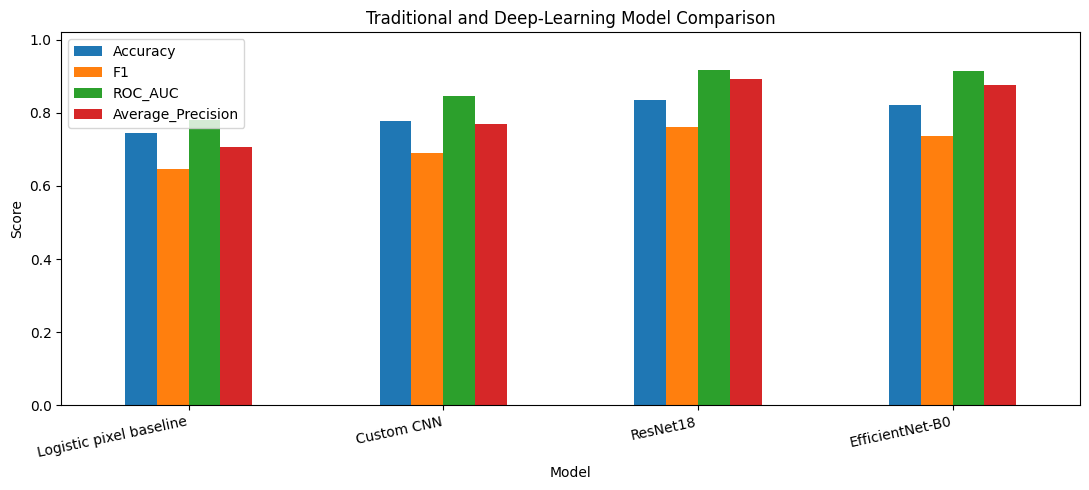

,Model,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,Average_Precision,Locked_Threshold,Parameters
0,Logistic pixel baseline,0.7455,0.5865,0.7222,0.7566,0.6473,0.7394,0.7800,0.7068,0.3300,1025
1,Custom CNN,0.7784,0.6308,0.7593,0.7876,0.6891,0.7734,0.8462,0.7696,0.5274,389057
2,ResNet18,0.8353,0.7190,0.8056,0.8496,0.7598,0.8276,0.9182,0.8937,0.2609,11177025
3,EfficientNet-B0,0.8204,0.7000,0.7778,0.8407,0.7368,0.8092,0.9142,0.8760,0.3600,4008829


In [19]:
# Four-model comparison including the traditional baseline
traditional_row={"Model":"Logistic pixel baseline",**{k:traditional_metrics[k] for k in ["Accuracy","Precision","Recall","Specificity","F1","Balanced_Accuracy","ROC_AUC","Average_Precision","Locked_Threshold"]},"Parameters":1025}
all_model_comparison_df=pd.concat([pd.DataFrame([traditional_row]),comparison],ignore_index=True)
all_model_comparison_df.to_csv(TAB_DIR/"all_model_test_comparison.csv",index=False)
ax=all_model_comparison_df.set_index("Model")[["Accuracy","F1","ROC_AUC","Average_Precision"]].plot(kind="bar",figsize=(11,5))
ax.set_ylim(0,1.02); ax.set_ylabel("Score"); ax.set_title("Traditional and Deep-Learning Model Comparison")
plt.xticks(rotation=12,ha="right"); plt.tight_layout(); plt.savefig(FIG_DIR/"all_model_performance_comparison.png",dpi=300,bbox_inches="tight"); plt.show()
display(all_model_comparison_df.round(4))


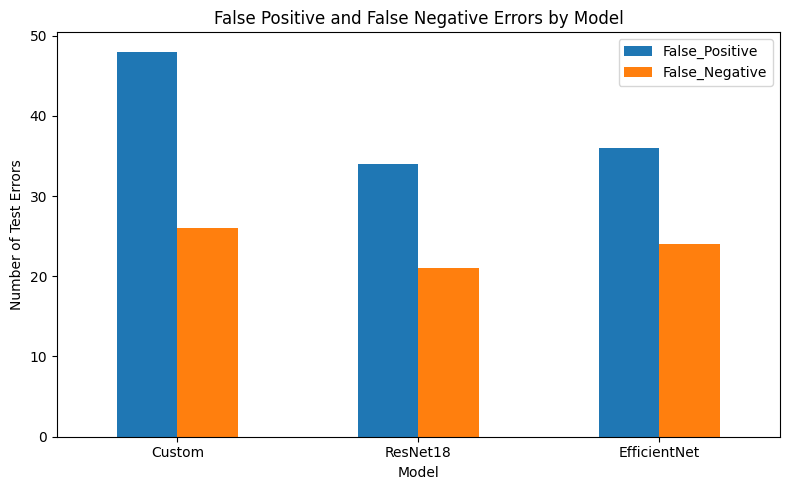

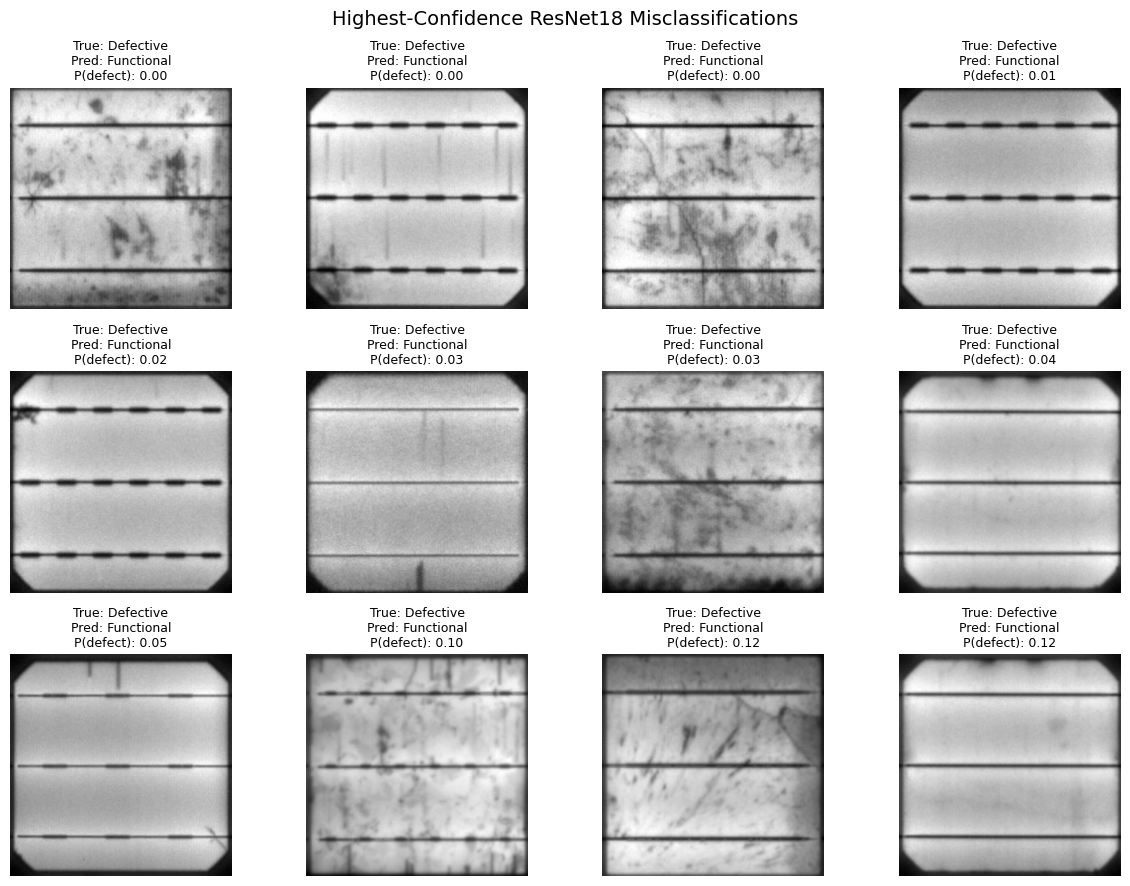


=== CELL 15 SUMMARY ===
ERROR COUNTS
Custom       : FP=48 | FN=26 | Total=74
ResNet18     : FP=34 | FN=21 | Total=55
EfficientNet : FP=36 | FN=24 | Total=60

ERROR AGREEMENT
All three correct        : 222
All three wrong          : 22
Hard cases (>=2 wrong)   : 55
Only ResNet18 wrong      : 9

PRIMARY MODEL — RESNET18
Misclassified samples    : 55
False positives          : 34
False negatives          : 21
Error table saved        : /content/elpv-dataset/outputs/tables/resnet18_misclassified_samples.csv
Shared cases saved       : /content/elpv-dataset/outputs/tables/shared_hard_cases.csv
Figures saved            : /content/elpv-dataset/outputs/figures


In [20]:
# CELL 15: Error analysis across all three models + ResNet18 error examples

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =====================================================
# 1. Recreate Custom CNN test predictions
# =====================================================

model.load_state_dict(
    torch.load(BEST_MODEL, map_location=device)
)
model.eval()

custom_true, custom_prob = [], []

with torch.no_grad():
    for xb, yb in test_loader:

        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        custom_true.extend(
            yb.numpy().astype(int)
        )

        custom_prob.extend(
            probs.cpu().numpy()
        )

custom_true = np.array(custom_true)
custom_prob = np.array(custom_prob)

custom_pred = (
    custom_prob >= CUSTOM_THRESHOLD
).astype(int)


# =====================================================
# 2. Load ResNet18 and EfficientNet predictions
# =====================================================

res_pred_df = pd.read_csv(
    TAB_DIR / "resnet18_test_predictions.csv"
)

eff_pred_df = pd.read_csv(
    TAB_DIR / "efficientnet_test_predictions.csv"
)

base_test = test_df[
    ["filename", "filepath", "label", "class_name", "cell_type"]
].copy().reset_index(drop=True)


# Add Custom CNN predictions
base_test["Custom_Probability"] = custom_prob
base_test["Custom_Prediction"] = custom_pred


# Add ResNet18 predictions by filename
res_map_prob = dict(zip(
    res_pred_df["filename"],
    res_pred_df["Defective_Probability"]
))

res_map_pred = dict(zip(
    res_pred_df["filename"],
    res_pred_df["Predicted_Label"]
))

base_test["ResNet18_Probability"] = (
    base_test["filename"].map(res_map_prob)
)

base_test["ResNet18_Prediction"] = (
    base_test["filename"].map(res_map_pred)
)


# Add EfficientNet predictions
eff_map_prob = dict(zip(
    eff_pred_df["filename"],
    eff_pred_df["Defective_Probability"]
))

eff_map_pred = dict(zip(
    eff_pred_df["filename"],
    eff_pred_df["Predicted_Label"]
))

base_test["EfficientNet_Probability"] = (
    base_test["filename"].map(eff_map_prob)
)

base_test["EfficientNet_Prediction"] = (
    base_test["filename"].map(eff_map_pred)
)


# =====================================================
# 3. Error indicators
# =====================================================

models = [
    "Custom",
    "ResNet18",
    "EfficientNet"
]

for m in models:

    base_test[f"{m}_Error"] = (
        base_test[f"{m}_Prediction"] !=
        base_test["label"]
    )

base_test["Error_Count"] = (
    base_test[
        [
            "Custom_Error",
            "ResNet18_Error",
            "EfficientNet_Error"
        ]
    ].sum(axis=1)
)


# =====================================================
# 4. FP/FN counts for each model
# =====================================================

error_rows = []

for m in models:

    pred = base_test[
        f"{m}_Prediction"
    ].astype(int)

    true = base_test["label"]

    fp = ((true == 0) & (pred == 1)).sum()
    fn = ((true == 1) & (pred == 0)).sum()

    error_rows.append([
        m,
        fp,
        fn,
        fp + fn
    ])

error_summary = pd.DataFrame(
    error_rows,
    columns=[
        "Model",
        "False_Positive",
        "False_Negative",
        "Total_Errors"
    ]
)

error_summary.to_csv(
    TAB_DIR / "three_model_error_summary.csv",
    index=False
)


# =====================================================
# 5. Agreement / shared-error analysis
# =====================================================

all_wrong = (
    (base_test["Custom_Error"]) &
    (base_test["ResNet18_Error"]) &
    (base_test["EfficientNet_Error"])
).sum()

all_correct = (
    (~base_test["Custom_Error"]) &
    (~base_test["ResNet18_Error"]) &
    (~base_test["EfficientNet_Error"])
).sum()

only_resnet_wrong = (
    base_test["ResNet18_Error"] &
    ~base_test["Custom_Error"] &
    ~base_test["EfficientNet_Error"]
).sum()

hard_cases = base_test[
    base_test["Error_Count"] >= 2
].copy()

hard_cases.to_csv(
    TAB_DIR / "shared_hard_cases.csv",
    index=False
)


# =====================================================
# 6. Primary-model ResNet18 misclassification table
# =====================================================

res_errors = base_test[
    base_test["ResNet18_Error"]
].copy()

res_errors["True_Class"] = (
    res_errors["label"]
    .map({
        0: "Functional",
        1: "Defective"
    })
)

res_errors["Predicted_Class"] = (
    res_errors["ResNet18_Prediction"]
    .map({
        0: "Functional",
        1: "Defective"
    })
)

res_errors["Confidence"] = np.where(
    res_errors["ResNet18_Prediction"] == 1,
    res_errors["ResNet18_Probability"],
    1 - res_errors["ResNet18_Probability"]
)

res_errors = res_errors.sort_values(
    "Confidence",
    ascending=False
)

res_errors.to_csv(
    TAB_DIR / "resnet18_misclassified_samples.csv",
    index=False
)


# =====================================================
# 7. Figure — FP and FN comparison
# =====================================================

ax = error_summary.set_index("Model")[
    ["False_Positive", "False_Negative"]
].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Number of Test Errors")
plt.title("False Positive and False Negative Errors by Model")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_model_error_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================
# 8. Figure — ResNet18 misclassified examples
# =====================================================

n_show = min(
    12,
    len(res_errors)
)

display_errors = res_errors.head(
    n_show
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(12,9)
)

axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, (_, r) in zip(
    axes,
    display_errors.iterrows()
):

    img = Image.open(
        r["filepath"]
    ).convert("L")

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(
        f"True: {r['True_Class']}\n"
        f"Pred: {r['Predicted_Class']}\n"
        f"P(defect): {r['ResNet18_Probability']:.2f}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Highest-Confidence ResNet18 Misclassifications",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_misclassified_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================
# 9. Save complete prediction/error table
# =====================================================

base_test.to_csv(
    TAB_DIR / "three_model_test_error_analysis.csv",
    index=False
)


# =====================================================
# Summary
# =====================================================

res_row = error_summary[
    error_summary["Model"] == "ResNet18"
].iloc[0]

print("\n=== CELL 15 SUMMARY ===")

print("ERROR COUNTS")
for _, r in error_summary.iterrows():
    print(
        f"{r.Model:<13}: "
        f"FP={r.False_Positive} | "
        f"FN={r.False_Negative} | "
        f"Total={r.Total_Errors}"
    )

print("\nERROR AGREEMENT")
print(f"All three correct        : {all_correct}")
print(f"All three wrong          : {all_wrong}")
print(f"Hard cases (>=2 wrong)   : {len(hard_cases)}")
print(f"Only ResNet18 wrong      : {only_resnet_wrong}")

print("\nPRIMARY MODEL — RESNET18")
print(f"Misclassified samples    : {len(res_errors)}")
print(f"False positives          : {res_row.False_Positive}")
print(f"False negatives          : {res_row.False_Negative}")

print(
    f"Error table saved        : "
    f"{TAB_DIR/'resnet18_misclassified_samples.csv'}"
)

print(
    f"Shared cases saved       : "
    f"{TAB_DIR/'shared_hard_cases.csv'}"
)

print(
    f"Figures saved            : {FIG_DIR}"
)

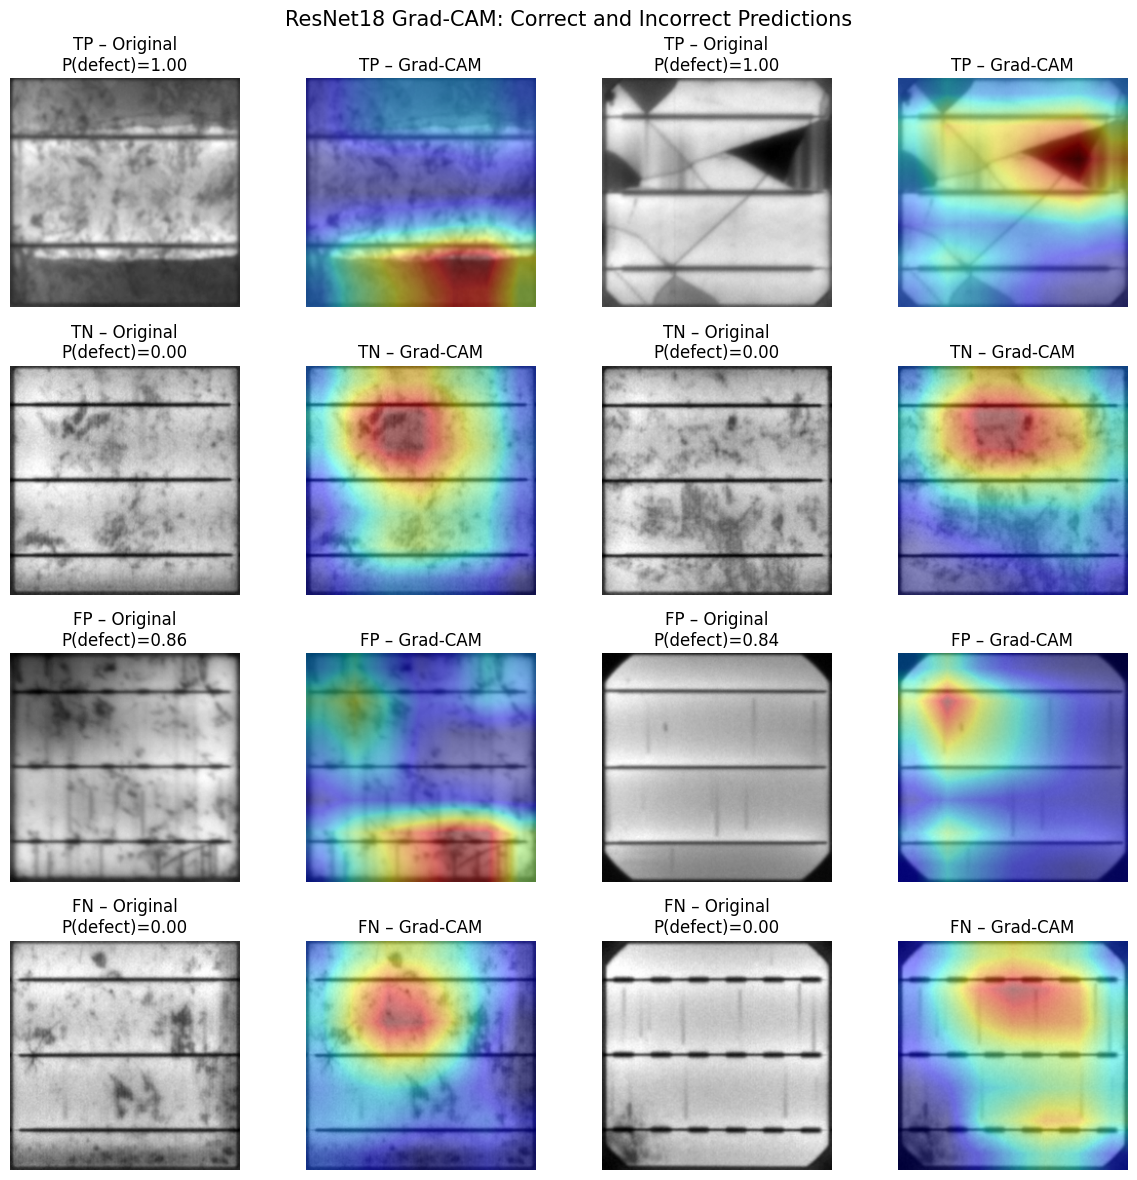


=== CELL 16 SUMMARY ===
Target layer       : layer4[-1].conv2
True Positives     : 87
True Negatives     : 192
False Positives    : 34
False Negatives    : 21
Grad-CAM examples  : 8
Figure saved       : /content/elpv-dataset/outputs/figures/resnet18_gradcam_tp_tn_fp_fn.png
Samples saved      : /content/elpv-dataset/outputs/tables/resnet18_gradcam_selected_samples.csv


In [21]:
# CELL 16: Grad-CAM for ResNet18 — TP, TN, FP and FN examples

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

# -------------------------------------------------------
# Load best primary model
# -------------------------------------------------------

resnet_model.load_state_dict(
    torch.load(RESNET_MODEL_PATH, map_location=device)
)
resnet_model.eval()

# Last convolutional layer of ResNet18
target_layer = resnet_model.layer4[-1].conv2

activations = {}
gradients = {}

def forward_hook(module, inp, out):
    activations["value"] = out

def backward_hook(module, grad_in, grad_out):
    gradients["value"] = grad_out[0]

handle_f = target_layer.register_forward_hook(forward_hook)
handle_b = target_layer.register_full_backward_hook(backward_hook)


# -------------------------------------------------------
# Grad-CAM function
# -------------------------------------------------------

def generate_gradcam(filepath):

    img = Image.open(filepath).convert("L")

    x = resnet_eval_tfms(img).unsqueeze(0).to(device)

    resnet_model.zero_grad()

    logit = resnet_model(x).squeeze()
    prob = torch.sigmoid(logit).item()

    pred = int(
        prob >= LOCKED_THRESHOLD
    )

    # Explain predicted class
    target_score = logit if pred == 1 else -logit

    target_score.backward()

    acts = activations["value"]
    grads = gradients["value"]

    weights = grads.mean(
        dim=(2,3),
        keepdim=True
    )

    cam = (
        weights * acts
    ).sum(dim=1, keepdim=True)

    cam = F.relu(cam)

    cam = F.interpolate(
        cam,
        size=(224,224),
        mode="bilinear",
        align_corners=False
    )

    cam = cam.squeeze().detach().cpu().numpy()

    if cam.max() > cam.min():
        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min()
        )

    display_img = np.array(
        img.resize((224,224)),
        dtype=np.float32
    ) / 255.0

    return display_img, cam, prob, pred


# -------------------------------------------------------
# Define TP / TN / FP / FN
# -------------------------------------------------------

gradcam_df = base_test.copy()

gradcam_df["Category"] = np.select(
    [
        (gradcam_df.label == 1) &
        (gradcam_df.ResNet18_Prediction == 1),

        (gradcam_df.label == 0) &
        (gradcam_df.ResNet18_Prediction == 0),

        (gradcam_df.label == 0) &
        (gradcam_df.ResNet18_Prediction == 1),

        (gradcam_df.label == 1) &
        (gradcam_df.ResNet18_Prediction == 0)
    ],
    ["TP", "TN", "FP", "FN"],
    default="Other"
)

gradcam_df["Confidence"] = np.where(
    gradcam_df["ResNet18_Prediction"] == 1,
    gradcam_df["ResNet18_Probability"],
    1 - gradcam_df["ResNet18_Probability"]
)


# -------------------------------------------------------
# Select 2 representative samples per category
# -------------------------------------------------------

selected = []

for category in ["TP", "TN", "FP", "FN"]:

    temp = gradcam_df[
        gradcam_df["Category"] == category
    ].sort_values(
        "Confidence",
        ascending=False
    ).head(2)

    selected.append(temp)

selected_df = pd.concat(
    selected,
    ignore_index=True
)

selected_df[
    [
        "filename",
        "label",
        "class_name",
        "ResNet18_Prediction",
        "ResNet18_Probability",
        "Confidence",
        "Category",
        "cell_type"
    ]
].to_csv(
    TAB_DIR / "resnet18_gradcam_selected_samples.csv",
    index=False
)


# -------------------------------------------------------
# Grad-CAM figure
# Each row = TP / TN / FP / FN
# Two examples per category
# -------------------------------------------------------

fig, axes = plt.subplots(
    4, 4,
    figsize=(12,12)
)

categories = ["TP", "TN", "FP", "FN"]

for row_idx, category in enumerate(categories):

    subset = selected_df[
        selected_df["Category"] == category
    ].reset_index(drop=True)

    for j in range(2):

        r = subset.iloc[j]

        original, cam, prob, pred = generate_gradcam(
            r["filepath"]
        )

        # Original image
        axes[row_idx, j*2].imshow(
            original,
            cmap="gray"
        )

        axes[row_idx, j*2].set_title(
            f"{category} – Original\n"
            f"P(defect)={prob:.2f}"
        )

        axes[row_idx, j*2].axis("off")

        # Grad-CAM overlay
        axes[row_idx, j*2+1].imshow(
            original,
            cmap="gray"
        )

        axes[row_idx, j*2+1].imshow(
            cam,
            cmap="jet",
            alpha=0.45
        )

        axes[row_idx, j*2+1].set_title(
            f"{category} – Grad-CAM"
        )

        axes[row_idx, j*2+1].axis("off")


plt.suptitle(
    "ResNet18 Grad-CAM: Correct and Incorrect Predictions",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_gradcam_tp_tn_fp_fn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Remove hooks
handle_f.remove()
handle_b.remove()


# -------------------------------------------------------
# Category counts
# -------------------------------------------------------

category_counts = (
    gradcam_df["Category"]
    .value_counts()
    .reindex(["TP","TN","FP","FN"])
)

pd.DataFrame({
    "Category": category_counts.index,
    "Count": category_counts.values
}).to_csv(
    TAB_DIR / "resnet18_prediction_categories.csv",
    index=False
)


print("\n=== CELL 16 SUMMARY ===")

print(f"Target layer       : layer4[-1].conv2")
print(f"True Positives     : {category_counts['TP']}")
print(f"True Negatives     : {category_counts['TN']}")
print(f"False Positives    : {category_counts['FP']}")
print(f"False Negatives    : {category_counts['FN']}")
print(f"Grad-CAM examples  : {len(selected_df)}")

print(
    f"Figure saved       : "
    f"{FIG_DIR/'resnet18_gradcam_tp_tn_fp_fn.png'}"
)

print(
    f"Samples saved      : "
    f"{TAB_DIR/'resnet18_gradcam_selected_samples.csv'}"
)

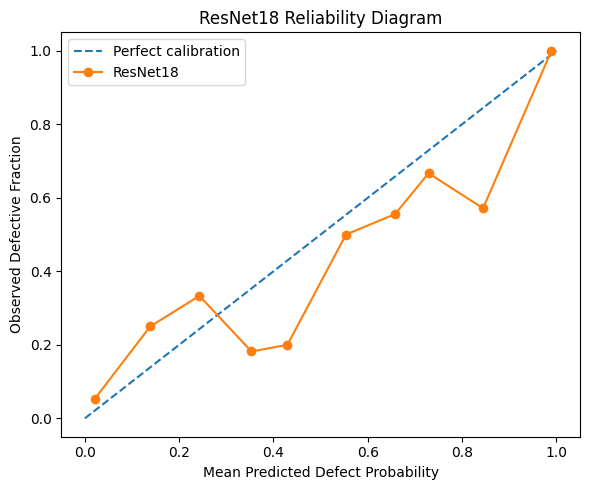

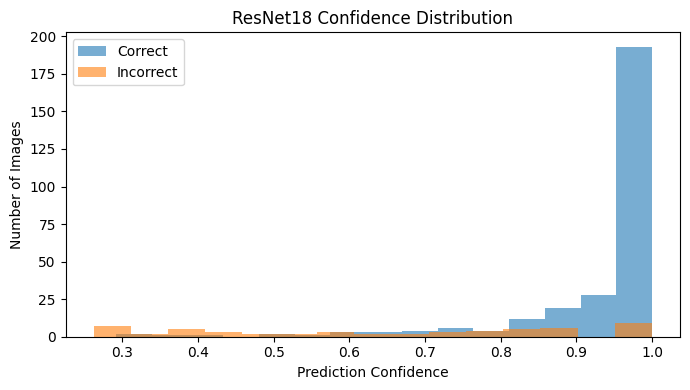

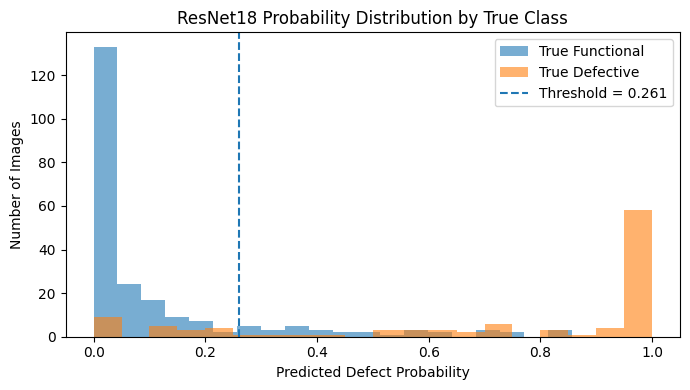


=== CELL 17 SUMMARY ===
Brier score              : 0.0944
Expected Calibration Err.: 0.0542
Mean confidence correct  : 0.9367
Mean confidence incorrect: 0.6506
Median conf. correct     : 0.9878
Median conf. incorrect   : 0.6907
Incorrect predictions    : 55
High-conf errors >=0.80  : 20
Calibration table saved  : /content/elpv-dataset/outputs/tables/resnet18_calibration_bins.csv
Summary saved            : /content/elpv-dataset/outputs/tables/resnet18_calibration_summary.csv
Figures saved            : /content/elpv-dataset/outputs/figures


In [22]:
# CELL 17: ResNet18 confidence and probability calibration analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# -------------------------------------------------------
# Use saved ResNet18 test predictions
# -------------------------------------------------------

cal_df = pd.read_csv(
    TAB_DIR / "resnet18_test_predictions.csv"
)

y_true = cal_df["label"].values.astype(int)
y_prob = cal_df["Defective_Probability"].values

y_pred = (
    y_prob >= LOCKED_THRESHOLD
).astype(int)

correct = (y_pred == y_true)

# Prediction confidence:
# if predicted defective -> P(defective)
# if predicted functional -> 1-P(defective)

confidence = np.where(
    y_pred == 1,
    y_prob,
    1 - y_prob
)

cal_df["Prediction_Confidence"] = confidence
cal_df["Correct"] = correct

# -------------------------------------------------------
# Calibration metrics
# -------------------------------------------------------

brier = brier_score_loss(
    y_true,
    y_prob
)

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

# Expected Calibration Error (ECE)
bins = np.linspace(0, 1, 11)

bin_ids = np.digitize(
    y_prob,
    bins[1:-1],
    right=True
)

ece = 0.0
ece_rows = []

for i in range(10):

    mask = (bin_ids == i)

    if mask.sum() == 0:
        continue

    bin_conf = y_prob[mask].mean()
    bin_acc = y_true[mask].mean()
    bin_count = mask.sum()

    ece += (
        bin_count / len(y_true)
    ) * abs(bin_acc - bin_conf)

    ece_rows.append([
        i + 1,
        bins[i],
        bins[i+1],
        bin_count,
        bin_conf,
        bin_acc,
        abs(bin_acc - bin_conf)
    ])

ece_df = pd.DataFrame(
    ece_rows,
    columns=[
        "Bin",
        "Lower",
        "Upper",
        "Count",
        "Mean_Predicted_Probability",
        "Observed_Defective_Rate",
        "Calibration_Error"
    ]
)

ece_df.to_csv(
    TAB_DIR / "resnet18_calibration_bins.csv",
    index=False
)

cal_df.to_csv(
    TAB_DIR / "resnet18_confidence_analysis.csv",
    index=False
)

# -------------------------------------------------------
# FIGURE 1 — Reliability diagram
# -------------------------------------------------------

plt.figure(figsize=(6,5))

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="ResNet18"
)

plt.xlabel("Mean Predicted Defect Probability")
plt.ylabel("Observed Defective Fraction")

plt.title(
    "ResNet18 Reliability Diagram"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# FIGURE 2 — Confidence: correct vs incorrect
# -------------------------------------------------------

plt.figure(figsize=(7,4))

plt.hist(
    confidence[correct],
    bins=15,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=15,
    alpha=0.6,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")

plt.title(
    "ResNet18 Confidence Distribution"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# FIGURE 3 — Probability by true class
# -------------------------------------------------------

plt.figure(figsize=(7,4))

plt.hist(
    y_prob[y_true == 0],
    bins=20,
    alpha=0.6,
    label="True Functional"
)

plt.hist(
    y_prob[y_true == 1],
    bins=20,
    alpha=0.6,
    label="True Defective"
)

plt.axvline(
    LOCKED_THRESHOLD,
    linestyle="--",
    label=f"Threshold = {LOCKED_THRESHOLD:.3f}"
)

plt.xlabel("Predicted Defect Probability")
plt.ylabel("Number of Images")

plt.title(
    "ResNet18 Probability Distribution by True Class"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_probability_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# Summary statistics
# -------------------------------------------------------

mean_correct = confidence[correct].mean()
mean_wrong = confidence[~correct].mean()

median_correct = np.median(
    confidence[correct]
)

median_wrong = np.median(
    confidence[~correct]
)

high_conf_wrong = (
    (~correct) &
    (confidence >= 0.80)
).sum()

summary_df = pd.DataFrame({
    "Metric": [
        "Brier Score",
        "Expected Calibration Error",
        "Mean Confidence Correct",
        "Mean Confidence Incorrect",
        "Median Confidence Correct",
        "Median Confidence Incorrect",
        "Incorrect Predictions",
        "High Confidence Errors >=0.80"
    ],
    "Value": [
        brier,
        ece,
        mean_correct,
        mean_wrong,
        median_correct,
        median_wrong,
        (~correct).sum(),
        high_conf_wrong
    ]
})

summary_df.to_csv(
    TAB_DIR / "resnet18_calibration_summary.csv",
    index=False
)

print("\n=== CELL 17 SUMMARY ===")
print(f"Brier score              : {brier:.4f}")
print(f"Expected Calibration Err.: {ece:.4f}")
print(f"Mean confidence correct  : {mean_correct:.4f}")
print(f"Mean confidence incorrect: {mean_wrong:.4f}")
print(f"Median conf. correct     : {median_correct:.4f}")
print(f"Median conf. incorrect   : {median_wrong:.4f}")
print(f"Incorrect predictions    : {(~correct).sum()}")
print(f"High-conf errors >=0.80  : {high_conf_wrong}")
print(f"Calibration table saved  : {TAB_DIR/'resnet18_calibration_bins.csv'}")
print(f"Summary saved            : {TAB_DIR/'resnet18_calibration_summary.csv'}")
print(f"Figures saved            : {FIG_DIR}")

Original        | Acc=0.8353 | Recall=0.8056 | F1=0.7598 | AUC=0.9182
Dark            | Acc=0.7186 | Recall=0.7778 | F1=0.6412 | AUC=0.8531
Bright          | Acc=0.7216 | Recall=0.7870 | F1=0.6464 | AUC=0.8401
Low Contrast    | Acc=0.8503 | Recall=0.7963 | F1=0.7748 | AUC=0.9178
Blur            | Acc=0.8204 | Recall=0.8704 | F1=0.7581 | AUC=0.9166
Rotation        | Acc=0.5000 | Recall=0.9722 | F1=0.5570 | AUC=0.8803
Gaussian Noise  | Acc=0.8054 | Recall=0.4537 | F1=0.6012 | AUC=0.8219


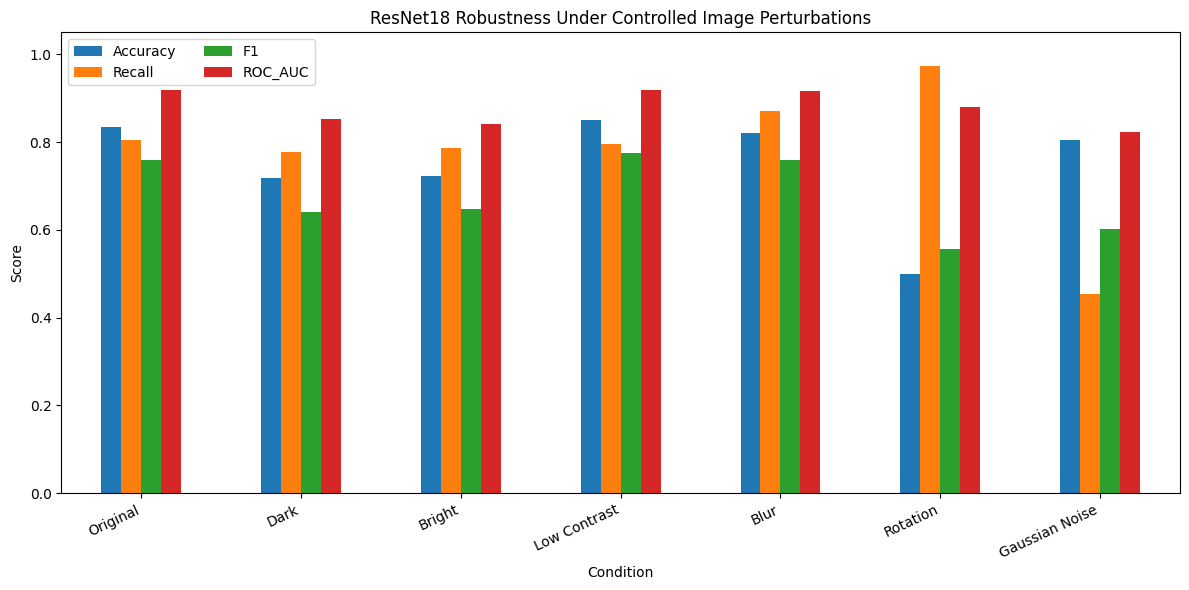

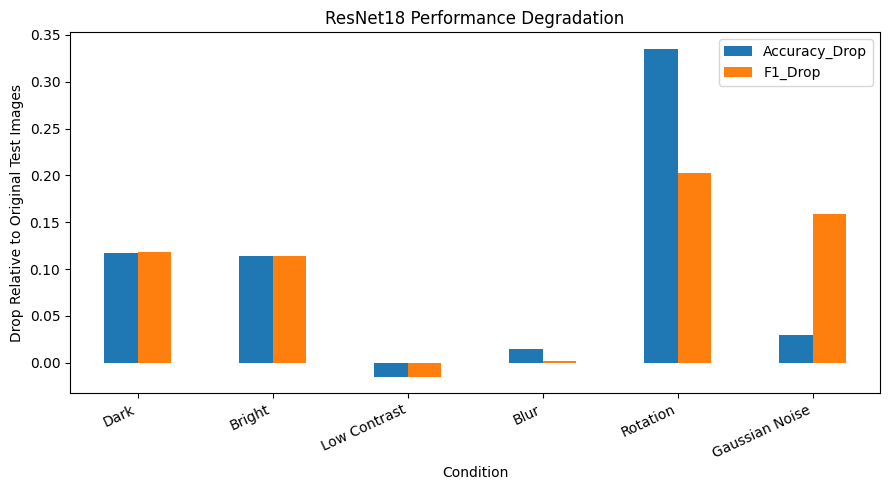

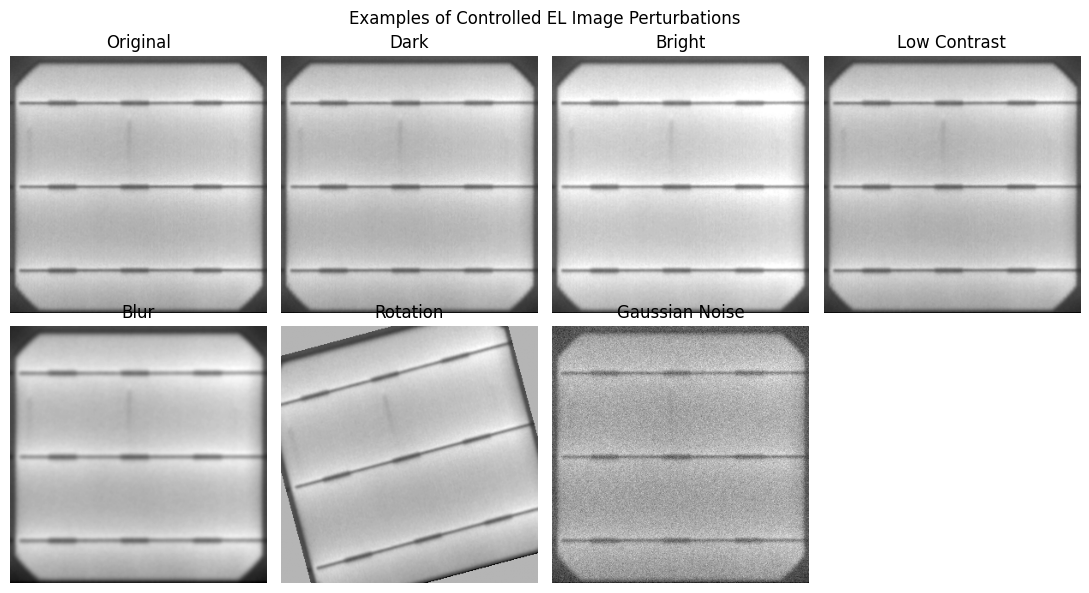


=== CELL 18 SUMMARY ===
Original Accuracy       : 0.8353
Original F1             : 0.7598
Original ROC-AUC        : 0.9182
Worst condition by F1   : Rotation
Worst-condition F1      : 0.5570
Worst condition by Acc. : Rotation
Worst-condition Accuracy: 0.5000
Most robust perturbation: Low Contrast
Best perturbed F1       : 0.7748
Results saved           : /content/elpv-dataset/outputs/tables/resnet18_robustness_results.csv
Figures saved           : /content/elpv-dataset/outputs/figures


In [23]:
# CELL 18: Controlled robustness benchmark for primary ResNet18

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score
)

# -------------------------------------------------------
# Load primary model
# -------------------------------------------------------

resnet_model.load_state_dict(
    torch.load(RESNET_MODEL_PATH, map_location=device)
)
resnet_model.eval()


# -------------------------------------------------------
# Deterministic image perturbations
# -------------------------------------------------------

def perturb_image(img, condition, idx=0):

    img = img.convert("L")

    if condition == "Original":
        return img

    elif condition == "Dark":
        return ImageEnhance.Brightness(img).enhance(0.70)

    elif condition == "Bright":
        return ImageEnhance.Brightness(img).enhance(1.30)

    elif condition == "Low Contrast":
        return ImageEnhance.Contrast(img).enhance(0.70)

    elif condition == "Blur":
        return img.filter(
            ImageFilter.GaussianBlur(radius=1.5)
        )

    elif condition == "Rotation":
        return img.rotate(
            15,
            resample=Image.BILINEAR,
            fillcolor=int(np.asarray(img).mean())
        )

    elif condition == "Gaussian Noise":

        arr = np.asarray(
            img,
            dtype=np.float32
        ) / 255.0

        rng = np.random.default_rng(
            SEED + idx
        )

        noise = rng.normal(
            0,
            0.05,
            arr.shape
        )

        arr = np.clip(
            arr + noise,
            0,
            1
        )

        return Image.fromarray(
            (arr * 255).astype(np.uint8)
        )


# -------------------------------------------------------
# Robustness dataset
# -------------------------------------------------------

class RobustELPVDataset(Dataset):

    def __init__(self, df, condition):
        self.df = df.reset_index(drop=True)
        self.condition = condition

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        r = self.df.iloc[idx]

        img = Image.open(
            r["filepath"]
        ).convert("L")

        img = perturb_image(
            img,
            self.condition,
            idx
        )

        x = resnet_eval_tfms(img)

        y = torch.tensor(
            float(r["label"])
        )

        return x, y


# -------------------------------------------------------
# Evaluation function
# -------------------------------------------------------

def evaluate_robustness(condition):

    dataset = RobustELPVDataset(
        test_df,
        condition
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0
    )

    y_true, y_prob = [], []

    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.to(device)

            logits = resnet_model(
                xb
            ).squeeze(1)

            probs = torch.sigmoid(
                logits
            )

            y_true.extend(
                yb.numpy().astype(int)
            )

            y_prob.extend(
                probs.cpu().numpy()
            )

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_pred = (
        y_prob >= LOCKED_THRESHOLD
    ).astype(int)

    return {
        "Condition": condition,

        "Accuracy":
            accuracy_score(
                y_true, y_pred
            ),

        "Precision":
            precision_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true, y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true, y_pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true, y_prob
            ),

        "Average_Precision":
            average_precision_score(
                y_true, y_prob
            )
    }


# -------------------------------------------------------
# Run robustness benchmark
# -------------------------------------------------------

conditions = [
    "Original",
    "Dark",
    "Bright",
    "Low Contrast",
    "Blur",
    "Rotation",
    "Gaussian Noise"
]

robustness_results = []

for condition in conditions:

    result = evaluate_robustness(
        condition
    )

    robustness_results.append(
        result
    )

    print(
        f"{condition:<15} | "
        f"Acc={result['Accuracy']:.4f} | "
        f"Recall={result['Recall']:.4f} | "
        f"F1={result['F1']:.4f} | "
        f"AUC={result['ROC_AUC']:.4f}"
    )


robust_df = pd.DataFrame(
    robustness_results
)

robust_df.to_csv(
    TAB_DIR / "resnet18_robustness_results.csv",
    index=False
)


# -------------------------------------------------------
# Calculate performance drop from clean test images
# -------------------------------------------------------

original = robust_df[
    robust_df.Condition == "Original"
].iloc[0]

robust_df["Accuracy_Drop"] = (
    original.Accuracy -
    robust_df.Accuracy
)

robust_df["F1_Drop"] = (
    original.F1 -
    robust_df.F1
)

robust_df.to_csv(
    TAB_DIR / "resnet18_robustness_results.csv",
    index=False
)


# -------------------------------------------------------
# FIGURE 1 — Metric comparison
# -------------------------------------------------------

plot_df = robust_df.set_index(
    "Condition"
)[
    [
        "Accuracy",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(12,6)
)

ax.set_ylim(0,1.05)
ax.set_ylabel("Score")

ax.set_title(
    "ResNet18 Robustness Under Controlled Image Perturbations"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    ncol=2
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_robustness_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# FIGURE 2 — Performance degradation
# -------------------------------------------------------

temp = robust_df[
    robust_df.Condition != "Original"
].copy()

ax = temp.set_index(
    "Condition"
)[
    [
        "Accuracy_Drop",
        "F1_Drop"
    ]
].plot(
    kind="bar",
    figsize=(9,5)
)

plt.ylabel(
    "Drop Relative to Original Test Images"
)

plt.title(
    "ResNet18 Performance Degradation"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_robustness_drop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# FIGURE 3 — Perturbation examples
# -------------------------------------------------------

example_path = test_df.iloc[0][
    "filepath"
]

original_img = Image.open(
    example_path
).convert("L")

fig, axes = plt.subplots(
    2, 4,
    figsize=(11,6)
)

axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for i, condition in enumerate(
    conditions
):

    altered = perturb_image(
        original_img,
        condition,
        0
    )

    axes[i].imshow(
        altered,
        cmap="gray"
    )

    axes[i].set_title(
        condition
    )

    axes[i].axis("off")

plt.suptitle(
    "Examples of Controlled EL Image Perturbations"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "robustness_perturbation_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

perturbed = robust_df[
    robust_df.Condition != "Original"
]

worst_f1_row = perturbed.loc[
    perturbed.F1.idxmin()
]

worst_acc_row = perturbed.loc[
    perturbed.Accuracy.idxmin()
]

best_robust_row = perturbed.loc[
    perturbed.F1.idxmax()
]

print("\n=== CELL 18 SUMMARY ===")

print(
    f"Original Accuracy       : "
    f"{original.Accuracy:.4f}"
)

print(
    f"Original F1             : "
    f"{original.F1:.4f}"
)

print(
    f"Original ROC-AUC        : "
    f"{original.ROC_AUC:.4f}"
)

print(
    f"Worst condition by F1   : "
    f"{worst_f1_row.Condition}"
)

print(
    f"Worst-condition F1      : "
    f"{worst_f1_row.F1:.4f}"
)

print(
    f"Worst condition by Acc. : "
    f"{worst_acc_row.Condition}"
)

print(
    f"Worst-condition Accuracy: "
    f"{worst_acc_row.Accuracy:.4f}"
)

print(
    f"Most robust perturbation: "
    f"{best_robust_row.Condition}"
)

print(
    f"Best perturbed F1       : "
    f"{best_robust_row.F1:.4f}"
)

print(
    f"Results saved           : "
    f"{TAB_DIR/'resnet18_robustness_results.csv'}"
)

print(
    f"Figures saved           : "
    f"{FIG_DIR}"
)

,Cell_Type,Total,Functional,Defective,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,TN,FP,FN,TP
0,mono,135,88,47,0.8593,0.7800,0.8298,0.8750,0.8041,0.8524,0.9081,77,11,8,39
1,poly,199,138,61,0.8191,0.6761,0.7869,0.8333,0.7273,0.8101,0.9222,115,23,13,48


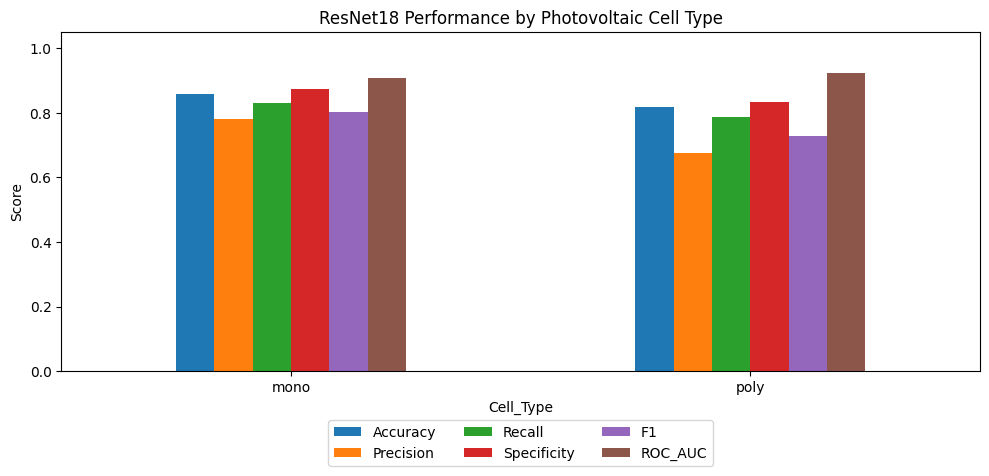

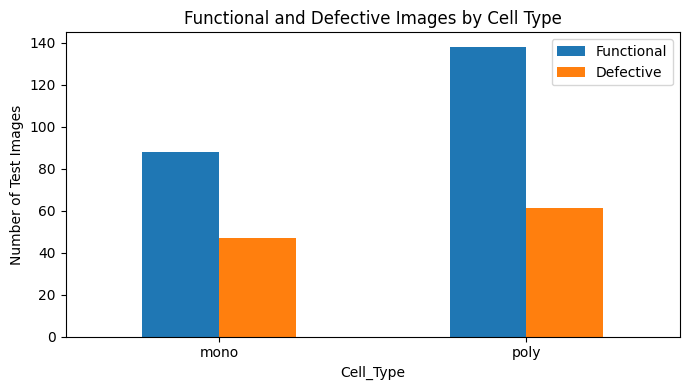


=== CELL 19 SUMMARY ===
MONOCRYSTALLINE
Images             : 135
Functional/Defect. : 88/47
Accuracy           : 0.8593
Recall             : 0.8298
Specificity        : 0.8750
F1                 : 0.8041
ROC-AUC            : 0.9081
Confusion matrix   : TN=77, FP=11, FN=8, TP=39

POLYCRYSTALLINE
Images             : 199
Functional/Defect. : 138/61
Accuracy           : 0.8191
Recall             : 0.7869
Specificity        : 0.8333
F1                 : 0.7273
ROC-AUC            : 0.9222
Confusion matrix   : TN=115, FP=23, FN=13, TP=48

SUBGROUP DIFFERENCE
Absolute F1 gap    : 0.0769
Absolute Recall gap: 0.0429
Absolute AUC gap   : 0.0141
Table saved        : /content/elpv-dataset/outputs/tables/resnet18_celltype_performance.csv
Figures saved      : /content/elpv-dataset/outputs/figures


In [24]:
# CELL 19: ResNet18 subgroup analysis — mono vs poly cells

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    balanced_accuracy_score, confusion_matrix
)

# -------------------------------------------------------
# Use final ResNet18 predictions already aligned to test_df
# -------------------------------------------------------

subgroup_df = base_test.copy()

rows = []

for cell_type in ["mono", "poly"]:

    g = subgroup_df[
        subgroup_df["cell_type"] == cell_type
    ].copy()

    y_true = g["label"].values.astype(int)

    y_pred = (
        g["ResNet18_Prediction"]
        .values.astype(int)
    )

    y_prob = (
        g["ResNet18_Probability"]
        .values
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    auc = (
        roc_auc_score(y_true, y_prob)
        if len(np.unique(y_true)) == 2
        else np.nan
    )

    rows.append({
        "Cell_Type": cell_type,
        "Total": len(g),

        "Functional":
            (y_true == 0).sum(),

        "Defective":
            (y_true == 1).sum(),

        "Accuracy":
            accuracy_score(
                y_true, y_pred
            ),

        "Precision":
            precision_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true, y_pred
            ),

        "ROC_AUC":
            auc,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


celltype_results = pd.DataFrame(rows)

celltype_results.to_csv(
    TAB_DIR /
    "resnet18_celltype_performance.csv",
    index=False
)

display(
    celltype_results.round(4)
)


# -------------------------------------------------------
# FIGURE 1 — Predictive performance by cell type
# -------------------------------------------------------

plot_df = (
    celltype_results
    .set_index("Cell_Type")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "ROC_AUC"
        ]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")

ax.set_title(
    "ResNet18 Performance by Photovoltaic Cell Type"
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=3
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "resnet18_celltype_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# FIGURE 2 — Class composition by cell type
# -------------------------------------------------------

composition = (
    celltype_results
    .set_index("Cell_Type")
    [["Functional", "Defective"]]
)

composition.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Number of Test Images")

plt.title(
    "Functional and Defective Images by Cell Type"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "test_class_distribution_by_celltype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Differences between mono and poly
# -------------------------------------------------------

mono = celltype_results[
    celltype_results.Cell_Type == "mono"
].iloc[0]

poly = celltype_results[
    celltype_results.Cell_Type == "poly"
].iloc[0]

f1_gap = abs(
    mono.F1 - poly.F1
)

recall_gap = abs(
    mono.Recall - poly.Recall
)

auc_gap = abs(
    mono.ROC_AUC - poly.ROC_AUC
)


print("\n=== CELL 19 SUMMARY ===")

print("MONOCRYSTALLINE")
print(f"Images             : {int(mono.Total)}")
print(f"Functional/Defect. : {int(mono.Functional)}/{int(mono.Defective)}")
print(f"Accuracy           : {mono.Accuracy:.4f}")
print(f"Recall             : {mono.Recall:.4f}")
print(f"Specificity        : {mono.Specificity:.4f}")
print(f"F1                 : {mono.F1:.4f}")
print(f"ROC-AUC            : {mono.ROC_AUC:.4f}")
print(
    f"Confusion matrix   : "
    f"TN={int(mono.TN)}, FP={int(mono.FP)}, "
    f"FN={int(mono.FN)}, TP={int(mono.TP)}"
)

print("\nPOLYCRYSTALLINE")
print(f"Images             : {int(poly.Total)}")
print(f"Functional/Defect. : {int(poly.Functional)}/{int(poly.Defective)}")
print(f"Accuracy           : {poly.Accuracy:.4f}")
print(f"Recall             : {poly.Recall:.4f}")
print(f"Specificity        : {poly.Specificity:.4f}")
print(f"F1                 : {poly.F1:.4f}")
print(f"ROC-AUC            : {poly.ROC_AUC:.4f}")
print(
    f"Confusion matrix   : "
    f"TN={int(poly.TN)}, FP={int(poly.FP)}, "
    f"FN={int(poly.FN)}, TP={int(poly.TP)}"
)

print("\nSUBGROUP DIFFERENCE")
print(f"Absolute F1 gap    : {f1_gap:.4f}")
print(f"Absolute Recall gap: {recall_gap:.4f}")
print(f"Absolute AUC gap   : {auc_gap:.4f}")

print(
    f"Table saved        : "
    f"{TAB_DIR/'resnet18_celltype_performance.csv'}"
)

print(
    f"Figures saved      : {FIG_DIR}"
)

Custom CNN       | Params=0.389M | Size=1.50 MB | Latency=0.941 ms | Throughput=1485.5 img/s
ResNet18         | Params=11.177M | Size=42.71 MB | Latency=2.327 ms | Throughput=1158.9 img/s
EfficientNet-B0  | Params=4.009M | Size=15.58 MB | Latency=8.838 ms | Throughput=848.7 img/s


,Model,Parameters,Parameters_Million,Checkpoint_MB,Latency_ms_per_image,Throughput_images_per_sec
0,Custom CNN,389057,0.389,1.498,0.941,1485.482
1,ResNet18,11177025,11.177,42.714,2.327,1158.853
2,EfficientNet-B0,4008829,4.009,15.584,8.838,848.668


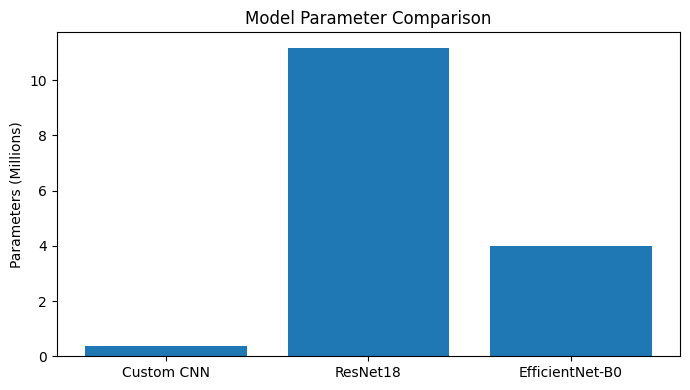

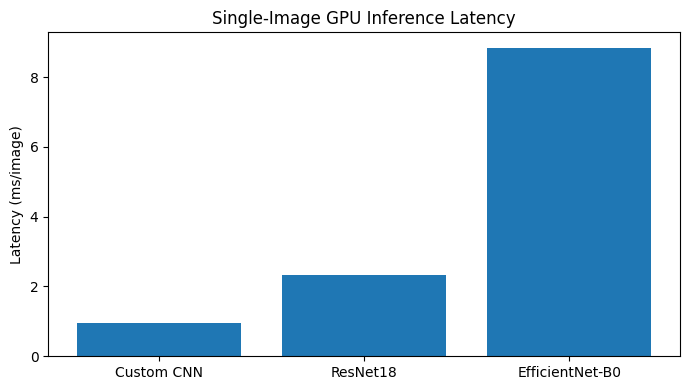

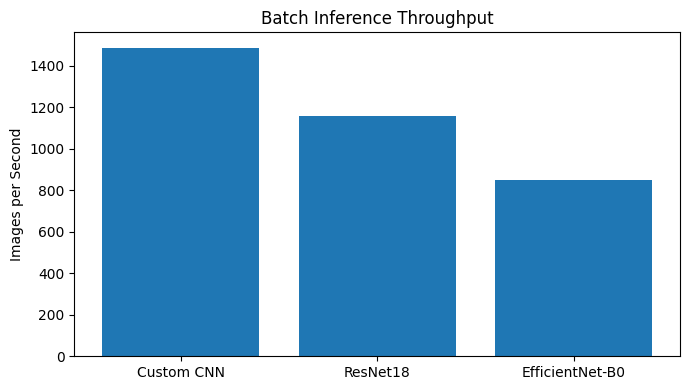


=== CELL 20 SUMMARY ===
Custom CNN      : 0.389M params | 1.50 MB | 0.941 ms/image | 1485.5 img/s
ResNet18        : 11.177M params | 42.71 MB | 2.327 ms/image | 1158.9 img/s
EfficientNet-B0 : 4.009M params | 15.58 MB | 8.838 ms/image | 848.7 img/s

Lowest latency      : Custom CNN
Highest throughput  : Custom CNN
Smallest checkpoint : Custom CNN
Device              : cuda
GPU                 : Tesla T4
Table saved         : /content/elpv-dataset/outputs/tables/three_model_efficiency.csv
Combined table      : /content/elpv-dataset/outputs/tables/performance_efficiency_summary.csv
Figures saved       : /content/elpv-dataset/outputs/figures


In [25]:
# CELL 20: Model efficiency — parameters, size, latency and throughput

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------------
# Ensure best checkpoints are loaded
# -------------------------------------------------------

model.load_state_dict(
    torch.load(BEST_MODEL, map_location=device)
)
model.eval()

resnet_model.load_state_dict(
    torch.load(RESNET_MODEL_PATH, map_location=device)
)
resnet_model.eval()

eff_model.load_state_dict(
    torch.load(EFF_MODEL_PATH, map_location=device)
)
eff_model.eval()


# -------------------------------------------------------
# Benchmark function
# -------------------------------------------------------

def benchmark_model(net, input_shape,
                    warmup=50, latency_runs=300,
                    batch_size=32, throughput_runs=100):

    net.eval()

    # -------- Batch-1 latency --------
    x1 = torch.randn(
        *input_shape,
        device=device
    )

    with torch.no_grad():

        for _ in range(warmup):
            _ = net(x1)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(latency_runs):
            _ = net(x1)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

    latency_ms = (
        elapsed / latency_runs
    ) * 1000


    # -------- Batch throughput --------
    xb_shape = (
        batch_size,
        *input_shape[1:]
    )

    xb = torch.randn(
        *xb_shape,
        device=device
    )

    with torch.no_grad():

        for _ in range(20):
            _ = net(xb)

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(throughput_runs):
            _ = net(xb)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

    throughput = (
        batch_size * throughput_runs
    ) / elapsed

    return latency_ms, throughput


# -------------------------------------------------------
# Benchmark all models
# -------------------------------------------------------

models_info = [
    (
        "Custom CNN",
        model,
        (1, 1, 224, 224),
        BEST_MODEL
    ),
    (
        "ResNet18",
        resnet_model,
        (1, 3, 224, 224),
        RESNET_MODEL_PATH
    ),
    (
        "EfficientNet-B0",
        eff_model,
        (1, 3, 224, 224),
        EFF_MODEL_PATH
    )
]

rows = []

for name, net, shape, checkpoint in models_info:

    params = sum(
        p.numel()
        for p in net.parameters()
    )

    checkpoint_mb = (
        Path(checkpoint).stat().st_size /
        (1024 ** 2)
    )

    latency, throughput = benchmark_model(
        net,
        shape
    )

    rows.append({
        "Model": name,
        "Parameters": params,
        "Parameters_Million": params / 1e6,
        "Checkpoint_MB": checkpoint_mb,
        "Latency_ms_per_image": latency,
        "Throughput_images_per_sec": throughput
    })

    print(
        f"{name:<16} | "
        f"Params={params/1e6:.3f}M | "
        f"Size={checkpoint_mb:.2f} MB | "
        f"Latency={latency:.3f} ms | "
        f"Throughput={throughput:.1f} img/s"
    )


efficiency_df = pd.DataFrame(rows)

efficiency_df.to_csv(
    TAB_DIR / "three_model_efficiency.csv",
    index=False
)

display(
    efficiency_df.round(3)
)


# -------------------------------------------------------
# Figure 1 — Parameter count
# -------------------------------------------------------

plt.figure(figsize=(7,4))

plt.bar(
    efficiency_df["Model"],
    efficiency_df["Parameters_Million"]
)

plt.ylabel("Parameters (Millions)")
plt.title("Model Parameter Comparison")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_model_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Figure 2 — Inference latency
# -------------------------------------------------------

plt.figure(figsize=(7,4))

plt.bar(
    efficiency_df["Model"],
    efficiency_df["Latency_ms_per_image"]
)

plt.ylabel("Latency (ms/image)")
plt.title("Single-Image GPU Inference Latency")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_model_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Figure 3 — Throughput
# -------------------------------------------------------

plt.figure(figsize=(7,4))

plt.bar(
    efficiency_df["Model"],
    efficiency_df["Throughput_images_per_sec"]
)

plt.ylabel("Images per Second")
plt.title("Batch Inference Throughput")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "three_model_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Combine predictive + efficiency information
# -------------------------------------------------------

perf_df = pd.read_csv(
    TAB_DIR / "three_model_test_comparison.csv"
)

performance_efficiency = perf_df.merge(
    efficiency_df,
    on="Model",
    how="left"
)

performance_efficiency.to_csv(
    TAB_DIR / "performance_efficiency_summary.csv",
    index=False
)


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

fastest = efficiency_df.loc[
    efficiency_df["Latency_ms_per_image"].idxmin()
]

highest_throughput = efficiency_df.loc[
    efficiency_df["Throughput_images_per_sec"].idxmax()
]

smallest = efficiency_df.loc[
    efficiency_df["Checkpoint_MB"].idxmin()
]

print("\n=== CELL 20 SUMMARY ===")

for _, r in efficiency_df.iterrows():

    print(
        f"{r.Model:<16}: "
        f"{r.Parameters_Million:.3f}M params | "
        f"{r.Checkpoint_MB:.2f} MB | "
        f"{r.Latency_ms_per_image:.3f} ms/image | "
        f"{r.Throughput_images_per_sec:.1f} img/s"
    )

print()
print(f"Lowest latency      : {fastest.Model}")
print(f"Highest throughput  : {highest_throughput.Model}")
print(f"Smallest checkpoint : {smallest.Model}")
print(f"Device              : {device}")

if device.type == "cuda":
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(
    f"Table saved         : "
    f"{TAB_DIR/'three_model_efficiency.csv'}"
)

print(
    f"Combined table      : "
    f"{TAB_DIR/'performance_efficiency_summary.csv'}"
)

print(
    f"Figures saved       : {FIG_DIR}"
)

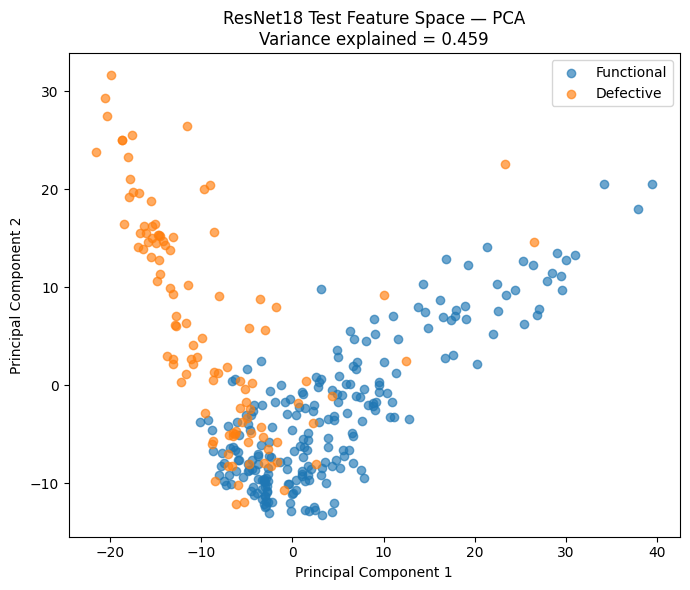

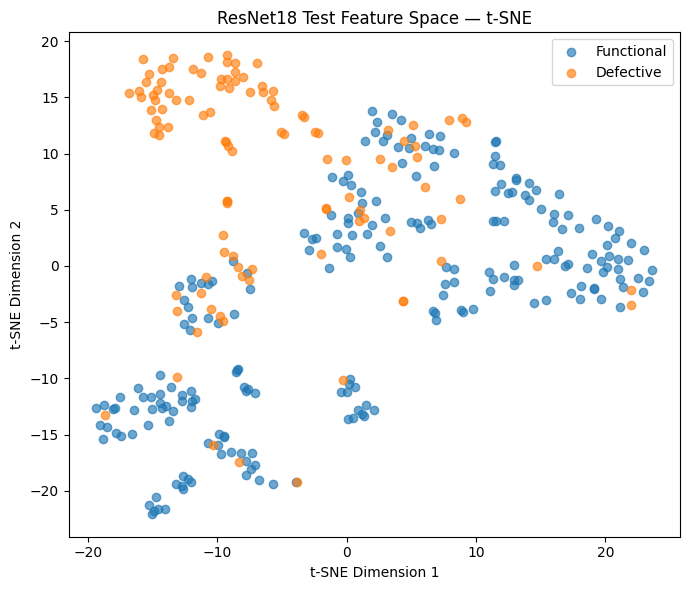

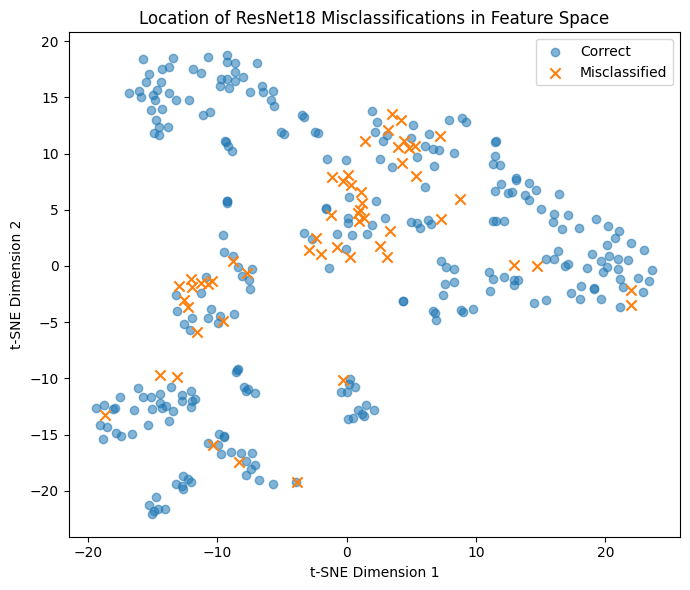


=== CELL 21 SUMMARY ===
Test embeddings       : 334
Feature dimensions    : 512
PCA PC1 variance      : 0.2631
PCA PC2 variance      : 0.1961
PCA total variance    : 0.4591
Correct predictions   : 279
Misclassified         : 55
Embeddings saved      : /content/elpv-dataset/outputs/tables/resnet18_feature_embeddings.csv
PCA figure saved      : /content/elpv-dataset/outputs/figures/resnet18_feature_pca.png
t-SNE figure saved    : /content/elpv-dataset/outputs/figures/resnet18_feature_tsne.png
Error map saved       : /content/elpv-dataset/outputs/figures/resnet18_tsne_errors.png


In [26]:
# CELL 21: ResNet18 feature-space analysis using PCA and t-SNE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -------------------------------------------------------
# Load best ResNet18
# -------------------------------------------------------

resnet_model.load_state_dict(
    torch.load(RESNET_MODEL_PATH, map_location=device)
)
resnet_model.eval()

# Remove final classifier -> 512-dimensional embeddings
feature_extractor = nn.Sequential(
    *list(resnet_model.children())[:-1]
).to(device)

feature_extractor.eval()

# -------------------------------------------------------
# Extract TEST embeddings
# -------------------------------------------------------

features = []
labels = []

with torch.no_grad():

    for xb, yb in resnet_test_loader:

        xb = xb.to(device)

        z = feature_extractor(xb)
        z = torch.flatten(z, 1)

        features.append(
            z.cpu().numpy()
        )

        labels.extend(
            yb.numpy().astype(int)
        )

features = np.vstack(features)
labels = np.array(labels)

class_names = np.where(
    labels == 0,
    "Functional",
    "Defective"
)

# -------------------------------------------------------
# PCA
# -------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=SEED
)

pca_xy = pca.fit_transform(
    features
)

pca_variance = (
    pca.explained_variance_ratio_.sum()
)

# -------------------------------------------------------
# t-SNE
# -------------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED
)

tsne_xy = tsne.fit_transform(
    features
)

# -------------------------------------------------------
# Save embeddings
# -------------------------------------------------------

embedding_df = test_df[
    [
        "filename",
        "label",
        "class_name",
        "cell_type"
    ]
].copy().reset_index(drop=True)

embedding_df["PCA1"] = pca_xy[:, 0]
embedding_df["PCA2"] = pca_xy[:, 1]

embedding_df["TSNE1"] = tsne_xy[:, 0]
embedding_df["TSNE2"] = tsne_xy[:, 1]

embedding_df["ResNet18_Prediction"] = (
    base_test["ResNet18_Prediction"]
    .values
)

embedding_df["Correct"] = (
    embedding_df["label"] ==
    embedding_df["ResNet18_Prediction"]
)

embedding_df.to_csv(
    TAB_DIR / "resnet18_feature_embeddings.csv",
    index=False
)

# -------------------------------------------------------
# FIGURE 1 — PCA
# -------------------------------------------------------

plt.figure(figsize=(7, 6))

for label, name in [
    (0, "Functional"),
    (1, "Defective")
]:

    mask = labels == label

    plt.scatter(
        pca_xy[mask, 0],
        pca_xy[mask, 1],
        alpha=0.65,
        label=name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    f"ResNet18 Test Feature Space — PCA\n"
    f"Variance explained = {pca_variance:.3f}"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_feature_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# FIGURE 2 — t-SNE
# -------------------------------------------------------

plt.figure(figsize=(7, 6))

for label, name in [
    (0, "Functional"),
    (1, "Defective")
]:

    mask = labels == label

    plt.scatter(
        tsne_xy[mask, 0],
        tsne_xy[mask, 1],
        alpha=0.65,
        label=name
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.title(
    "ResNet18 Test Feature Space — t-SNE"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_feature_tsne.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# FIGURE 3 — Correct vs incorrect predictions
# -------------------------------------------------------

plt.figure(figsize=(7, 6))

correct_mask = embedding_df["Correct"].values
wrong_mask = ~correct_mask

plt.scatter(
    tsne_xy[correct_mask, 0],
    tsne_xy[correct_mask, 1],
    alpha=0.55,
    label="Correct"
)

plt.scatter(
    tsne_xy[wrong_mask, 0],
    tsne_xy[wrong_mask, 1],
    marker="x",
    s=55,
    label="Misclassified"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.title(
    "Location of ResNet18 Misclassifications in Feature Space"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "resnet18_tsne_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -------------------------------------------------------
# Save PCA information
# -------------------------------------------------------

pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_Variance": (
        pca.explained_variance_ratio_
    )
}).to_csv(
    TAB_DIR / "resnet18_pca_variance.csv",
    index=False
)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------

print("\n=== CELL 21 SUMMARY ===")

print(f"Test embeddings       : {features.shape[0]}")
print(f"Feature dimensions    : {features.shape[1]}")
print(f"PCA PC1 variance      : {pca.explained_variance_ratio_[0]:.4f}")
print(f"PCA PC2 variance      : {pca.explained_variance_ratio_[1]:.4f}")
print(f"PCA total variance    : {pca_variance:.4f}")
print(f"Correct predictions   : {embedding_df['Correct'].sum()}")
print(f"Misclassified         : {(~embedding_df['Correct']).sum()}")

print(
    f"Embeddings saved      : "
    f"{TAB_DIR/'resnet18_feature_embeddings.csv'}"
)

print(
    f"PCA figure saved      : "
    f"{FIG_DIR/'resnet18_feature_pca.png'}"
)

print(
    f"t-SNE figure saved    : "
    f"{FIG_DIR/'resnet18_feature_tsne.png'}"
)

print(
    f"Error map saved       : "
    f"{FIG_DIR/'resnet18_tsne_errors.png'}"
)

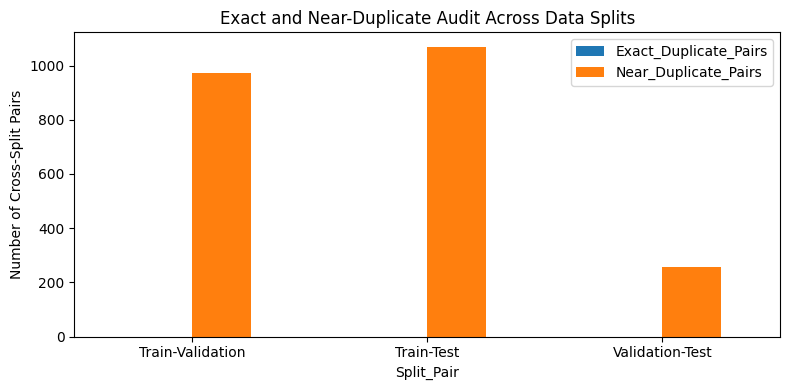


=== CELL 22 SUMMARY ===
Train-Validation    : Exact=0 | Near(dHash<=4)=973
Train-Test          : Exact=0 | Near(dHash<=4)=1069
Validation-Test     : Exact=0 | Near(dHash<=4)=256

Total exact cross-split : 0
Total near cross-split  : 2298
Near-duplicate threshold: dHash distance <= 4
Audit table saved       : /content/elpv-dataset/outputs/tables/duplicate_audit_summary.csv
Near pairs saved        : /content/elpv-dataset/outputs/tables/near_duplicate_pairs.csv
Figure saved            : /content/elpv-dataset/outputs/figures/duplicate_audit.png


In [27]:
# CELL 22: Cross-split exact and near-duplicate leakage audit

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------------------------------
# Hash functions
# -------------------------------------------------------

def pixel_md5(path):
    """Exact hash from grayscale pixel content."""
    img = Image.open(path).convert("L")
    arr = np.asarray(img, dtype=np.uint8)
    return hashlib.md5(arr.tobytes()).hexdigest()


def dhash(path):
    """64-bit perceptual difference hash."""
    img = Image.open(path).convert("L").resize((9, 8))
    arr = np.asarray(img, dtype=np.uint8)

    diff = arr[:, 1:] > arr[:, :-1]

    value = 0
    for bit in diff.flatten():
        value = (value << 1) | int(bit)

    return value


# -------------------------------------------------------
# Create one audit table
# -------------------------------------------------------

audit_parts = []

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    temp = df[
        ["filename", "filepath", "label", "cell_type"]
    ].copy()

    temp["Split"] = split_name

    temp["Exact_Hash"] = temp["filepath"].apply(
        pixel_md5
    )

    temp["dHash"] = temp["filepath"].apply(
        dhash
    )

    audit_parts.append(temp)


hash_df = pd.concat(
    audit_parts,
    ignore_index=True
)

hash_df.to_csv(
    TAB_DIR / "image_hash_audit.csv",
    index=False
)


# -------------------------------------------------------
# Compare split pairs
# -------------------------------------------------------

split_pairs = [
    ("Train", "Validation"),
    ("Train", "Test"),
    ("Validation", "Test")
]

NEAR_THRESHOLD = 4

summary_rows = []
near_rows = []

for split_a, split_b in split_pairs:

    a = hash_df[
        hash_df.Split == split_a
    ].reset_index(drop=True)

    b = hash_df[
        hash_df.Split == split_b
    ].reset_index(drop=True)

    # Exact duplicate pairs
    exact_matches = a.merge(
        b,
        on="Exact_Hash",
        suffixes=("_A", "_B")
    )

    exact_count = len(
        exact_matches
    )

    # Near duplicate pairs
    near_count = 0

    for _, ra in a.iterrows():

        ha = int(ra["dHash"])

        for _, rb in b.iterrows():

            hb = int(rb["dHash"])

            distance = (
                ha ^ hb
            ).bit_count()

            # 1-4 = near duplicate;
            # exact image duplicates counted separately
            if 1 <= distance <= NEAR_THRESHOLD:

                near_count += 1

                near_rows.append({
                    "Split_A": split_a,
                    "Filename_A": ra["filename"],

                    "Split_B": split_b,
                    "Filename_B": rb["filename"],

                    "dHash_Distance": distance
                })

    summary_rows.append({
        "Split_Pair":
            f"{split_a}-{split_b}",

        "Exact_Duplicate_Pairs":
            exact_count,

        "Near_Duplicate_Pairs":
            near_count
    })


duplicate_summary = pd.DataFrame(
    summary_rows
)

near_df = pd.DataFrame(
    near_rows
)

duplicate_summary.to_csv(
    TAB_DIR / "duplicate_audit_summary.csv",
    index=False
)

near_df.to_csv(
    TAB_DIR / "near_duplicate_pairs.csv",
    index=False
)


# -------------------------------------------------------
# Figure
# -------------------------------------------------------

plot_df = duplicate_summary.set_index(
    "Split_Pair"
)[
    [
        "Exact_Duplicate_Pairs",
        "Near_Duplicate_Pairs"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.ylabel("Number of Cross-Split Pairs")

plt.title(
    "Exact and Near-Duplicate Audit Across Data Splits"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "duplicate_audit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

total_exact = (
    duplicate_summary[
        "Exact_Duplicate_Pairs"
    ].sum()
)

total_near = (
    duplicate_summary[
        "Near_Duplicate_Pairs"
    ].sum()
)


print("\n=== CELL 22 SUMMARY ===")

for _, r in duplicate_summary.iterrows():

    print(
        f"{r.Split_Pair:<20}: "
        f"Exact={int(r.Exact_Duplicate_Pairs)} | "
        f"Near(dHash<=4)={int(r.Near_Duplicate_Pairs)}"
    )

print()
print(f"Total exact cross-split : {int(total_exact)}")
print(f"Total near cross-split  : {int(total_near)}")
print(f"Near-duplicate threshold: dHash distance <= {NEAR_THRESHOLD}")

print(
    f"Audit table saved       : "
    f"{TAB_DIR/'duplicate_audit_summary.csv'}"
)

print(
    f"Near pairs saved        : "
    f"{TAB_DIR/'near_duplicate_pairs.csv'}"
)

print(
    f"Figure saved            : "
    f"{FIG_DIR/'duplicate_audit.png'}"
)

,Split_Pair,pHash_Candidates,Strict_Verified_Near_Duplicates
0,Train-Validation,134,5
1,Train-Test,151,4
2,Validation-Test,29,1


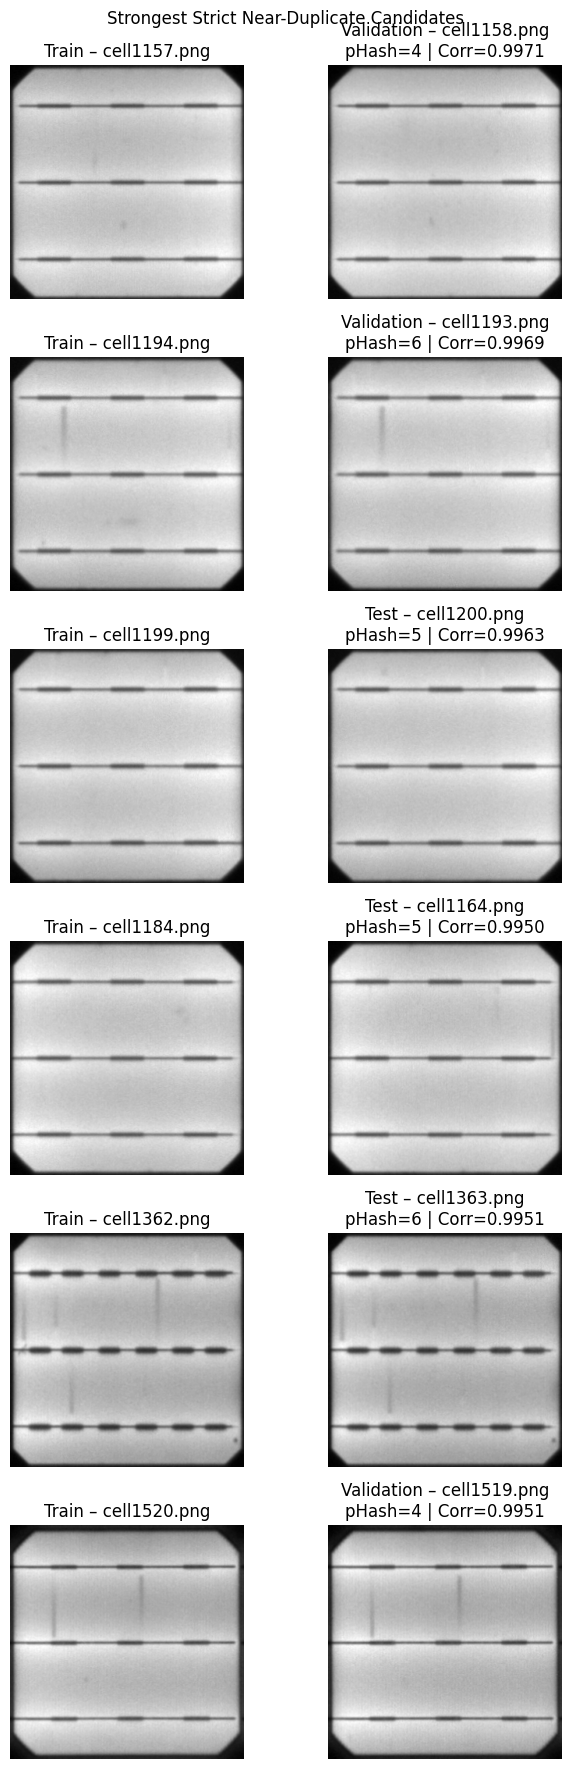

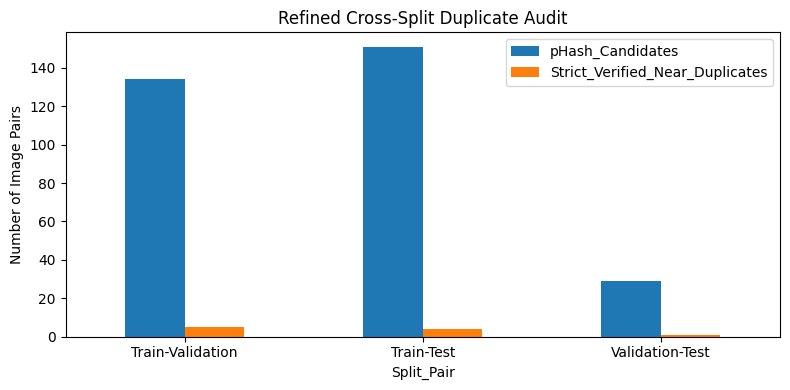


=== CELL 22B SUMMARY ===
Original dHash result should be treated as
candidate visual similarity, NOT confirmed leakage.

Train-Validation    : pHash candidates=134 | Strict verified=5
Train-Test          : pHash candidates=151 | Strict verified=4
Validation-Test     : pHash candidates=29 | Strict verified=1

Total pHash candidates : 314
Strict verified pairs  : 10
pHash threshold        : <= 6
Full-image correlation : >= 0.995
Residual correlation   : >= 0.98
Exact MD5 duplicates   : 0
Summary saved          : /content/elpv-dataset/outputs/tables/refined_duplicate_audit_summary.csv
Verified pairs saved   : /content/elpv-dataset/outputs/tables/strict_verified_near_duplicates.csv
Figure saved           : /content/elpv-dataset/outputs/figures/refined_duplicate_audit.png


In [28]:
# CELL 22B: Refined cross-split near-duplicate verification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter
from scipy.fftpack import dct

# -------------------------------------------------------
# Perceptual hash (pHash)
# -------------------------------------------------------

def phash(path, hash_size=8, highfreq_factor=4):

    size = hash_size * highfreq_factor

    img = Image.open(path).convert("L").resize(
        (size, size),
        Image.Resampling.LANCZOS
    )

    arr = np.asarray(img, dtype=np.float32)

    # 2D DCT
    dct_rows = dct(arr, axis=0, norm="ortho")
    dct_2d = dct(dct_rows, axis=1, norm="ortho")

    low = dct_2d[:hash_size, :hash_size]

    # exclude DC coefficient
    median = np.median(low[1:, 1:])

    bits = low > median

    value = 0

    for bit in bits.flatten():
        value = (value << 1) | int(bit)

    return value


# -------------------------------------------------------
# Image representations for strict verification
# -------------------------------------------------------

def similarity_arrays(path):

    img = Image.open(path).convert("L").resize(
        (96, 96),
        Image.Resampling.LANCZOS
    )

    arr = np.asarray(
        img,
        dtype=np.float32
    ) / 255.0

    # Standardised full image
    z = (
        arr - arr.mean()
    ) / (
        arr.std() + 1e-8
    )

    # High-frequency residual:
    # emphasises local cracks / defect structures
    blur = np.asarray(
        img.filter(
            ImageFilter.GaussianBlur(radius=2)
        ),
        dtype=np.float32
    ) / 255.0

    residual = arr - blur

    residual = (
        residual - residual.mean()
    ) / (
        residual.std() + 1e-8
    )

    return z, residual


def correlation(a, b):

    a = a.ravel()
    b = b.ravel()

    return float(
        np.corrcoef(a, b)[0, 1]
    )


# -------------------------------------------------------
# Build pHash table
# -------------------------------------------------------

refined_parts = []

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    temp = df[
        [
            "filename",
            "filepath",
            "label",
            "cell_type"
        ]
    ].copy()

    temp["Split"] = split_name

    temp["pHash"] = (
        temp["filepath"]
        .apply(phash)
    )

    refined_parts.append(temp)


refined_hash_df = pd.concat(
    refined_parts,
    ignore_index=True
)


# -------------------------------------------------------
# Pairwise comparison
# -------------------------------------------------------

split_pairs = [
    ("Train", "Validation"),
    ("Train", "Test"),
    ("Validation", "Test")
]

# pHash candidate threshold
PHASH_THRESHOLD = 6

# Strict verification thresholds
FULL_CORR_THRESHOLD = 0.995
RESIDUAL_CORR_THRESHOLD = 0.980

verified_rows = []
candidate_counts = []

# Cache arrays to avoid repeatedly opening files
array_cache = {}

def get_arrays(path):

    if path not in array_cache:
        array_cache[path] = similarity_arrays(path)

    return array_cache[path]


for split_a, split_b in split_pairs:

    a = refined_hash_df[
        refined_hash_df.Split == split_a
    ].reset_index(drop=True)

    b = refined_hash_df[
        refined_hash_df.Split == split_b
    ].reset_index(drop=True)

    candidate_count = 0
    verified_count = 0

    for _, ra in a.iterrows():

        ha = int(ra["pHash"])

        for _, rb in b.iterrows():

            hb = int(rb["pHash"])

            distance = (
                ha ^ hb
            ).bit_count()

            if distance <= PHASH_THRESHOLD:

                candidate_count += 1

                z1, r1 = get_arrays(
                    ra["filepath"]
                )

                z2, r2 = get_arrays(
                    rb["filepath"]
                )

                full_corr = correlation(
                    z1, z2
                )

                residual_corr = correlation(
                    r1, r2
                )

                verified = (
                    full_corr >= FULL_CORR_THRESHOLD
                    and
                    residual_corr >= RESIDUAL_CORR_THRESHOLD
                )

                if verified:

                    verified_count += 1

                    verified_rows.append({
                        "Split_A": split_a,
                        "Filename_A": ra["filename"],
                        "Path_A": ra["filepath"],

                        "Split_B": split_b,
                        "Filename_B": rb["filename"],
                        "Path_B": rb["filepath"],

                        "pHash_Distance": distance,
                        "Full_Image_Correlation": full_corr,
                        "Residual_Correlation": residual_corr,

                        "Label_A": ra["label"],
                        "Label_B": rb["label"],

                        "Cell_Type_A": ra["cell_type"],
                        "Cell_Type_B": rb["cell_type"]
                    })

    candidate_counts.append({
        "Split_Pair":
            f"{split_a}-{split_b}",

        "pHash_Candidates":
            candidate_count,

        "Strict_Verified_Near_Duplicates":
            verified_count
    })


# -------------------------------------------------------
# Save results
# -------------------------------------------------------

refined_summary = pd.DataFrame(
    candidate_counts
)

verified_df = pd.DataFrame(
    verified_rows
)

refined_summary.to_csv(
    TAB_DIR /
    "refined_duplicate_audit_summary.csv",
    index=False
)

verified_df.to_csv(
    TAB_DIR /
    "strict_verified_near_duplicates.csv",
    index=False
)

display(refined_summary)


# -------------------------------------------------------
# Visualise strongest verified candidates
# -------------------------------------------------------

if len(verified_df) > 0:

    verified_df["Combined_Similarity"] = (
        verified_df[
            "Full_Image_Correlation"
        ] +
        verified_df[
            "Residual_Correlation"
        ]
    ) / 2

    top_pairs = (
        verified_df
        .sort_values(
            "Combined_Similarity",
            ascending=False
        )
        .head(6)
    )

    fig, axes = plt.subplots(
        len(top_pairs),
        2,
        figsize=(7, 3 * len(top_pairs))
    )

    if len(top_pairs) == 1:
        axes = np.array([axes])

    for i, (_, r) in enumerate(
        top_pairs.iterrows()
    ):

        img_a = Image.open(
            r["Path_A"]
        ).convert("L")

        img_b = Image.open(
            r["Path_B"]
        ).convert("L")

        axes[i, 0].imshow(
            img_a,
            cmap="gray"
        )

        axes[i, 1].imshow(
            img_b,
            cmap="gray"
        )

        axes[i, 0].set_title(
            f"{r['Split_A']} – {r['Filename_A']}"
        )

        axes[i, 1].set_title(
            f"{r['Split_B']} – {r['Filename_B']}\n"
            f"pHash={r['pHash_Distance']} | "
            f"Corr={r['Full_Image_Correlation']:.4f}"
        )

        axes[i, 0].axis("off")
        axes[i, 1].axis("off")

    plt.suptitle(
        "Strongest Strict Near-Duplicate Candidates"
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR /
        "verified_near_duplicate_examples.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    plt.figure(figsize=(6,3))

    plt.text(
        0.5,
        0.5,
        "No strict near-duplicates detected",
        ha="center",
        va="center",
        fontsize=14
    )

    plt.axis("off")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR /
        "verified_near_duplicate_examples.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# -------------------------------------------------------
# Figure — candidate vs verified
# -------------------------------------------------------

plot_df = refined_summary.set_index(
    "Split_Pair"
)

plot_df.plot(
    kind="bar",
    figsize=(8,4)
)

plt.ylabel("Number of Image Pairs")

plt.title(
    "Refined Cross-Split Duplicate Audit"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "refined_duplicate_audit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# Summary
# -------------------------------------------------------

total_candidates = (
    refined_summary[
        "pHash_Candidates"
    ].sum()
)

total_verified = (
    refined_summary[
        "Strict_Verified_Near_Duplicates"
    ].sum()
)


print("\n=== CELL 22B SUMMARY ===")

print("Original dHash result should be treated as")
print("candidate visual similarity, NOT confirmed leakage.\n")

for _, r in refined_summary.iterrows():

    print(
        f"{r.Split_Pair:<20}: "
        f"pHash candidates="
        f"{int(r.pHash_Candidates)} | "
        f"Strict verified="
        f"{int(r.Strict_Verified_Near_Duplicates)}"
    )

print()

print(
    f"Total pHash candidates : "
    f"{int(total_candidates)}"
)

print(
    f"Strict verified pairs  : "
    f"{int(total_verified)}"
)

print(
    f"pHash threshold        : "
    f"<= {PHASH_THRESHOLD}"
)

print(
    f"Full-image correlation : "
    f">= {FULL_CORR_THRESHOLD}"
)

print(
    f"Residual correlation   : "
    f">= {RESIDUAL_CORR_THRESHOLD}"
)

print(
    f"Exact MD5 duplicates   : 0"
)

print(
    f"Summary saved          : "
    f"{TAB_DIR/'refined_duplicate_audit_summary.csv'}"
)

print(
    f"Verified pairs saved   : "
    f"{TAB_DIR/'strict_verified_near_duplicates.csv'}"
)

print(
    f"Figure saved           : "
    f"{FIG_DIR/'refined_duplicate_audit.png'}"
)

In [29]:
# CELL 22C: Characterise strict near-duplicate pairs

import pandas as pd
import numpy as np

verified = pd.read_csv(
    TAB_DIR / "strict_verified_near_duplicates.csv"
)

# -------------------------------------------------------
# Basic pair characteristics
# -------------------------------------------------------

verified["Same_Label"] = (
    verified["Label_A"] ==
    verified["Label_B"]
)

verified["Same_Cell_Type"] = (
    verified["Cell_Type_A"] ==
    verified["Cell_Type_B"]
)

verified["Pair"] = (
    verified["Split_A"] +
    "-" +
    verified["Split_B"]
)

# -------------------------------------------------------
# Count unique affected images in each split
# -------------------------------------------------------

affected_records = []

for _, r in verified.iterrows():

    affected_records.append({
        "Split": r["Split_A"],
        "Filename": r["Filename_A"]
    })

    affected_records.append({
        "Split": r["Split_B"],
        "Filename": r["Filename_B"]
    })

affected_df = (
    pd.DataFrame(affected_records)
    .drop_duplicates()
)

affected_summary = (
    affected_df["Split"]
    .value_counts()
    .reindex(
        ["Train", "Validation", "Test"],
        fill_value=0
    )
)

# -------------------------------------------------------
# Pair-level summary
# -------------------------------------------------------

pair_summary = (
    verified.groupby("Pair")
    .agg(
        Pairs=("Pair", "size"),
        Same_Label=("Same_Label", "sum"),
        Same_Cell_Type=("Same_Cell_Type", "sum"),
        Mean_Full_Correlation=(
            "Full_Image_Correlation", "mean"
        ),
        Mean_Residual_Correlation=(
            "Residual_Correlation", "mean"
        )
    )
    .reset_index()
)

pair_summary.to_csv(
    TAB_DIR /
    "strict_near_duplicate_characteristics.csv",
    index=False
)

affected_df.to_csv(
    TAB_DIR /
    "strict_near_duplicate_affected_images.csv",
    index=False
)

# Save detailed table with new columns
verified.to_csv(
    TAB_DIR /
    "strict_near_duplicates_detailed.csv",
    index=False
)

display(
    verified[
        [
            "Split_A", "Filename_A",
            "Split_B", "Filename_B",
            "Label_A", "Label_B",
            "Cell_Type_A", "Cell_Type_B",
            "pHash_Distance",
            "Full_Image_Correlation",
            "Residual_Correlation",
            "Same_Label"
        ]
    ].round(4)
)

print("\n=== CELL 22C SUMMARY ===")

print(f"Strict pairs             : {len(verified)}")
print(f"Same-label pairs         : {verified['Same_Label'].sum()}")
print(f"Different-label pairs    : {(~verified['Same_Label']).sum()}")
print(f"Same-cell-type pairs     : {verified['Same_Cell_Type'].sum()}")

print("\nUNIQUE AFFECTED IMAGES")

for split in [
    "Train",
    "Validation",
    "Test"
]:
    print(
        f"{split:<10}: "
        f"{int(affected_summary[split])}"
    )

print(
    f"Total unique images      : "
    f"{len(affected_df)}"
)

print(
    f"Mean full correlation    : "
    f"{verified['Full_Image_Correlation'].mean():.4f}"
)

print(
    f"Mean residual correlation: "
    f"{verified['Residual_Correlation'].mean():.4f}"
)

print(
    f"Detailed table saved     : "
    f"{TAB_DIR/'strict_near_duplicates_detailed.csv'}"
)

print(
    f"Affected images saved    : "
    f"{TAB_DIR/'strict_near_duplicate_affected_images.csv'}"
)

,Split_A,Filename_A,Split_B,Filename_B,Label_A,Label_B,Cell_Type_A,Cell_Type_B,pHash_Distance,Full_Image_Correlation,Residual_Correlation,Same_Label
0,Train,cell2361.png,Validation,cell2360.png,0,0,poly,poly,3,0.9951,0.9904,True
1,Train,cell1521.png,Validation,cell1519.png,0,0,mono,mono,5,0.9957,0.9887,True
2,Train,cell1157.png,Validation,cell1158.png,0,0,mono,mono,4,0.9971,0.9931,True
3,Train,cell1520.png,Validation,cell1519.png,0,0,mono,mono,4,0.9951,0.9907,True
4,Train,cell1194.png,Validation,cell1193.png,0,0,mono,mono,6,0.9969,0.9912,True
5,Train,cell1362.png,Test,cell1363.png,0,0,mono,mono,6,0.9951,0.9915,True
6,Train,cell1199.png,Test,cell1200.png,0,0,mono,mono,5,0.9963,0.9912,True
7,Train,cell1184.png,Test,cell1164.png,0,0,mono,mono,5,0.9950,0.9920,True
8,Train,cell1549.png,Test,cell1550.png,0,0,mono,mono,6,0.9967,0.9878,True
9,Validation,cell1609.png,Test,cell1610.png,0,0,mono,mono,6,0.9959,0.9884,True



=== CELL 22C SUMMARY ===
Strict pairs             : 10
Same-label pairs         : 10
Different-label pairs    : 0
Same-cell-type pairs     : 10

UNIQUE AFFECTED IMAGES
Train     : 9
Validation: 5
Test      : 5
Total unique images      : 19
Mean full correlation    : 0.9959
Mean residual correlation: 0.9905
Detailed table saved     : /content/elpv-dataset/outputs/tables/strict_near_duplicates_detailed.csv
Affected images saved    : /content/elpv-dataset/outputs/tables/strict_near_duplicate_affected_images.csv


In [30]:
# CELL 23: Sensitivity analysis excluding 5 high-similarity test images

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

# -------------------------------------------------------
# Load affected-image list
# -------------------------------------------------------

affected = pd.read_csv(
    TAB_DIR / "strict_near_duplicate_affected_images.csv"
)

affected_test = affected[
    affected["Split"] == "Test"
]["Filename"].unique()

# -------------------------------------------------------
# Load final ResNet18 predictions
# -------------------------------------------------------

pred_df = pd.read_csv(
    TAB_DIR / "resnet18_test_predictions.csv"
)

# Full original test set
full_df = pred_df.copy()

# Sensitivity subset: remove only affected TEST images
clean_df = pred_df[
    ~pred_df["filename"].isin(affected_test)
].copy()


# -------------------------------------------------------
# Metric function
# -------------------------------------------------------

def calculate_metrics(df):

    y_true = df["label"].values.astype(int)
    y_prob = df["Defective_Probability"].values

    y_pred = (
        y_prob >= LOCKED_THRESHOLD
    ).astype(int)

    cm = confusion_matrix(
        y_true, y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = (
        tn / (tn + fp)
    )

    return {
        "N": len(df),

        "Accuracy":
            accuracy_score(
                y_true, y_pred
            ),

        "Precision":
            precision_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true, y_pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true, y_pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true, y_prob
            ),

        "Average_Precision":
            average_precision_score(
                y_true, y_prob
            ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


full_metrics = calculate_metrics(
    full_df
)

clean_metrics = calculate_metrics(
    clean_df
)


# -------------------------------------------------------
# Check affected-test predictions
# -------------------------------------------------------

affected_predictions = pred_df[
    pred_df["filename"].isin(
        affected_test
    )
].copy()

affected_predictions["Correct"] = (
    affected_predictions["label"] ==
    affected_predictions["Predicted_Label"]
)

affected_predictions.to_csv(
    TAB_DIR /
    "high_similarity_test_predictions.csv",
    index=False
)


# -------------------------------------------------------
# Comparison table
# -------------------------------------------------------

comparison = pd.DataFrame([
    {
        "Evaluation":
            "Original Test Set",
        **full_metrics
    },

    {
        "Evaluation":
            "After Excluding High-Similarity Test Images",
        **clean_metrics
    }
])

comparison.to_csv(
    TAB_DIR /
    "high_similarity_sensitivity_analysis.csv",
    index=False
)

display(
    comparison.round(4)
)


# -------------------------------------------------------
# Metric changes
# -------------------------------------------------------

accuracy_change = (
    clean_metrics["Accuracy"] -
    full_metrics["Accuracy"]
)

f1_change = (
    clean_metrics["F1"] -
    full_metrics["F1"]
)

auc_change = (
    clean_metrics["ROC_AUC"] -
    full_metrics["ROC_AUC"]
)


print("\n=== CELL 23 SUMMARY ===")

print(
    f"Original test images      : "
    f"{full_metrics['N']}"
)

print(
    f"High-similarity removed   : "
    f"{len(affected_test)}"
)

print(
    f"Sensitivity test images   : "
    f"{clean_metrics['N']}"
)

print(
    f"Affected images correct   : "
    f"{affected_predictions['Correct'].sum()}/"
    f"{len(affected_predictions)}"
)

print("\nORIGINAL TEST")
print(
    f"Accuracy                  : "
    f"{full_metrics['Accuracy']:.4f}"
)
print(
    f"Recall                    : "
    f"{full_metrics['Recall']:.4f}"
)
print(
    f"F1                        : "
    f"{full_metrics['F1']:.4f}"
)
print(
    f"ROC-AUC                   : "
    f"{full_metrics['ROC_AUC']:.4f}"
)

print("\nSENSITIVITY TEST")
print(
    f"Accuracy                  : "
    f"{clean_metrics['Accuracy']:.4f}"
)
print(
    f"Recall                    : "
    f"{clean_metrics['Recall']:.4f}"
)
print(
    f"F1                        : "
    f"{clean_metrics['F1']:.4f}"
)
print(
    f"ROC-AUC                   : "
    f"{clean_metrics['ROC_AUC']:.4f}"
)

print("\nCHANGE AFTER EXCLUSION")
print(
    f"Accuracy change           : "
    f"{accuracy_change:+.4f}"
)
print(
    f"F1 change                 : "
    f"{f1_change:+.4f}"
)
print(
    f"ROC-AUC change            : "
    f"{auc_change:+.4f}"
)

print(
    f"\nTable saved               : "
    f"{TAB_DIR/'high_similarity_sensitivity_analysis.csv'}"
)

,Evaluation,N,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,Average_Precision,TN,FP,FN,TP
0,Original Test Set,334,0.8353,0.719,0.8056,0.8496,0.7598,0.8276,0.9182,0.8937,192,34,21,87
1,After Excluding High-Similarity Test Images,329,0.8328,0.719,0.8056,0.8462,0.7598,0.8259,0.9178,0.8943,187,34,21,87



=== CELL 23 SUMMARY ===
Original test images      : 334
High-similarity removed   : 5
Sensitivity test images   : 329
Affected images correct   : 5/5

ORIGINAL TEST
Accuracy                  : 0.8353
Recall                    : 0.8056
F1                        : 0.7598
ROC-AUC                   : 0.9182

SENSITIVITY TEST
Accuracy                  : 0.8328
Recall                    : 0.8056
F1                        : 0.7598
ROC-AUC                   : 0.9178

CHANGE AFTER EXCLUSION
Accuracy change           : -0.0025
F1 change                 : +0.0000
ROC-AUC change            : -0.0004

Table saved               : /content/elpv-dataset/outputs/tables/high_similarity_sensitivity_analysis.csv


In [31]:
# CELL 24: Bootstrap 95% confidence intervals for ResNet18 test metrics

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

# -------------------------------------------------------
# Load final ResNet18 test predictions
# -------------------------------------------------------

boot_df = pd.read_csv(
    TAB_DIR / "resnet18_test_predictions.csv"
)

y_true = boot_df["label"].values.astype(int)
y_prob = boot_df["Defective_Probability"].values

y_pred = (
    y_prob >= LOCKED_THRESHOLD
).astype(int)

# -------------------------------------------------------
# Bootstrap setup
# -------------------------------------------------------

N_BOOT = 2000
rng = np.random.default_rng(SEED)

records = []

n = len(y_true)

for i in range(N_BOOT):

    idx = rng.integers(
        0,
        n,
        size=n
    )

    yt = y_true[idx]
    yp = y_pred[idx]
    prob = y_prob[idx]

    # Skip rare bootstrap samples containing only one class
    if len(np.unique(yt)) < 2:
        continue

    records.append({
        "Accuracy":
            accuracy_score(yt, yp),

        "Precision":
            precision_score(
                yt, yp,
                zero_division=0
            ),

        "Recall":
            recall_score(
                yt, yp,
                zero_division=0
            ),

        "F1":
            f1_score(
                yt, yp,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                yt, prob
            ),

        "Average_Precision":
            average_precision_score(
                yt, prob
            )
    })

boot_results = pd.DataFrame(records)

# -------------------------------------------------------
# Point estimates + percentile confidence intervals
# -------------------------------------------------------

point_estimates = {
    "Accuracy":
        accuracy_score(
            y_true, y_pred
        ),

    "Precision":
        precision_score(
            y_true, y_pred,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_true, y_pred,
            zero_division=0
        ),

    "F1":
        f1_score(
            y_true, y_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_true, y_prob
        ),

    "Average_Precision":
        average_precision_score(
            y_true, y_prob
        )
}

summary_rows = []

for metric in point_estimates:

    lower = np.percentile(
        boot_results[metric],
        2.5
    )

    upper = np.percentile(
        boot_results[metric],
        97.5
    )

    summary_rows.append({
        "Metric": metric,
        "Point_Estimate":
            point_estimates[metric],
        "CI_95_Lower":
            lower,
        "CI_95_Upper":
            upper
    })

ci_df = pd.DataFrame(
    summary_rows
)

ci_df.to_csv(
    TAB_DIR /
    "resnet18_bootstrap_confidence_intervals.csv",
    index=False
)

boot_results.to_csv(
    TAB_DIR /
    "resnet18_bootstrap_samples.csv",
    index=False
)

display(
    ci_df.round(4)
)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------

print("\n=== CELL 24 SUMMARY ===")

print(f"Bootstrap iterations : {len(boot_results)}")
print(f"Test images          : {len(y_true)}")

for _, r in ci_df.iterrows():

    print(
        f"{r.Metric:<18}: "
        f"{r.Point_Estimate:.4f} "
        f"[{r.CI_95_Lower:.4f}, "
        f"{r.CI_95_Upper:.4f}]"
    )

print(
    f"\nCI table saved       : "
    f"{TAB_DIR/'resnet18_bootstrap_confidence_intervals.csv'}"
)

print(
    f"Bootstrap samples    : "
    f"{TAB_DIR/'resnet18_bootstrap_samples.csv'}"
)

,Metric,Point_Estimate,CI_95_Lower,CI_95_Upper
0,Accuracy,0.8353,0.7934,0.8743
1,Precision,0.7190,0.6349,0.7982
2,Recall,0.8056,0.7252,0.8760
3,F1,0.7598,0.6923,0.8167
4,ROC_AUC,0.9182,0.8807,0.9502
5,Average_Precision,0.8937,0.8486,0.9324



=== CELL 24 SUMMARY ===
Bootstrap iterations : 2000
Test images          : 334
Accuracy          : 0.8353 [0.7934, 0.8743]
Precision         : 0.7190 [0.6349, 0.7982]
Recall            : 0.8056 [0.7252, 0.8760]
F1                : 0.7598 [0.6923, 0.8167]
ROC_AUC           : 0.9182 [0.8807, 0.9502]
Average_Precision : 0.8937 [0.8486, 0.9324]

CI table saved       : /content/elpv-dataset/outputs/tables/resnet18_bootstrap_confidence_intervals.csv
Bootstrap samples    : /content/elpv-dataset/outputs/tables/resnet18_bootstrap_samples.csv


,Model_A,Model_B,A_Correct_B_Wrong,A_Wrong_B_Correct,Discordant_Pairs,Exact_P_Value,Significant_0.05
0,Custom CNN,ResNet18,26,45,71,0.0319,True
1,Custom CNN,EfficientNet-B0,29,43,72,0.1249,False
2,ResNet18,EfficientNet-B0,21,16,37,0.5114,False


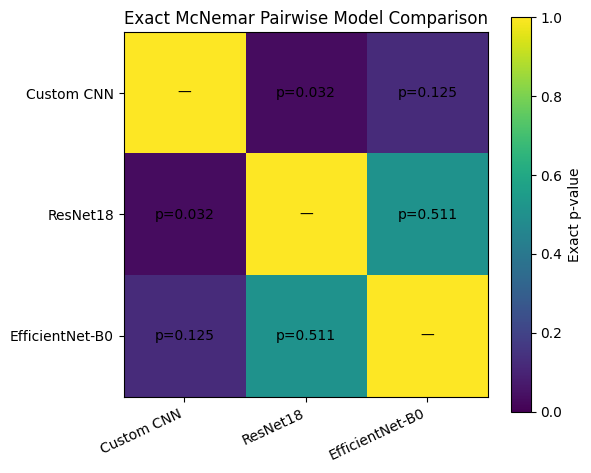


=== CELL 25 SUMMARY ===
Custom CNN vs ResNet18: p=0.0319 | Significant
Custom CNN vs EfficientNet-B0: p=0.1249 | Not significant
ResNet18 vs EfficientNet-B0: p=0.5114 | Not significant

TEST CORRECT PREDICTIONS
Custom CNN      : 260/334 (0.7784)
ResNet18        : 279/334 (0.8353)
EfficientNet-B0 : 274/334 (0.8204)

Table saved       : /content/elpv-dataset/outputs/tables/three_model_mcnemar_tests.csv
Figure saved      : /content/elpv-dataset/outputs/figures/three_model_mcnemar_comparison.png


In [32]:
# CELL 25: Exact McNemar pairwise comparison of model predictions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binomtest

# -------------------------------------------------------
# 1. Recreate Custom CNN predictions
# -------------------------------------------------------

model.load_state_dict(
    torch.load(BEST_MODEL, map_location=device)
)
model.eval()

custom_true, custom_prob = [], []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        custom_true.extend(
            yb.numpy().astype(int)
        )

        custom_prob.extend(
            probs.cpu().numpy()
        )

custom_true = np.array(
    custom_true
)

custom_prob = np.array(
    custom_prob
)

custom_pred = (
    custom_prob >= CUSTOM_THRESHOLD
).astype(int)


# -------------------------------------------------------
# 2. Load saved transfer-model predictions
# -------------------------------------------------------

res_df = pd.read_csv(
    TAB_DIR / "resnet18_test_predictions.csv"
)

eff_df = pd.read_csv(
    TAB_DIR / "efficientnet_test_predictions.csv"
)

y_true = test_df[
    "label"
].values.astype(int)

res_pred = res_df[
    "Predicted_Label"
].values.astype(int)

eff_pred = eff_df[
    "Predicted_Label"
].values.astype(int)


# -------------------------------------------------------
# 3. Correct / incorrect indicators
# -------------------------------------------------------

correctness = {
    "Custom CNN":
        custom_pred == y_true,

    "ResNet18":
        res_pred == y_true,

    "EfficientNet-B0":
        eff_pred == y_true
}


# -------------------------------------------------------
# 4. Exact McNemar function
# -------------------------------------------------------

def exact_mcnemar(correct_a, correct_b):

    # A correct, B wrong
    b = np.sum(
        correct_a & ~correct_b
    )

    # A wrong, B correct
    c = np.sum(
        ~correct_a & correct_b
    )

    discordant = b + c

    if discordant == 0:
        p = 1.0

    else:
        p = binomtest(
            min(b, c),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    return int(b), int(c), int(discordant), float(p)


# -------------------------------------------------------
# 5. Pairwise comparisons
# -------------------------------------------------------

pairs = [
    ("Custom CNN", "ResNet18"),
    ("Custom CNN", "EfficientNet-B0"),
    ("ResNet18", "EfficientNet-B0")
]

rows = []

for a, b in pairs:

    a_only, b_only, discordant, p = exact_mcnemar(
        correctness[a],
        correctness[b]
    )

    rows.append({
        "Model_A": a,
        "Model_B": b,

        "A_Correct_B_Wrong":
            a_only,

        "A_Wrong_B_Correct":
            b_only,

        "Discordant_Pairs":
            discordant,

        "Exact_P_Value":
            p,

        "Significant_0.05":
            p < 0.05
    })


mcnemar_df = pd.DataFrame(
    rows
)

mcnemar_df.to_csv(
    TAB_DIR /
    "three_model_mcnemar_tests.csv",
    index=False
)

display(
    mcnemar_df.round(4)
)


# -------------------------------------------------------
# 6. Create p-value matrix
# -------------------------------------------------------

model_names = [
    "Custom CNN",
    "ResNet18",
    "EfficientNet-B0"
]

p_matrix = np.ones(
    (3,3)
)

for _, r in mcnemar_df.iterrows():

    i = model_names.index(
        r.Model_A
    )

    j = model_names.index(
        r.Model_B
    )

    p_matrix[i,j] = (
        r.Exact_P_Value
    )

    p_matrix[j,i] = (
        r.Exact_P_Value
    )


# -------------------------------------------------------
# 7. Figure
# -------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6,5)
)

im = ax.imshow(
    p_matrix,
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(3)
)

ax.set_yticks(
    range(3)
)

ax.set_xticklabels(
    model_names,
    rotation=25,
    ha="right"
)

ax.set_yticklabels(
    model_names
)

for i in range(3):
    for j in range(3):

        if i == j:
            text = "—"
        else:
            text = f"p={p_matrix[i,j]:.3f}"

        ax.text(
            j, i,
            text,
            ha="center",
            va="center"
        )

ax.set_title(
    "Exact McNemar Pairwise Model Comparison"
)

plt.colorbar(
    im,
    ax=ax,
    label="Exact p-value"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "three_model_mcnemar_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------------------------------------
# 8. Accuracy reminder
# -------------------------------------------------------

accuracy_table = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet18",
        "EfficientNet-B0"
    ],

    "Correct": [
        correctness[
            "Custom CNN"
        ].sum(),

        correctness[
            "ResNet18"
        ].sum(),

        correctness[
            "EfficientNet-B0"
        ].sum()
    ]
})

accuracy_table["Accuracy"] = (
    accuracy_table["Correct"] /
    len(y_true)
)

# CELL 25B: Fix and print McNemar summary

print("\n=== CELL 25 SUMMARY ===")

for _, r in mcnemar_df.iterrows():

    result = (
        "Significant"
        if r["Significant_0.05"]
        else "Not significant"
    )

    print(
        f"{r['Model_A']} vs {r['Model_B']}: "
        f"p={r['Exact_P_Value']:.4f} | "
        f"{result}"
    )

print("\nTEST CORRECT PREDICTIONS")

for _, r in accuracy_table.iterrows():

    print(
        f"{r['Model']:<16}: "
        f"{int(r['Correct'])}/{len(y_true)} "
        f"({r['Accuracy']:.4f})"
    )

print(
    f"\nTable saved       : "
    f"{TAB_DIR/'three_model_mcnemar_tests.csv'}"
)

print(
    f"Figure saved      : "
    f"{FIG_DIR/'three_model_mcnemar_comparison.png'}"
)



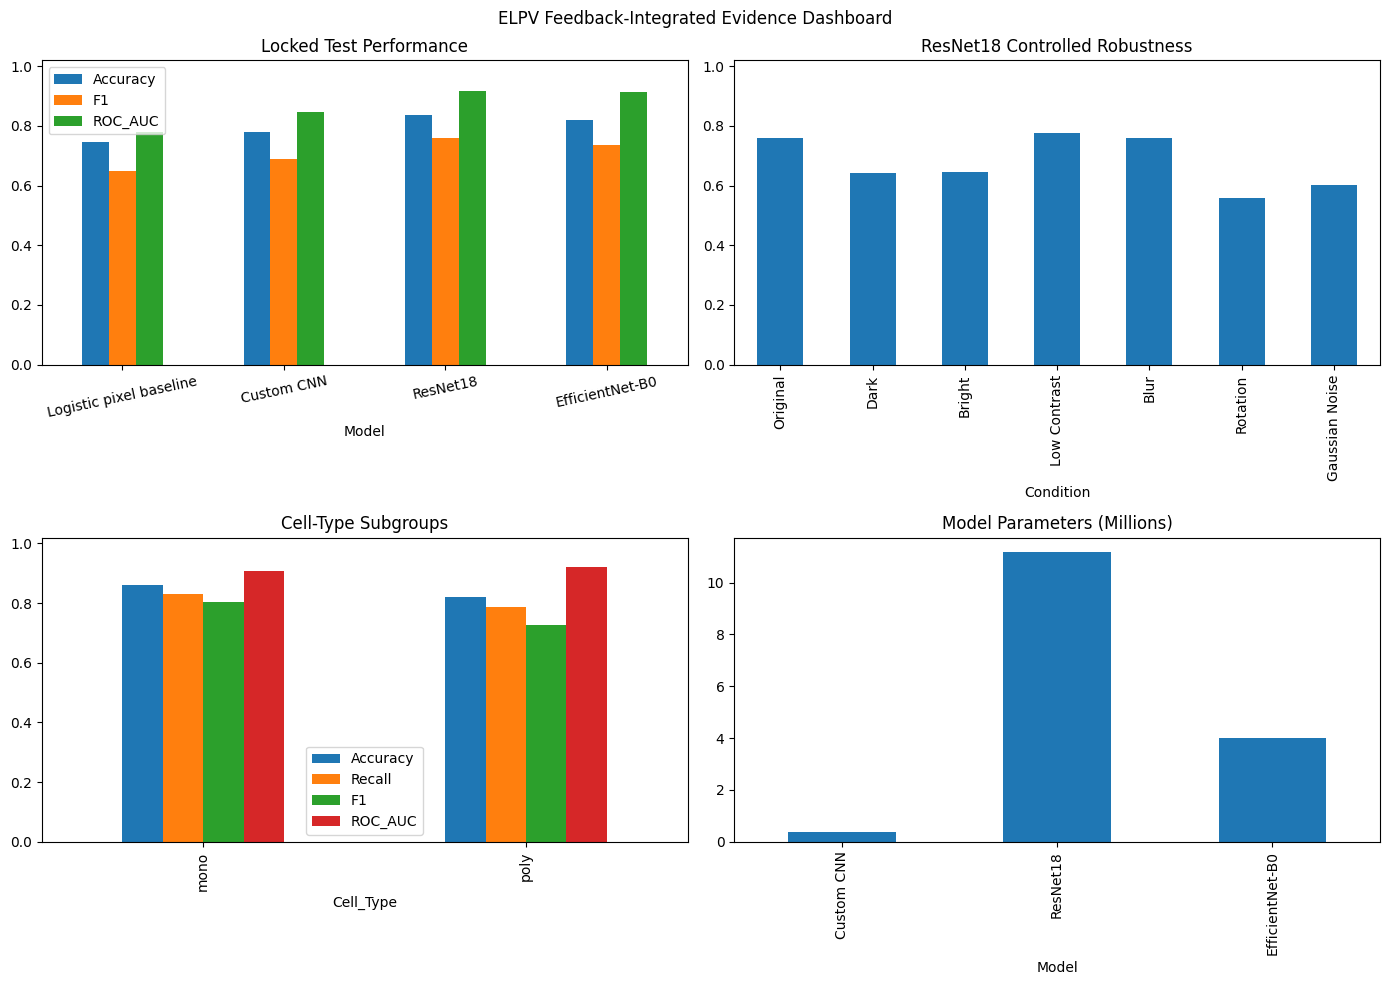

In [33]:
# Dynamic consolidated evidence dashboard
ci_df=pd.read_csv(TAB_DIR/"resnet18_bootstrap_confidence_intervals.csv")
robust_df=pd.read_csv(TAB_DIR/"resnet18_robustness_results.csv")
celltype_df=pd.read_csv(TAB_DIR/"resnet18_celltype_performance.csv")
efficiency_df=pd.read_csv(TAB_DIR/"three_model_efficiency.csv")
fig,axes=plt.subplots(2,2,figsize=(14,10))
all_model_comparison_df.set_index("Model")[["Accuracy","F1","ROC_AUC"]].plot(kind="bar",ax=axes[0,0])
axes[0,0].set_ylim(0,1.02); axes[0,0].set_title("Locked Test Performance"); axes[0,0].tick_params(axis="x",rotation=12)
robust_df.plot(x="Condition",y="F1",kind="bar",legend=False,ax=axes[0,1]); axes[0,1].set_ylim(0,1.02); axes[0,1].set_title("ResNet18 Controlled Robustness")
celltype_df.set_index("Cell_Type")[["Accuracy","Recall","F1","ROC_AUC"]].plot(kind="bar",ax=axes[1,0]); axes[1,0].set_ylim(0,1.02); axes[1,0].set_title("Cell-Type Subgroups")
efficiency_df.plot(x="Model",y="Parameters_Million",kind="bar",legend=False,ax=axes[1,1]); axes[1,1].set_title("Model Parameters (Millions)")
plt.suptitle("ELPV Feedback-Integrated Evidence Dashboard"); plt.tight_layout(); plt.savefig(FIG_DIR/"final_feedback_integrated_dashboard.png",dpi=300,bbox_inches="tight"); plt.show()


In [34]:
# Dynamic master results table for reporting
master_rows=[]
for _,row in all_model_comparison_df.iterrows():
    for metric in ["Accuracy","Precision","Recall","Specificity","F1","Balanced_Accuracy","ROC_AUC","Average_Precision","Locked_Threshold","Parameters"]:
        master_rows.append(["Locked test model comparison",row.Model,metric,row[metric],"Threshold selected on validation"])
for _,row in ci_df.iterrows():
    master_rows.extend([["Statistical uncertainty","ResNet18",f"{row.Metric} point",row.Point_Estimate,"Stratified bootstrap"],
                        ["Statistical uncertainty","ResNet18",f"{row.Metric} 95% lower",row.CI_95_Lower,"Stratified bootstrap"],
                        ["Statistical uncertainty","ResNet18",f"{row.Metric} 95% upper",row.CI_95_Upper,"Stratified bootstrap"]])
for _,row in robust_df.iterrows():
    master_rows.append(["Controlled robustness",row.Condition,"F1",row.F1,"Not external validation"])
for _,row in celltype_df.iterrows():
    master_rows.append(["Cell-type subgroup",row.Cell_Type,"F1",row.F1,"Descriptive subgroup evidence"])
similarity_df=pd.read_csv(TAB_DIR/"high_similarity_sensitivity_analysis.csv")
for _,row in similarity_df.iterrows(): master_rows.append(["Similarity sensitivity",row.Evaluation,"F1",row.F1,"Non-identical highly similar images"])
mcnemar_df=pd.read_csv(TAB_DIR/"three_model_mcnemar_tests.csv")
for _,row in mcnemar_df.iterrows(): master_rows.append(["Paired comparison",f"{row.Model_A} vs {row.Model_B}","Exact McNemar p",row.Exact_P_Value,"Two-sided exact test"])
MASTER_RESULTS=pd.DataFrame(master_rows,columns=["Section","Item","Metric","Value","Notes"])
MASTER_RESULTS.to_csv(TAB_DIR/"MASTER_RESULTS.csv",index=False)
display(MASTER_RESULTS)


,Section,Item,Metric,Value,Notes
0,Locked test model comparison,Logistic pixel baseline,Accuracy,0.745509,Threshold selected on validation
1,Locked test model comparison,Logistic pixel baseline,Precision,0.586466,Threshold selected on validation
2,Locked test model comparison,Logistic pixel baseline,Recall,0.722222,Threshold selected on validation
3,Locked test model comparison,Logistic pixel baseline,Specificity,0.756637,Threshold selected on validation
4,Locked test model comparison,Logistic pixel baseline,F1,0.647303,Threshold selected on validation
...,...,...,...,...,...
67,Similarity sensitivity,Original Test Set,F1,0.759825,Non-identical highly similar images
68,Similarity sensitivity,After Excluding High-Similarity Test Images,F1,0.759825,Non-identical highly similar images
69,Paired comparison,Custom CNN vs ResNet18,Exact McNemar p,0.031927,Two-sided exact test
70,Paired comparison,Custom CNN vs EfficientNet-B0,Exact McNemar p,0.124918,Two-sided exact test


In [35]:
# Workflow, governance, risks, and Draw.io–Jira consistency evidence
DOC_DIR=OUT/"documentation"; DOC_DIR.mkdir(parents=True,exist_ok=True)

workflow_df=pd.DataFrame([
    ["W1","Acquire pinned ELPV data","Licence/source approved","Counts, hashes, 5Vs","Data audit passes"],
    ["W2","Filter labels and split","W1","Split CSVs and overlap audit","No filepath overlap; seed recorded"],
    ["W3","Baseline/custom/transfer training","W2","Histories and checkpoints","Validation criteria satisfied"],
    ["W4","Locked evaluation and statistics","W3","Metrics, predictions, CIs, McNemar","No test-set tuning"],
    ["W5","XAI/robustness/subgroups","W4","Grad-CAM and analysis tables","Limitations reviewed"],
    ["W6","Interface, report and package","W4,W5","Prototype, manifest and ZIP","Owner/reviewer sign-off"],
],columns=["Workflow_ID","Activity","Dependency","Evidence","Definition_of_Done"])
for column in ["Actual_Owner","Actual_Reviewer","Sprint_Start","Due_Date","Jira_Issue_URL","GitHub_PR_or_Commit","Status"]:
    workflow_df[column]="TEAM MUST COMPLETE"
workflow_df.to_csv(TAB_DIR/"workflow_governance_template_REQUIRES_REAL_DATA.csv",index=False)

jira_consistency_df=pd.DataFrame([
    ["Data ingestion/audit","W1","TEAM MUST ADD","Not evidenced until linked"],
    ["Preprocessing/split","W2","TEAM MUST ADD","Not evidenced until linked"],
    ["Model training","W3","TEAM MUST ADD","Not evidenced until linked"],
    ["Evaluation","W4","TEAM MUST ADD","Not evidenced until linked"],
    ["Explainability/robustness","W5","TEAM MUST ADD","Not evidenced until linked"],
    ["Interface/report/release","W6","TEAM MUST ADD","Not evidenced until linked"],
],columns=["Drawio_Node","Notebook_Workflow_ID","Jira_Epic_or_Issue_URL","Consistency_Status"])
jira_consistency_df.to_csv(TAB_DIR/"drawio_jira_consistency_REQUIRES_REAL_LINKS.csv",index=False)

risk_df=pd.DataFrame([
    ["Ambiguous labels","High","Medium","Exclude intermediate labels; preserve counts; consider ordinal study","Data owner"],
    ["Cross-split similarity","High","Medium","MD5/pHash/correlation audit and exclusion sensitivity","Data reviewer"],
    ["Module-level dependence","High","Unknown","Acquire module IDs and repeat group-aware evaluation","Evaluation owner"],
    ["Minority-class misses","High","Medium","Weighting, PR metrics, threshold locking and FN review","Model reviewer"],
    ["Domain shift","High","High","No deployment claim; acquire independent modules/sites/devices","Project lead"],
    ["Overconfidence","High","Medium","Calibration, both probabilities, uncertainty flag and human escalation","Safety reviewer"],
    ["Compute/reproducibility","Medium","Medium","Pinned source, fixed seed, environment and saved checkpoints","Repository owner"],
    ["Repository inactivity","Medium","Medium","Weekly Jira review, stale-ticket escalation and backup owner","Team lead"],
    ["Uneven participation","High","Medium","Named issues, commits, PRs and reviews checked each sprint","Team lead"],
],columns=["Risk","Impact","Likelihood","Mitigation","Accountable_Role"])
risk_df.to_csv(TAB_DIR/"risk_register.csv",index=False)

feedback_df=pd.DataFrame([
    ["Architecture/tool selection","Strengthened","Architecture and alternatives section"],
    ["Workflow detail","Template supplied","workflow_governance_template_REQUIRES_REAL_DATA.csv"],
    ["Governance/risk","Strengthened","Review gates and risk_register.csv"],
    ["Collaboration evidence","External action required","Actual names, Jira, commits and reviews cannot be fabricated"],
    ["Documentation/referencing","Strengthened","Pinned provenance, citation and generated manifest"],
    ["Draw.io–Jira consistency","Template supplied","drawio_jira_consistency_REQUIRES_REAL_LINKS.csv"],
    ["Traditional baseline","Implemented","Logistic pixel baseline"],
],columns=["Feedback_Item","Status","Evidence_or_Action"])
feedback_df.to_csv(TAB_DIR/"feedback_compliance_matrix.csv",index=False)

(DOC_DIR/"GOVERNANCE_ACTIONS_REQUIRED.txt").write_text("Insert every student's real name/ID and accessible Jira URL. Replace every TEAM MUST COMPLETE/ADD field. Link Draw.io nodes to Jira epics/issues and GitHub branches, commits, PRs and reviews. Record sprint dates, dependencies, tests, definitions of done, approvals, blockers and scope changes. These records must not be fabricated.\n",encoding="utf-8")
(DOC_DIR/"DATA_PROVENANCE_AND_LICENSE.txt").write_text(f"Source: {ELPV_REPOSITORY}\nPinned commit: {ELPV_COMMIT}\nImages: CC BY-NC-SA 4.0; code: Apache-2.0, as stated by the official repository.\nCite: Buerhop-Lutz et al. (2018), DOI 10.4229/35thEUPVSEC20182018-5CV.3.15; Deitsch et al. (2019), DOI 10.1016/j.solener.2019.02.067.\n",encoding="utf-8")
display(workflow_df); display(jira_consistency_df); display(risk_df); display(feedback_df)


,Workflow_ID,Activity,Dependency,Evidence,Definition_of_Done,Actual_Owner,Actual_Reviewer,Sprint_Start,Due_Date,Jira_Issue_URL,GitHub_PR_or_Commit,Status
0,W1,Acquire pinned ELPV data,Licence/source approved,"Counts, hashes, 5Vs",Data audit passes,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE
1,W2,Filter labels and split,W1,Split CSVs and overlap audit,No filepath overlap; seed recorded,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE
2,W3,Baseline/custom/transfer training,W2,Histories and checkpoints,Validation criteria satisfied,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE
3,W4,Locked evaluation and statistics,W3,"Metrics, predictions, CIs, McNemar",No test-set tuning,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE
4,W5,XAI/robustness/subgroups,W4,Grad-CAM and analysis tables,Limitations reviewed,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE
5,W6,"Interface, report and package","W4,W5","Prototype, manifest and ZIP",Owner/reviewer sign-off,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE,TEAM MUST COMPLETE


,Drawio_Node,Notebook_Workflow_ID,Jira_Epic_or_Issue_URL,Consistency_Status
0,Data ingestion/audit,W1,TEAM MUST ADD,Not evidenced until linked
1,Preprocessing/split,W2,TEAM MUST ADD,Not evidenced until linked
2,Model training,W3,TEAM MUST ADD,Not evidenced until linked
3,Evaluation,W4,TEAM MUST ADD,Not evidenced until linked
4,Explainability/robustness,W5,TEAM MUST ADD,Not evidenced until linked
5,Interface/report/release,W6,TEAM MUST ADD,Not evidenced until linked


,Risk,Impact,Likelihood,Mitigation,Accountable_Role
0,Ambiguous labels,High,Medium,Exclude intermediate labels; preserve counts; ...,Data owner
1,Cross-split similarity,High,Medium,MD5/pHash/correlation audit and exclusion sens...,Data reviewer
2,Module-level dependence,High,Unknown,Acquire module IDs and repeat group-aware eval...,Evaluation owner
3,Minority-class misses,High,Medium,"Weighting, PR metrics, threshold locking and F...",Model reviewer
4,Domain shift,High,High,No deployment claim; acquire independent modul...,Project lead
5,Overconfidence,High,Medium,"Calibration, both probabilities, uncertainty f...",Safety reviewer
6,Compute/reproducibility,Medium,Medium,"Pinned source, fixed seed, environment and sav...",Repository owner
7,Repository inactivity,Medium,Medium,"Weekly Jira review, stale-ticket escalation an...",Team lead
8,Uneven participation,High,Medium,"Named issues, commits, PRs and reviews checked...",Team lead


,Feedback_Item,Status,Evidence_or_Action
0,Architecture/tool selection,Strengthened,Architecture and alternatives section
1,Workflow detail,Template supplied,workflow_governance_template_REQUIRES_REAL_DAT...
2,Governance/risk,Strengthened,Review gates and risk_register.csv
3,Collaboration evidence,External action required,"Actual names, Jira, commits and reviews cannot..."
4,Documentation/referencing,Strengthened,"Pinned provenance, citation and generated mani..."
5,Draw.io–Jira consistency,Template supplied,drawio_jira_consistency_REQUIRES_REAL_LINKS.csv
6,Traditional baseline,Implemented,Logistic pixel baseline


In [36]:
# Responsible prediction-interface prototype (optional launch)
def predict_responsibly(image):
    if image is None: return {"Functional":0.0,"Defective":0.0},"Provide an electroluminescence cell image."
    x=resnet_eval_tfms(image.convert("L")).unsqueeze(0).to(device); resnet_model.eval()
    with torch.no_grad(): probability=float(torch.sigmoid(resnet_model(x)).item())
    probabilities={"Functional":1-probability,"Defective":probability}; confidence=max(probabilities.values())
    flag="LOW CONFIDENCE — human review required. " if confidence<.75 else ""
    return probabilities,flag+"Proof of concept only; not a defect diagnosis, safety certification, or repair recommendation."

LAUNCH_DEMO=False
if LAUNCH_DEMO:
    try: import gradio as gr
    except ImportError:
        import subprocess,sys; subprocess.run([sys.executable,"-m","pip","install","-q","gradio"],check=True); import gradio as gr
    gr.Interface(predict_responsibly,gr.Image(type="pil"),[gr.Label(),gr.Textbox()],title="ELPV Defect Review Prototype").launch(share=True,prevent_thread_lock=True)
else: print("Set LAUNCH_DEMO=True and rerun this cell to launch the temporary Colab prototype.")


Set LAUNCH_DEMO=True and rerun this cell to launch the temporary Colab prototype.


In [37]:
# Final dynamic evidence summary
primary=all_model_comparison_df.loc[all_model_comparison_df.Model=="ResNet18"].iloc[0]
best_f1=all_model_comparison_df.loc[all_model_comparison_df.F1.idxmax()]
best_auc=all_model_comparison_df.loc[all_model_comparison_df.ROC_AUC.idxmax()]
final_summary=f"""ELPV FINAL FEEDBACK-INTEGRATED SUMMARY
Pinned revision: {ELPV_COMMIT}
Source images: {len(labels_df):,}; definite binary images: {len(binary_df):,}; ambiguous excluded: {len(labels_df)-len(binary_df):,}
Train/validation/test: {len(train_df):,}/{len(val_df):,}/{len(test_df):,}
Positive class: Defective (1); FN = defective predicted functional

FOUR-MODEL LOCKED TEST COMPARISON
{all_model_comparison_df.round(4).to_string(index=False)}

Best observed F1: {best_f1.Model} ({best_f1.F1:.4f})
Best observed ROC-AUC: {best_auc.Model} ({best_auc.ROC_AUC:.4f})

Interpretation: results concern a controlled, definite-label subset. Intermediate annotations were excluded; module-level independence is unavailable; a small number of non-identical highly similar images cross splits; and no independent external dataset was evaluated. Controlled perturbations are not external validation. This is decision-support research, not deployment evidence."""
(DOC_DIR/"FINAL_FEEDBACK_INTEGRATED_SUMMARY.txt").write_text(final_summary,encoding="utf-8")
print(final_summary)


ELPV FINAL FEEDBACK-INTEGRATED SUMMARY
Pinned revision: 93e82ae507c36b3f2c8227eade8b792fcbefcca6
Source images: 2,624; definite binary images: 2,223; ambiguous excluded: 401
Train/validation/test: 1,556/333/334
Positive class: Defective (1); FN = defective predicted functional

FOUR-MODEL LOCKED TEST COMPARISON
                  Model  Accuracy  Precision  Recall  Specificity     F1  Balanced_Accuracy  ROC_AUC  Average_Precision  Locked_Threshold  Parameters
Logistic pixel baseline    0.7455     0.5865  0.7222       0.7566 0.6473             0.7394   0.7800             0.7068            0.3300        1025
             Custom CNN    0.7784     0.6308  0.7593       0.7876 0.6891             0.7734   0.8462             0.7696            0.5274      389057
               ResNet18    0.8353     0.7190  0.8056       0.8496 0.7598             0.8276   0.9182             0.8937            0.2609    11177025
        EfficientNet-B0    0.8204     0.7000  0.7778       0.8407 0.7368             0.

In [38]:
# Final corrected Colab package
import shutil,zipfile,platform,sys
PACKAGE_DIR=OUT/"ELPV_Report_Ready_Final"; ZIP_PATH=OUT/"ELPV_Final_Feedback_Incorporated_Report_Ready.zip"
if PACKAGE_DIR.exists(): shutil.rmtree(PACKAGE_DIR)
for folder in ["figures","tables","models","documentation"]: (PACKAGE_DIR/folder).mkdir(parents=True,exist_ok=True)
for source,destination,patterns in [(FIG_DIR,"figures",["*.png"]),(TAB_DIR,"tables",["*.csv"]),(MODEL_DIR,"models",["*.pt","*.joblib"]),(DOC_DIR,"documentation",["*.txt","*.md"]), (OUT,"documentation",["*.txt","*.md"])]:
    for pattern in patterns:
        for path in source.glob(pattern):
            if path.is_file(): shutil.copy2(path,PACKAGE_DIR/destination/path.name)
expected="ELPV_Final_Feedback_Incorporated_Colab.ipynb"; copied=[]
for folder in {Path.cwd(),Path("/content") if IN_COLAB else Path.cwd(),ROOT}:
    candidate=folder/expected
    if candidate.is_file() and candidate.name not in copied:
        shutil.copy2(candidate,PACKAGE_DIR/"documentation"/candidate.name); copied.append(candidate.name)
if not copied:
    (PACKAGE_DIR/"documentation"/"NOTEBOOK_DOWNLOAD_NOTICE.txt").write_text("Colab did not expose the active notebook as a VM file. Use File > Download > Download .ipynb and submit ELPV_Final_Feedback_Incorporated_Colab.ipynb beside this package.\n",encoding="utf-8")
environment=f"Python: {sys.version}\nPyTorch: {torch.__version__}\nTorchvision: {__import__('torchvision').__version__}\nCUDA: {torch.cuda.is_available()} / {torch.version.cuda}\nPlatform: {platform.platform()}\nDevice: {device}\nELPV commit: {ELPV_COMMIT}\nSeed: {SEED}\n"
(PACKAGE_DIR/"documentation"/"ENVIRONMENT.txt").write_text(environment,encoding="utf-8")
manifest=sorted(str(p.relative_to(PACKAGE_DIR)).replace("\\","/") for p in PACKAGE_DIR.rglob("*") if p.is_file())
(PACKAGE_DIR/"documentation"/"FILE_MANIFEST.txt").write_text("\n".join(manifest),encoding="utf-8")
if ZIP_PATH.exists(): ZIP_PATH.unlink()
with zipfile.ZipFile(ZIP_PATH,"w",zipfile.ZIP_DEFLATED) as archive:
    for path in PACKAGE_DIR.rglob("*"):
        if path.is_file(): archive.write(path,path.relative_to(PACKAGE_DIR))
print("Final ZIP:",ZIP_PATH,"Notebook packaged:",copied or "see notice")
AUTO_DOWNLOAD_PACKAGE=False
if AUTO_DOWNLOAD_PACKAGE and IN_COLAB:
    from google.colab import files
    files.download(str(ZIP_PATH))


Final ZIP: /content/elpv-dataset/outputs/ELPV_Final_Feedback_Incorporated_Report_Ready.zip Notebook packaged: see notice


In [39]:
from google.colab import files

files.download(str(ZIP_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>